In [1]:
import os, sys, importlib, pathlib
import pandas as pd
from pathlib import Path
sys.path.append (os.path.abspath(".."))

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import statsmodels.api as sm
import statsmodels.formula.api as smf
# my utils
from utils import desc_new_old

def p_to_sig(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    elif p < 0.1: return '.'
    else: return ''



# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # ==len(hue) 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))


## data

In [2]:
path_df=r"../data_processed\listings_tactics_bio_vis-paris_london-2306_2312_2406-1.csv"
df_all=pd.read_csv(path_df)
print(df_all.shape)

C:\Users\yeliu\AppData\Local\Temp\ipykernel_34192\28326417.py:2: DtypeWarning: Columns (6,68,115) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all=pd.read_csv(path_df)


(266852, 129)


In [3]:
# time str
df_all['time']=df_all['time'].astype(str)
print(df_all.time.dtype)
print(df_all.time.unique())

## fillna
tactics_bio = [
    "ouverture",
    "authenticité",
    "sociabilité",
    "auto_promotion",
    "exemplarité",
]
tactics_pic=['host_picture_type']# no_person, pro_style, life_style

df_all[tactics_bio]=df_all[tactics_bio].fillna(0)
df_all["host_picture_type"]=df_all["host_picture_type"].fillna("no_person")


# dummies for host_picture_type
df=df_all.copy()
df_all['is_portrait']=df_all["host_picture_type"].apply(lambda x : 1 if x=="pro_style" else 0)
df_all['is_lifestyle']=df_all["host_picture_type"].apply(lambda x : 1 if x=="life_style" else 0)
df_all['no_person']=df_all["host_picture_type"].apply(lambda x : 1 if x=="no_person" else 0)

tactics_pic_dummies=['is_portrait','is_lifestyle','no_person']

print(df_all[tactics_pic_dummies].value_counts(dropna=False))


# time x is_paris
print(df_all[['time','in_paris']].value_counts(dropna=False))
 

object
['2306' '2312' '2406']
is_portrait  is_lifestyle  no_person
1            0             0            94648
0            0             1            91235
             1             0            80969
Name: count, dtype: int64
time  in_paris
2406  1           62738
      0           49856
2312  0           43172
2306  0           42356
2312  1           35829
2306  1           32901
Name: count, dtype: int64


In [4]:
# is_new_host
host_2306 = df_all[df_all['time'] == "2306"]['host_id'].to_list()
host_2312 = df_all[df_all['time'] == "2312"]['host_id'].to_list()


df_all['is_new_host'] = 0  # 先初始化

# 2312 vs 2306
mask_2312 = df_all['time'] == "2312"
df_all.loc[mask_2312, 'is_new_host'] = (
    ~df_all.loc[mask_2312, 'host_id'].isin(host_2306)
).astype(int)

# 2406 vs 2312
mask_2406 = df_all['time'] == "2406"
df_all.loc[mask_2406, 'is_new_host'] = (
    ~df_all.loc[mask_2406, 'host_id'].isin(host_2312)
).astype(int)

display(df_all.groupby(["time",'in_paris'])['is_new_host'].value_counts().reset_index())

,time,in_paris,is_new_host,count
0,2306,0,0,42356
1,2306,1,0,32901
2,2312,0,0,32360
3,2312,0,1,10812
4,2312,1,0,24780
5,2312,1,1,11049
6,2406,0,0,37937
7,2406,0,1,11919
8,2406,1,0,34176
9,2406,1,1,28562


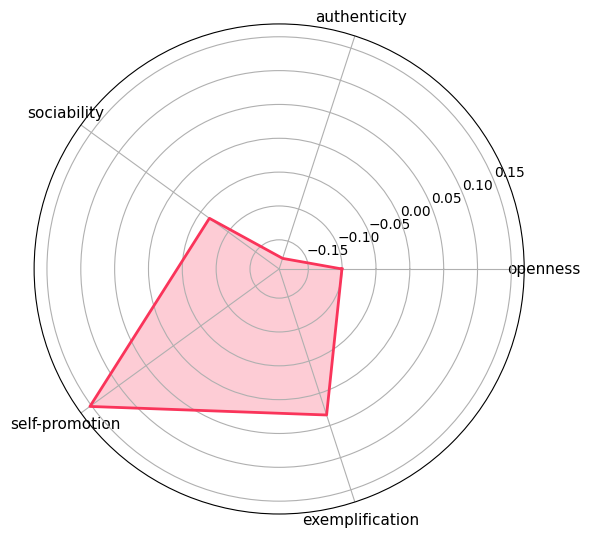

In [157]:
import numpy as np
import matplotlib.pyplot as plt
pink = (250/255, 52/255, 90/255)
# 数据
df = df_all.copy()
data = df[tactics_bio].mean()

# 自定义标签
labels = [
    'openness',
    'authenticity',
    'sociability',
    'self-promotion',
    'exemplification'
]

# 数值
values = data.values.tolist()

# 闭合图形
values += values[:1]

# 角度
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

# 创建雷达图
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

# 绿色轮廓
ax.plot(
    angles,
    values,
    color=pink,
    linewidth=2
)

# 绿色阴影
ax.fill(
    angles,
    values,
    color=pink,
    alpha=0.25
)

# 标签
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)

# 标题（可删）
# ax.set_title("Textual tactics", fontsize=14, pad=20)

plt.tight_layout()
plt.show()

## choc de supply & demande

,in_paris,time,count
0,0,June 2023,42356
1,0,Dec. 2023,43172
2,0,June 2024,49856
3,1,June 2023,32901
4,1,Dec. 2023,35829
5,1,June 2024,62738


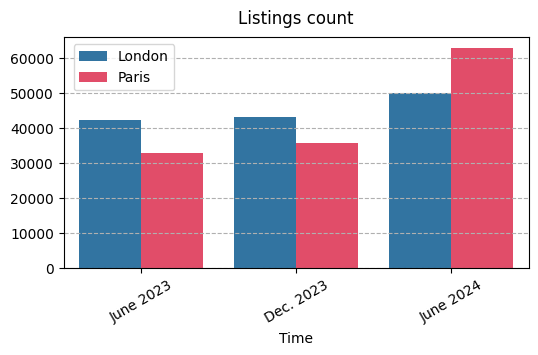

In [156]:
fig, ax=plt.subplots(figsize=(6,3))
# ---supply---
palette={
    0: 'tab:blue',
    1: (250/255, 52/255, 90/255)
}
# rgb(39/255, 109/255, 180/255)


df=df_all.copy()
agg=df.groupby(['in_paris','time'])["id"].count().reset_index(name='count')
agg['time']=agg['time'].map({'2306':"June 2023",
                             '2312':"Dec. 2023",
                             '2406':"June 2024"})
display(agg)

sns.barplot(
    data=agg,
    x='time',
    y='count',
    hue='in_paris',
    ax=ax,
    palette=palette    
    # legend=False
)
ax.grid(axis='y', linestyle='--')
ax.set_title("Listings count",pad=10)
ax.set_xlabel('Time')
ax.set_ylabel('')
ax.tick_params(axis="x", rotation=30)
handles, labels=ax.get_legend_handles_labels()
fig.legend(
    handles,
    ['London','Paris'],
    loc="upper left",
    bbox_to_anchor=(0.13, 0.88) # legend (x, y)，x>1则在图外, y=0在底线
)

if ax.legend():
    ax.get_legend().remove()

C:\Users\yeliu\AppData\Local\Temp\ipykernel_7008\3902694559.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1,1])


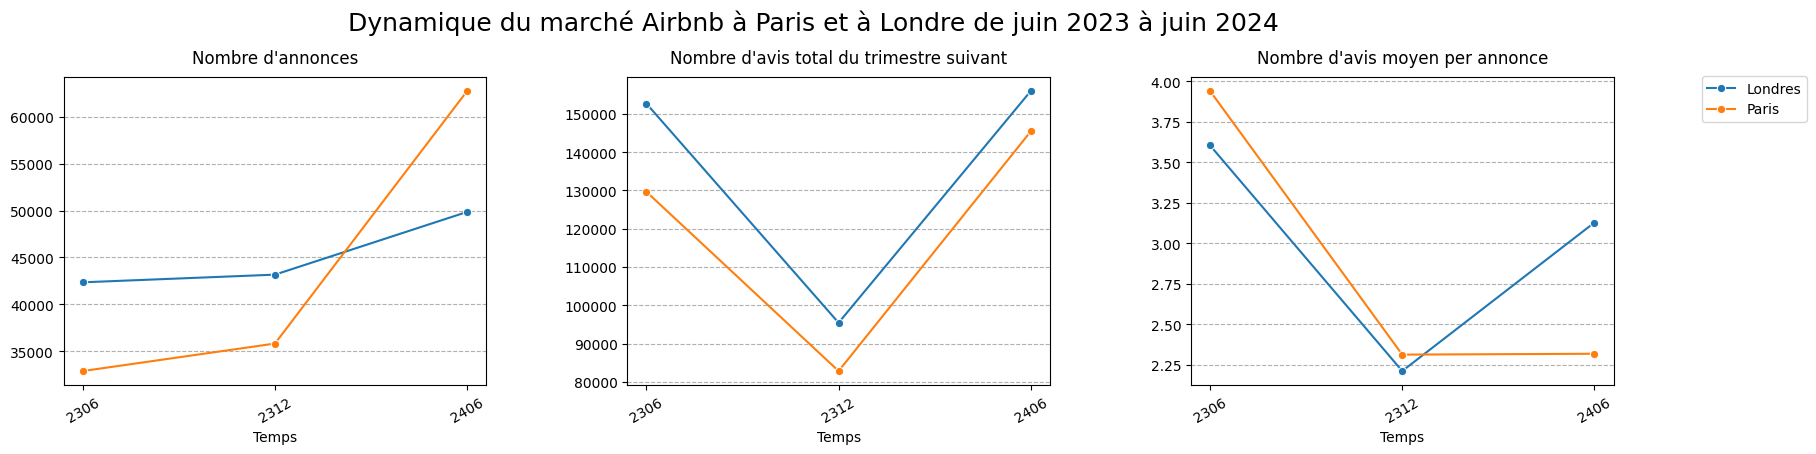

In [5]:

# ---layout---
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,4))# sharey=True
gs = gridspec.GridSpec(1, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])


df=df_all.copy()


# ---supply---
agg=df.groupby(['in_paris','time'])["id"].count().reset_index(name='count')
# display(agg)
sns.lineplot(
    data=agg,
    x='time',
    y='count',
    hue='in_paris',
    marker='o',
    ax=axes[0],
    # legend=False
)
axes[0].grid(axis='y', linestyle='--')
axes[0].set_title("Nombre d'annonces",pad=10)
axes[0].set_xlabel('Temps')
axes[0].set_ylabel('')
axes[0].tick_params(axis="x", rotation=30)

if axes[0].legend():
    axes[0].get_legend().remove()


# ---demande réelle---
agg=df.groupby(['in_paris','time'])["number_of_reviews_nextQ"].sum().reset_index(name='sum')
sns.lineplot(
    data=agg,
    x='time',
    y='sum',
    hue='in_paris',
    marker="o",
    ax=axes[1],
    # legend=False
)


axes[1].grid(axis='y', linestyle='--')
axes[1].set_title("Nombre d'avis total du trimestre suivant",pad=10)
axes[1].set_xlabel('Temps')
axes[1].set_ylabel('')
axes[1].tick_params(axis="x", rotation=30)
if axes[1].legend():
    axes[1].get_legend().remove()

# ---competition---
agg=df.groupby(['in_paris','time'])["number_of_reviews_nextQ"].mean().reset_index(name='mean')
sns.lineplot(
    data=agg,
    x='time',
    y='mean',
    hue='in_paris',
    marker="o",
    ax=axes[2],
    # legend=False
)
axes[2].grid(axis='y', linestyle='--')
axes[2].set_title("Nombre d'avis moyen per annonce",pad=10)
axes[2].set_xlabel('Temps')
axes[2].set_ylabel('')
axes[2].tick_params(axis="x", rotation=30)

if axes[2].legend():
    axes[2].get_legend().remove()


# ---layout 3facets---
fig.suptitle(
        "Dynamique du marché Airbnb à Paris et à Londre de juin 2023 à juin 2024",
        fontsize=18,
        y=1.05
    )

handles, labels = axes[0].get_legend_handles_labels()
labels=['Londres','Paris']
fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(1,0.9) # legend (x, y)，x>1则在图外, y=0在底线
)
plt.tight_layout(rect=[0, 0.1, 1,1])
# plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()

## choc de demande

In [112]:
df_all.columns.to_list()

['id',
 'listing_url',
 'scrape_id',
 'last_scraped',
 'source',
 'name',
 'description',
 'neighborhood_overview',
 'picture_url',
 'host_id',
 'host_url',
 'host_name',
 'host_since',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'calendar_updated',
 'has_availability',
 'availability_30

,in_paris,time,sum
0,0,2306,152637.0
1,0,2312,95443.0
2,0,2406,155922.0
3,1,2306,129622.0
4,1,2312,82843.0
5,1,2406,145386.0


<Axes: xlabel='time', ylabel='sum'>

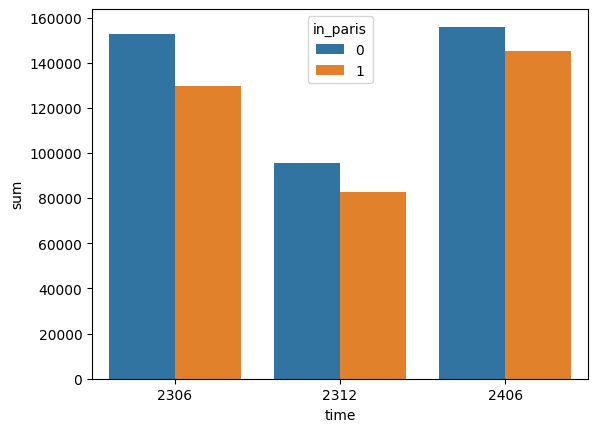

In [125]:
vars=['number_of_reviews_till_Q',"number_of_reviews_till_nextQ","number_of_reviews_nextQ"]
df=df_all.copy()
agg=df.groupby(['in_paris','time'])["number_of_reviews_nextQ"].sum().reset_index(name='sum')
display(agg)
# agg.rename(columns={'number_of_reviews_nextQ'})
# df[vars].head()
sns.barplot(
    data=agg,
    x='time',
    y='sum',
    hue='in_paris'
)

,in_paris,time,mean
0,0,2306,3.603669
1,0,2312,2.210762
2,0,2406,3.127447
3,1,2306,3.939759
4,1,2312,2.312177
5,1,2406,2.317352


<Axes: xlabel='time', ylabel='mean'>

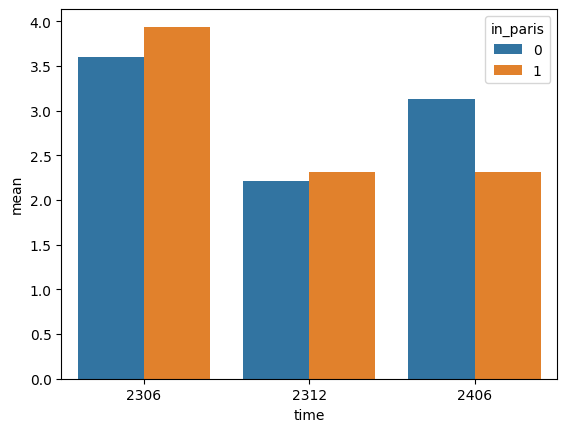

In [156]:
vars=['number_of_reviews_till_Q',"number_of_reviews_till_nextQ","number_of_reviews_nextQ"]
df=df_all.copy()
agg=df.groupby(['in_paris','time'])["number_of_reviews_nextQ"].mean().reset_index(name='mean')
display(agg)

sns.barplot(
    data=agg,
    x='time',
    y='mean',
    hue='in_paris'
)

## new_old stats

In [7]:
import pandas as pd
import plotly.graph_objects as go


In [17]:
df["present"] = 1

import pandas as pd

def classify_transition(df, t1, t2):
    d1 = df[df["time"] == t1][["host_id"]].assign(p1=1)
    d2 = df[df["time"] == t2][["host_id"]].assign(p2=1)

    merged = pd.merge(d1, d2, on="host_id", how="outer")

    merged["p1"] = merged["p1"].fillna(0)
    merged["p2"] = merged["p2"].fillna(0)

    def label(row):
        if row.p1 == 1 and row.p2 == 1:
            return "Stay"
        elif row.p1 == 0 and row.p2 == 1:
            return "New"
        elif row.p1 == 1 and row.p2 == 0:
            return "Lost"
        else:
            return "Inactive"

    merged["transition"] = merged.apply(label, axis=1)

    return merged
# df=df_all.copy()
# trans_2312 = classify_transition(df, "2306", "2312")
# trans_2406 = classify_transition(df, "2312", "2406")

# print(trans_2312["transition"].value_counts())
# print(trans_2406["transition"].value_counts())

In [20]:
df_paris = df[df["in_paris"] == 1]
df_london = df[df["in_paris"] == 0]

trans_paris_2312 = classify_transition(df_paris, "2306", "2312")
trans_paris_2406 = classify_transition(df_paris, "2312", "2406")

trans_london_2312 = classify_transition(df_london, "2306", "2312")
trans_london_2406 = classify_transition(df_london, "2312", "2406")

In [24]:
trans_paris_2312

,host_id,p1,p2,transition
0,275.0,0.0,1.0,New
1,2626.0,1.0,1.0,Stay
2,2626.0,1.0,1.0,Stay
3,2626.0,1.0,1.0,Stay
4,2626.0,1.0,1.0,Stay
...,...,...,...,...
462809,550184281.0,0.0,1.0,New
462810,550193168.0,0.0,1.0,New
462811,550245039.0,0.0,1.0,New
462812,550380224.0,0.0,1.0,New


In [26]:
import pandas as pd
import plotly.graph_objects as go



def build_flow(df):
    t1 = classify_transition(df, "2306", "2312")
    t2 = classify_transition(df, "2312", "2406")

    def to_flow(df_trans, t_from, t_to):
        flow = df_trans.groupby(["p1","p2"]).size().reset_index(name="value")
        flow["source"] = flow["p1"].map({1: f"Present_{t_from}", 0: f"Absent_{t_from}"})
        flow["target"] = flow["p2"].map({1: f"Present_{t_to}", 0: f"Absent_{t_to}"})
        return flow

    f1 = to_flow(t1, "2306", "2312")
    f2 = to_flow(t2, "2312", "2406")

    return pd.concat([f1, f2])


def plot_sankey(flow_df, title="Flow"):

    labels = list(set(flow_df["source"]).union(set(flow_df["target"])))
    label_dict = {k:i for i,k in enumerate(labels)}

    source = flow_df["source"].map(label_dict)
    target = flow_df["target"].map(label_dict)
    value = flow_df["value"]

    fig = go.Figure(data=[go.Sankey(
        node=dict(
            label=labels,
            pad=20,
            thickness=25
        ),
        link=dict(
            source=source,
            target=target,
            value=value
        )
    )])

    fig.update_layout(title_text=title, font_size=12)
    # fig.show()
    fig.show(renderer="browser")

In [27]:
flow_paris = build_flow(df_paris)
plot_sankey(flow_paris, "Paris")

In [28]:
flow_london = build_flow(df_london)
plot_sankey(flow_london, "London")

In [30]:
agg = (
    df_all
    .groupby(["time", "in_paris", "is_new_host"])
    .size()
    .reset_index(name="count")
)
display(agg)


pivot = agg.pivot_table(
    index=["time", "in_paris"],
    columns="is_new_host",
    values="count",
    fill_value=0
).reset_index()

pivot.columns = ["time", "in_paris", "ancien", "nouveau"]
pivot["total"] = pivot["ancien"] + pivot["nouveau"]
pivot["share_new"] = pivot["nouveau"] / pivot["total"]
display(pivot)


,time,in_paris,is_new_host,count
0,2306,0,0,42356
1,2306,1,0,32901
2,2312,0,0,32360
3,2312,0,1,10812
4,2312,1,0,24780
5,2312,1,1,11049
6,2406,0,0,37937
7,2406,0,1,11919
8,2406,1,0,34176
9,2406,1,1,28562


,time,in_paris,ancien,nouveau,total,share_new
0,2306,0,42356.0,0.0,42356.0,0.000000
1,2306,1,32901.0,0.0,32901.0,0.000000
2,2312,0,32360.0,10812.0,43172.0,0.250440
3,2312,1,24780.0,11049.0,35829.0,0.308381
4,2406,0,37937.0,11919.0,49856.0,0.239069
5,2406,1,34176.0,28562.0,62738.0,0.455258


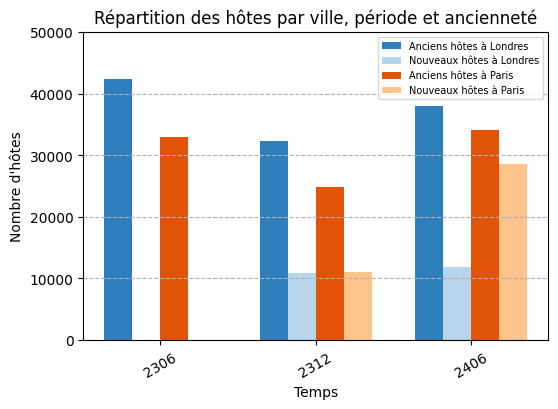

In [111]:
times = sorted(pivot["time"].unique())
x = np.arange(len(times))

width = 0.18  # 因为现在有4个柱子

# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # ==len(hue) 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.7, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.7, n))


fig, ax = plt.subplots(figsize=(6,4))

for i, t in enumerate(times):
    data = pivot[pivot["time"] == t]

    lond = data[data["in_paris"] == 0]
    paris = data[data["in_paris"] == 1]

    # Londres
    ax.bar(x[i] - 1.5*width, lond["ancien"], width,
           color=london_colors[1],
           label="Anciens hôtes à Londres" if i == 0 else "")

    ax.bar(x[i] - 0.5*width, lond["nouveau"], width,
           color=london_colors[0],
           label="Nouveaux hôtes à Londres" if i == 0 else "")

    # Paris
    ax.bar(x[i] + 0.5*width, paris["ancien"], width,
           color=paris_colors[1],
           label="Anciens hôtes à Paris" if i == 0 else "")

    ax.bar(x[i] + 1.5*width, paris["nouveau"], width,
           color=paris_colors[0],
           label="Nouveaux hôtes à Paris" if i == 0 else "")
ax.set_xticks(x)
ax.set_xticklabels(times)
ax.tick_params(axis="x", rotation=30)
ax.set_ylim(0, 50000)
ax.set_xlabel("Temps")
ax.set_ylabel("Nombre d'hôtes")
ax.set_title("Répartition des hôtes par ville, période et ancienneté")
ax.legend(fontsize=7)
ax.grid(axis='y', linestyle='--')

In [5]:
df=df_all.copy()
vars=['years_since_host', "price","review_scores_rating",'has_text',"lang_en","lang_fr",'text_length']
agg=df.groupby(['in_paris','time',"is_new_host"])[vars].mean().reset_index()
agg


,in_paris,time,is_new_host,years_since_host,price,review_scores_rating,has_text,lang_en,lang_fr,text_length
0,0,2306,0,7.062329,226.773609,4.695801,0.555246,0.543961,0.002007,35.593163
1,0,2312,0,7.131829,215.861897,4.716043,0.582849,0.571848,0.001298,39.179048
2,0,2312,1,5.800684,164.411950,4.792810,0.391694,0.381521,0.003145,16.793193
3,0,2406,0,6.708754,223.874792,4.716362,0.571526,0.561141,0.001213,36.391148
4,0,2406,1,5.397936,170.112258,4.792441,0.405571,0.393322,0.002014,20.139441
5,1,2306,0,7.423665,246.315462,4.702520,0.487006,0.208626,0.266740,33.422358
6,1,2312,0,7.409201,238.094431,4.724236,0.513721,0.222437,0.281154,35.683656
7,1,2312,1,6.559598,216.265725,4.784958,0.343379,0.147253,0.186533,14.603675
8,1,2406,0,7.061330,269.064314,4.743160,0.515537,0.216438,0.289414,34.562851
9,1,2406,1,6.567747,300.471571,4.819227,0.337651,0.126777,0.201316,14.565437


In [13]:
df=df_all.copy()
sub=df[(df['time']=="2406")&(df['in_paris']==1)]
print(sub.shape)
sub['new_new_host']=sub['years_since_host'].apply(lambda x : 1 if x <= 0.5 else 0)
sub_new=sub[sub['is_new_host']==1]
print(sub_new['new_new_host'].value_counts(dropna=False))

sub_new[sub['new_new_host']==0]['years_since_host'].describe()

(62738, 129)
new_new_host
0    24912
1     3650
Name: count, dtype: int64


C:\Users\yeliu\AppData\Local\Temp\ipykernel_16224\2209773036.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub['new_new_host']=sub['years_since_host'].apply(lambda x : 1 if x <= 0.5 else 0)
C:\Users\yeliu\AppData\Local\Temp\ipykernel_16224\2209773036.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sub_new[sub['new_new_host']==0]['years_since_host'].describe()


count    24912.000000
mean         7.530026
std          3.237272
min          1.000000
25%          5.000000
50%          8.000000
75%         10.000000
max         15.000000
Name: years_since_host, dtype: float64

In [18]:
df=df_all.copy()
df[['is_new_host','professional_host']].value_counts(dropna=False)
#host_picture_type

is_new_host  professional_host
0            1                    118808
             0                     85702
1            0                     48684
             1                     13658
Name: count, dtype: int64

In [224]:
# path_df=r"../data_processed\listings_tactics_bio_vis-paris_london-2306_2312_2406-1.csv"
# df_all.to_csv(path_df, index=False)

## check

In [47]:
df_all.lang.value_counts(dropna=False)

lang
no_text        133912
en              96667
fr              33676
other_langs      2597
Name: count, dtype: int64

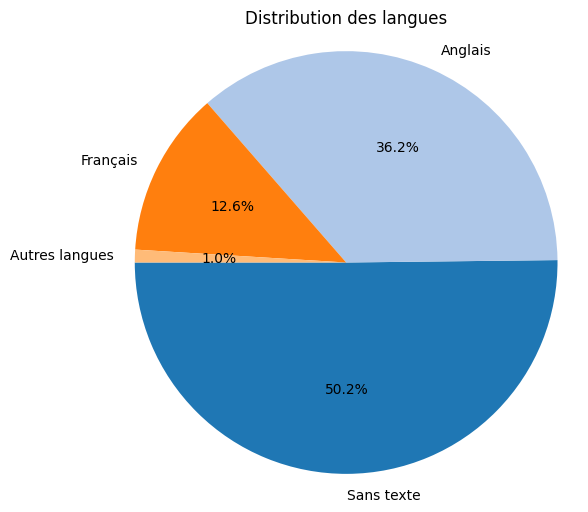

In [48]:
import matplotlib.pyplot as plt

# 数据

mapping = {
    "no_text": "Sans texte",
    "en": "Anglais",
    "fr": "Français",
    "other_langs": "Autres langues"
}

df_all["lang_clean"] = df_all["lang"].map(mapping)


data = (
    df_all["lang_clean"]
    .value_counts(dropna=False, normalize=True)
    .reset_index()
)
data.columns = ["lang", "share"]
colors = plt.cm.tab20.colors[:len(data)]

plt.figure(figsize=(6, 6))
plt.pie(
    data["share"],              # 数值
    labels=data["lang"],        # 标签
    autopct='%1.1f%%',
    colors=colors,
    startangle=180
)
plt.title("Distribution des langues")
plt.axis('equal')
plt.show()

# global

In [6]:
df=df_all.copy()
agg=df.groupby(['in_paris'])[tactics_bio+tactics_pic_dummies].mean().reset_index()
agg_long=agg.melt(
    id_vars=['in_paris'],
    value_vars=tactics_bio+tactics_pic_dummies,
    var_name='variable',
    value_name='mean'
)
agg_long

,in_paris,variable,mean
0,0,ouverture,-0.112285
1,1,ouverture,-0.088060
2,0,authenticité,-0.201552
3,1,authenticité,-0.150967
4,0,sociabilité,-0.076398
5,1,sociabilité,-0.054686
6,0,auto_promotion,0.204346
7,1,auto_promotion,0.099130
8,0,exemplarité,0.035713
9,1,exemplarité,0.031788


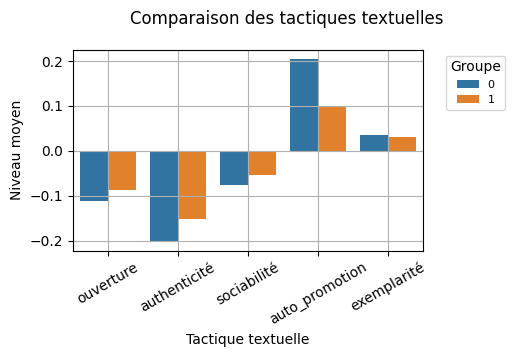

In [ ]:
# vis
palette={
    0:'tab:blue',
    1:'tab_orange'
}

tactics=tactics_bio
df_plot=agg_long[agg_long['variable'].isin(tactics)].copy()

fig, ax=plt.subplots(figsize=(6,4))

sns.barplot(
    data=df_plot,   
    x="variable",
    y="mean",
    hue="in_paris",
    # palette=palette,
    # order=tactics_bio,#***
    # errorbar="sd"
    ax=ax
)
ax.tick_params(axis="x", rotation=30)
ax.set_ylabel("Niveau moyen")
ax.set_xlabel("Tactique textuelle")
ax.grid()

plt.suptitle("Comparaison des tactiques textuelles",fontsize=12)

handles, labels=ax.get_legend_handles_labels()
plt.legend(handles, labels, title="Groupe", loc="upper left", bbox_to_anchor=(1.05, 1), fontsize=8)
plt.tight_layout(rect=[0,0.1, 0.9,1])

plt.show()

In [183]:
df=df_all.copy()
agg=df.groupby(['in_paris','time'])[tactics_bio+tactics_pic_dummies].mean().reset_index()
agg_long=agg.melt(
    id_vars=['in_paris', 'time'],
    value_vars=tactics_bio+tactics_pic_dummies,
    var_name='variable',
    value_name='mean'
)
agg_long['group']=agg_long.apply(lambda row: f"{'Paris' if row['in_paris']==1 else 'Londres'} {row['time']}", axis=1)
map_fr2en={
    'ouverture':'openness',
    'authenticité':'authenticity',
    'sociabilité':"sociability",
    "auto_promotion":"self-promotion",
    "exemplarité":"exemplification",
    "is_portrait":"portrait",
    "is_lifestyle":'lifestyle',
    "no_person":'no-person'
}

agg_long['label_en']=agg_long['variable'].map(map_fr2en)
# agg_long['group_en']=agg_long['group'].apply(lambda x: )

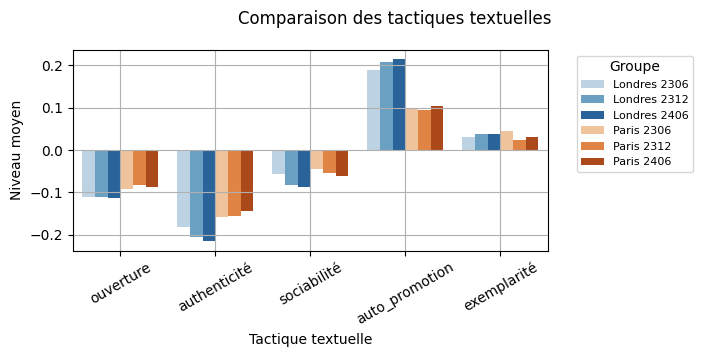

In [159]:
tactics=tactics_bio
df_plot=agg_long[agg_long['variable'].isin(tactics)].copy()
groups=df_plot['group'].unique()

# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 3  # 每组数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))

colors = (
    list(london_colors) +
    list(paris_colors)
)
palette={k: v for k, v in zip (groups, colors)}


# vis
fig, ax=plt.subplots(figsize=(8,4))

sns.barplot(
    data=df_plot,   
    x="variable",
    y="mean",
    hue="group",
    palette=palette,
    order=tactics_bio,#***
    # errorbar="sd"
    ax=ax
)
ax.tick_params(axis="x", rotation=30)
ax.set_ylabel("Niveau moyen")
ax.set_xlabel("Tactique textuelle")
ax.grid()

plt.suptitle("Comparaison des tactiques textuelles",fontsize=12)

handles, labels=ax.get_legend_handles_labels()
plt.legend(handles, labels, title="Groupe", loc="upper left", bbox_to_anchor=(1.05, 1), fontsize=8)
plt.tight_layout(rect=[0,0.1, 0.9,1])

plt.show()
# 整体而言，paris更注重ouv，authen，socio，london的auto更高，exem两者相似


dict_values(['openness', 'authenticity', 'sociability', 'self-promotion', 'exemplification', 'portrait', 'lifestyle', 'no-person'])
['London 2306', 'London 2312', 'London 2406', 'Paris 2306', 'Paris 2312', 'Paris 2406']


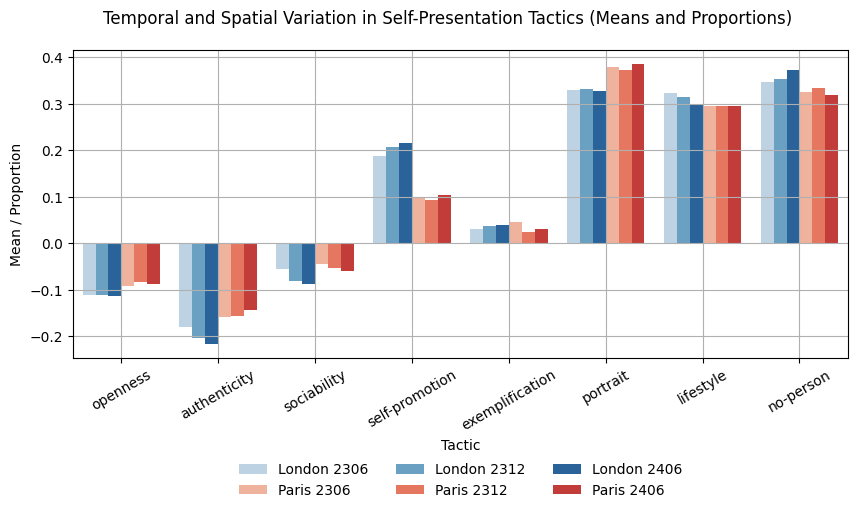

In [205]:
tactics_en=map_fr2en.values()
print(tactics_en)

tactics_bio_en=["openness","authenticity","sociability","self-promotion","exemplification"]
tactics_vis_en=["portrait","lifestyle",'no-person']

# 'ouverture':'openness',
#     'authenticité':'authenticity',
#     'sociabilité':"sociability",
#     "auto_promotion":"self-promotion",
#     "exemplarité":"exemplification",
#     "is_portrait":"portrait",
#     "is_lifestyle":'lifestyle',
#     "no_person":'no-person'

df_plot=agg_long[agg_long['label_en'].isin(tactics_en)].copy()
# display(df_plot)
df_plot["group"] = df_plot["group"].replace({
    "Londres 2306": "London 2306",
    "Londres 2312": "London 2312",
    "Londres 2406": "London 2406",
    "Paris 2306": "Paris 2306",
    "Paris 2312": "Paris 2312",
    "Paris 2406": "Paris 2406",
})
groups=df_plot['group'].unique()


# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 3  # 每组数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))


pink_cmap = plt.cm.Reds  # 或 Pink
paris_colors = pink_cmap(np.linspace(0.3, 0.7, n))

colors = (
    list(london_colors) +
    list(paris_colors)
)
palette={k: v for k, v in zip (groups, colors)}

# vis
fig, ax= plt.subplots(figsize=(10,4))

sns.barplot(
    data=df_plot,#[df_plot['label_en'].isin(tactics_bio_en)],   
    x="label_en",
    y="mean",
    hue="group",
    palette=palette,
    order=tactics_en,#***
    # errorbar="sd"
    ax=ax,
    # legend=False
)

ax.tick_params(axis="x", rotation=30)
ax.set_ylabel("Mean / Proportion")
ax.set_xlabel("Tactic")
ax.grid()

# sns.barplot(
#     data=df_plot[df_plot['label_en'].isin(tactics_vis_en)],  
#     # data=df_plot[df_plot["type"]=="visual"],
#     x="label_en",
#     y="mean",
#     hue="group",
#     ax=ax2,
#     palette=palette,
#     legend=False
# )
# ax2.set_ylabel("Proportion (Visual)")


handles, labels = ax.get_legend_handles_labels()
print(labels)
order = [0, 3, 1, 4, 2, 5]
handles = [handles[i] for i in order]
labels  = [labels[i] for i in order]

ax.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.3),
    ncol=3,
    frameon=False
)

# ax.legend(
#     handles,
#     labels,
#     loc='upper center',
#     bbox_to_anchor=(0.5, -0.3),
#     ncol=3,   # 横向排列关键
#     frameon=False,
    
# )

plt.suptitle("Temporal and Spatial Variation in Self-Presentation Tactics (Means and Proportions)", fontsize=12)

plt.show()

C:\Users\yeliu\AppData\Local\Temp\ipykernel_4408\1811378941.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


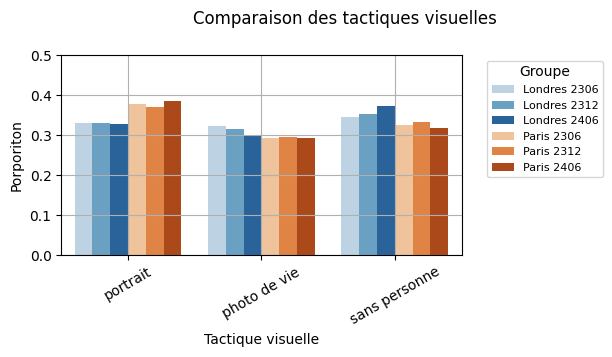

In [8]:
tactics=tactics_pic_dummies
label_map={'is_portrait':"portrait",
           'is_lifestyle':'photo de vie',
           "no_person":"sans personne"}

df_plot=agg_long[agg_long['variable'].isin(tactics)].copy()
groups=df_plot['group'].unique()

# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 3  # 每组数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))

colors = (
    list(london_colors) +
    list(paris_colors)
)
palette={k: v for k, v in zip (groups, colors)}


# vis
fig, ax=plt.subplots(figsize=(7,4))

sns.barplot(
    data=df_plot,   
    x="variable",
    y="mean",
    hue="group",
    palette=palette,
    order=tactics,#***
    # errorbar="sd"
    ax=ax
)

ax.set_ylim(0, 0.5)
ax.set_xticklabels(
    [label_map[x.get_text()] for x in ax.get_xticklabels()],
    rotation=30
)
# ax.set_xticklabels([label_map[x.get_text()] for x in ax.get_xticklabels],rotation=30)
ax.tick_params(axis="x", rotation=30)
ax.set_ylabel("Porporiton")
ax.set_xlabel("Tactique visuelle")
ax.grid()

plt.suptitle("Comparaison des tactiques visuelles",fontsize=12)

handles, labels=ax.get_legend_handles_labels()

plt.legend(handles, labels, title="Groupe", loc="upper left", bbox_to_anchor=(1.05, 1), fontsize=8)
plt.tight_layout(rect=[0,0.1, 0.9,1])

plt.show()
# 整体而言，paris更注重ouv，authen，socio，london的auto更高，exem两者相似



In [71]:
def get_event_study_data(model, var):
    params = model.params
    bse = model.bse
    pvalues=model.pvalues
    
    # 提取 interaction terms
    data = pd.DataFrame({
        "coef": params,
        "se": bse,
        'pval':pvalues
    }).reset_index()

    data.columns = ["variable", "coef", "se", "pval"]

    # 只保留 in_paris × time
    data = data[data["variable"].str.contains("in_paris:C\\(time\\)")]    
    
    # 提取时间点
    data["time"] = data["variable"].str.extract(r"T\.(\d+)")

    # 排序
    data = data.sort_values("time")

    # 置信区间
    data["ci_low"] = data["coef"] - 1.96 * data["se"]
    data["ci_high"] = data["coef"] + 1.96 * data["se"]
    
    # baseline（2306 = 0）
    baseline = pd.DataFrame({
        "time": ["2306"],
        "coef": [0],
        "ci_low": [0],
        "ci_high": [0]
    })

    data = pd.concat([baseline, data], ignore_index=True)

    data = data.sort_values("time")
    data['variable']=var
    data['sig']=data['pval'].apply(p_to_sig)        
    # data['label']=data['time']+' '+data['sig']        
    
    return data

df=df_all.copy()
results=[]
tactics=tactics_bio+tactics_pic_dummies
for var in tactics:
    formula= (f"{var} ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
                    "number_of_reviews_ltm + "
                    "C(host_is_superhost) +"
                    "years_since_host + professional_host + "
                    "host_response_rate +  C(host_response_time)+"
                    "has_text + lang_en + lang_fr + text_length+"
                    "price  + availability_90 + C(room_type) + C(instant_bookable) + "
                    "C(time) + in_paris * C(time)"
            )
    model_tactic=smf.ols(formula, data=df).fit()
    # print(model_tactic.summary())    
    res=get_event_study_data(model_tactic, var)
    results.append(res)

results_did_evolution=pd.concat(results, axis=0)
display(results_did_evolution)



,time,coef,ci_low,ci_high,variable,se,pval,sig
0,2306,0.000000,0.000000,0.000000,ouverture,NaN,NaN,
1,2312,0.005668,-0.006977,0.018313,ouverture,0.006452,3.796275e-01,
2,2406,0.001713,-0.010052,0.013477,ouverture,0.006002,7.753645e-01,
0,2306,0.000000,0.000000,0.000000,authenticité,NaN,NaN,
1,2312,0.029654,0.016556,0.042753,authenticité,0.006683,9.113254e-06,***
2,2406,0.043697,0.031511,0.055884,authenticité,0.006218,2.099537e-12,***
0,2306,0.000000,0.000000,0.000000,sociabilité,NaN,NaN,
1,2312,0.022324,0.008787,0.035861,sociabilité,0.006906,1.228010e-03,**
2,2406,0.034783,0.022189,0.047377,sociabilité,0.006426,6.193342e-08,***
0,2306,0.000000,0.000000,0.000000,auto_promotion,NaN,NaN,


In [73]:
sub=results_did_evolution[(results_did_evolution['time']=="2312")&(results_did_evolution['variable']==var)]
print(sub)

sig_did=sub['sig'].iloc[0]
sig_did

   time      coef    ci_low   ci_high   variable        se      pval sig
1  2312 -0.001622 -0.010062  0.006819  no_person  0.004306  0.706482    


''

C:\Users\yeliu\AppData\Local\Temp\ipykernel_34192\2334051034.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1,1])


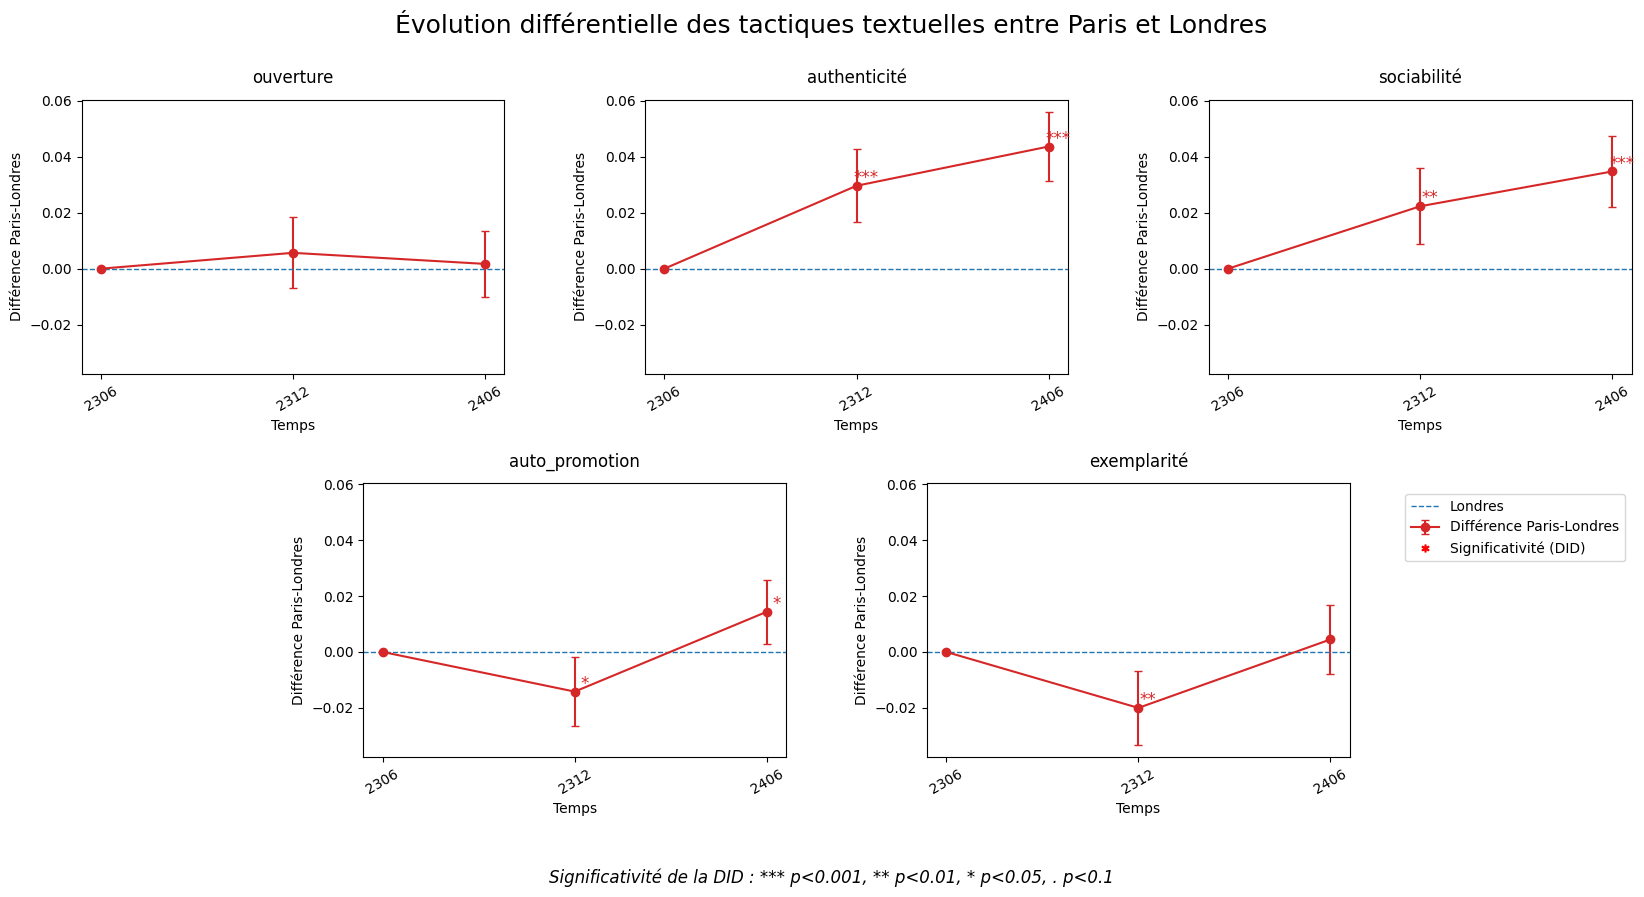

In [74]:
from utils import modeling_did
importlib.reload(modeling_did)
from utils.modeling_did import plot_one_did

# ---layout---
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec

# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))# sharey=True
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4], sharey=ax1)
ax3 = fig.add_subplot(gs[0, 4:6], sharey=ax1)
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3], sharey=ax1)
ax5 = fig.add_subplot(gs[1, 3:5], sharey=ax1)
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
# n_to_plot = min(len(tactics), len(axes))


tactics=tactics_bio
df_plot=results_did_evolution.copy()#[results_did_evolution['variable'].isin(tactics)].copy()

for i, var in enumerate(tactics):
    plot_one_did(data=df_plot, axes=axes, i=i, var=var, title=None)
    
# --------------------legend------------------------
fig.suptitle(
        "Évolution différentielle des tactiques textuelles entre Paris et Londres",
        fontsize=18,
        y=0.98 #大标题到子图的距离, 越大越远
    )

from matplotlib.lines import Line2D
handles, labels = axes[0].get_legend_handles_labels()
# --- add custom legend :sig note ---
handles.append(
    Line2D([0], [0], marker='$*$', linestyle='None', color='red', markersize=5,
           label='Significativité (DID)')
)
labels = labels + [
    "Significativité (DID)"
]

fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.9,0.45) # legend (x, y)，x>1则在图外, y=0在底线
)

plt.figtext(
    0.5, 0.01,
    "Significativité de la DID : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic"   
)

plt.tight_layout(rect=[0, 0.1, 1,1])
plt.subplots_adjust(bottom=0.15)#控制子图到底的距离，给text留出空间
plt.show()


C:\Users\yeliu\AppData\Local\Temp\ipykernel_34192\1826942224.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.8,1])


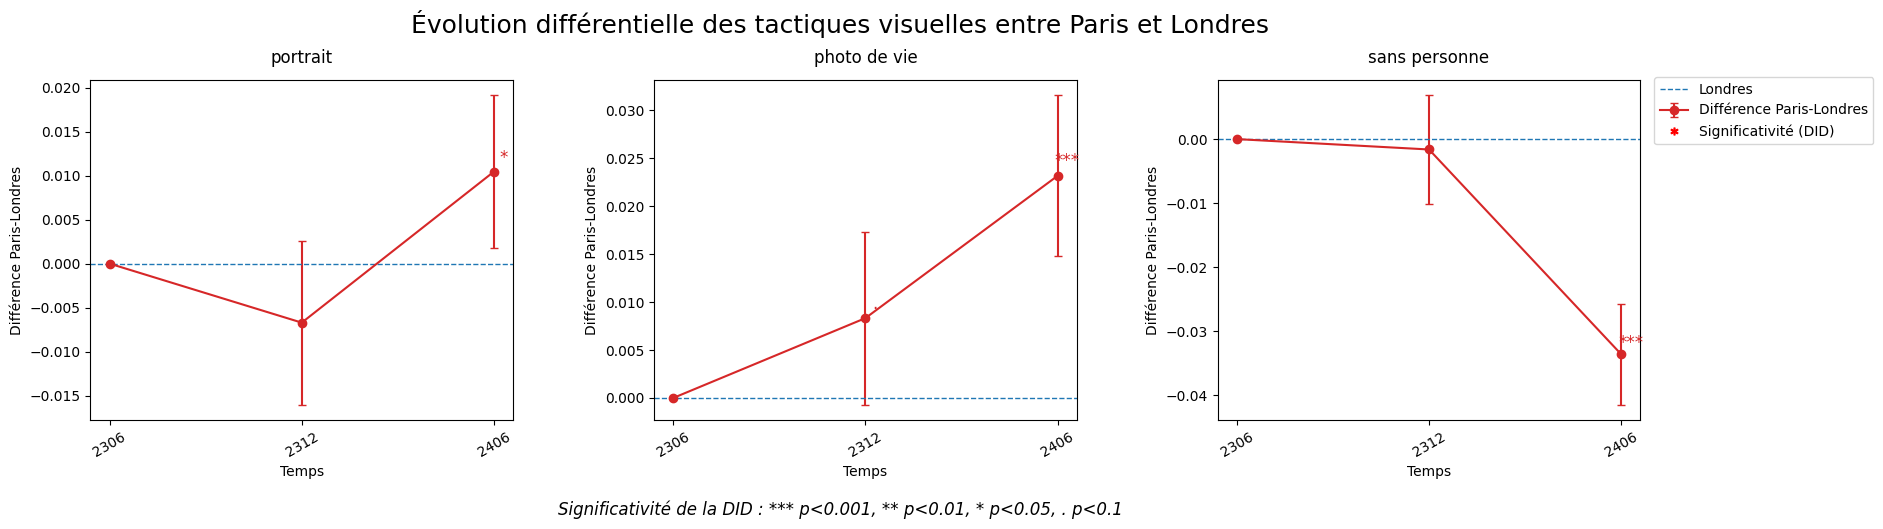

In [75]:
# ---layout---
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,5))# sharey=True
gs = gridspec.GridSpec(1, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])


## plot

tactics=tactics_pic_dummies
tactics_pic_labels=['portrait','photo de vie','sans personne']
var_map=dict(zip(tactics_pic_dummies,tactics_pic_labels))

df_plot=results_did_evolution.copy()

for i, var in enumerate(tactics):
    plot_one_did(data=df_plot, axes=axes, i=i, var=var, title=var_map.get(var))
    
      
# layout 3facets:
fig.suptitle(
        "Évolution différentielle des tactiques visuelles entre Paris et Londres",
        fontsize=18,
        y=1.02
    )

# --------------------legend------------------------
from matplotlib.lines import Line2D
handles, labels = axes[0].get_legend_handles_labels()
# --- add custom legend :sig note ---
handles.append(
    Line2D([0], [0], marker='$*$', linestyle='None', color='red', markersize=5,
           label='Significativité (DID)')
)
labels = labels + [
    "Significativité (DID)"
]

fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(1.02,0.9) # legend (x, y)，x>1则在图外, y=0在底线
)
plt.figtext(
    0.5, 0.01,
    "Significativité de la DID : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic"   
)

plt.tight_layout(rect=[0, 0.1, 0.8,1])
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()
## ddd只能说明paris相对于london的变化，但是不知道是paris提升还是london下降，比如lifestyle中就是paris不变，但是london大幅下降了

# 总体上por上升，vie不变，sans下降！

In [79]:
## variation de did
specs=[
    """    
    in_paris:C(time)[T.2406]
    -in_paris:C(time)[T.2312]  
    """
]

df=df_all.copy()
results=[]
var_map={
    # 'auto_promotion':"auto-promotion",
    'is_portrait':"portrait",
    "is_lifestyle":'photo de vie',
    "no_person":'sans personne'
}

for var in tactics_bio+tactics_pic_dummies:
    formula= (f"{var} ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
                "number_of_reviews_ltm + "
                "C(host_is_superhost) +"
                "years_since_host + professional_host + "
                "host_response_rate +  C(host_response_time)+"
                "has_text + lang_en + lang_fr + text_length+"
                "price  + availability_90 + C(room_type) + C(instant_bookable) + "
                "C(time) + in_paris * C(time)"
        )
    model_tactic=smf.ols(formula, data=df).fit(cov_type="HC1")

    for i, term in enumerate(specs):
        test = model_tactic.t_test(term)
        sig=p_to_sig(test.pvalue)
        res= pd.DataFrame({
            'variable':var,
            "coef": test.effect[0],
            "se": test.sd[0],
            "pval": test.pvalue,
            "sig":sig,
            "ci_low": test.conf_int()[0][0],
            "ci_high": test.conf_int()[0][1],
            'label':f"{var_map.get(var,'') if var in var_map else var}"
        })
        results.append(res)

results_did_diff=pd.concat(results, axis=0)
display(results_did_diff)
### paris比london在2406的gap，减去它们在2312的gap（pretrend），比较gap变化
# 如果有冲击，会有显著变化gap change

,variable,coef,se,pval,sig,ci_low,ci_high,label
0,ouverture,-0.003955,0.005843,4.984752e-01,,-0.015408,0.007498,ouverture
0,authenticité,0.014043,0.006047,2.021296e-02,*,0.002191,0.025895,authenticité
0,sociabilité,0.012459,0.006258,4.647603e-02,*,0.000194,0.024724,sociabilité
0,auto_promotion,0.028564,0.005676,4.846220e-07,***,0.017439,0.039688,auto_promotion
0,exemplarité,0.024492,0.006055,5.234302e-05,***,0.012624,0.036359,exemplarité
0,is_portrait,0.017154,0.004329,7.429062e-05,***,0.008668,0.025639,portrait
0,is_lifestyle,0.014838,0.004186,3.924580e-04,***,0.006635,0.023042,photo de vie
0,no_person,-0.031992,0.003941,4.778351e-16,***,-0.039717,-0.024267,sans personne


In [212]:
##+fit(cov_type="HC1")
# fig, ax=plt.subplots(figsize=(6,5))
pink = (222/255, 2/255, 100/255)

change_colors=pink
sub=results_did_diff.copy()

tactics=tactics_bio+['portrait','photo de vie','sans personne']
order=tactics[::-1]
sub=sub.set_index('label').loc[order].reset_index()
map_fr2en={
    'ouverture':'openness',
    'authenticité':'authenticity',
    'sociabilité':"sociability",
    "auto_promotion":"self-promotion",
    "exemplarité":"exemplification",
    "is_portrait":"portrait",
    "is_lifestyle":'lifestyle',
    "no_person":'no-person'
}
sub['label_en']=sub['variable'].map(map_fr2en)
sub



,label,variable,coef,se,pval,sig,ci_low,ci_high,label_en
0,sans personne,no_person,-0.031992,0.003941,4.778351e-16,***,-0.039717,-0.024267,no-person
1,photo de vie,is_lifestyle,0.014838,0.004186,3.924580e-04,***,0.006635,0.023042,lifestyle
2,portrait,is_portrait,0.017154,0.004329,7.429062e-05,***,0.008668,0.025639,portrait
3,exemplarité,exemplarité,0.024492,0.006055,5.234302e-05,***,0.012624,0.036359,exemplification
4,auto_promotion,auto_promotion,0.028564,0.005676,4.846220e-07,***,0.017439,0.039688,self-promotion
5,sociabilité,sociabilité,0.012459,0.006258,4.647603e-02,*,0.000194,0.024724,sociability
6,authenticité,authenticité,0.014043,0.006047,2.021296e-02,*,0.002191,0.025895,authenticity
7,ouverture,ouverture,-0.003955,0.005843,4.984752e-01,,-0.015408,0.007498,openness


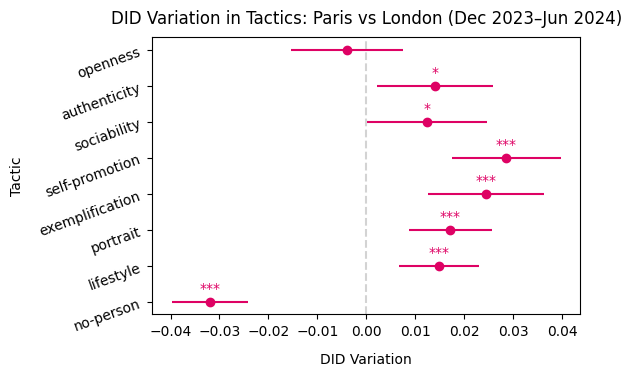

In [226]:
##+fit(cov_type="HC1")
fig, ax=plt.subplots(figsize=(6,4))
pink = (222/255, 2/255, 100/255)

change_colors=pink
sub=results_did_diff.copy()

tactics=tactics_bio+['portrait','photo de vie','sans personne']
order=tactics[::-1]
sub=sub.set_index('label').loc[order].reset_index()
map_fr2en={
    'ouverture':'openness',
    'authenticité':'authenticity',
    'sociabilité':"sociability",
    "auto_promotion":"self-promotion",
    "exemplarité":"exemplification",
    "is_portrait":"portrait",
    "is_lifestyle":'lifestyle',
    "no_person":'no-person'
}
sub['label_en']=sub['variable'].map(map_fr2en)

# ---plot---
ax.errorbar(
    x=sub["coef"],
    y=sub["label_en"],
    # y=y,
    xerr=[sub["coef"] - sub["ci_low"], sub["ci_high"] - sub["coef"]],
    fmt='o', 
    color=change_colors,
    # linestyle='-' if new==1 else '--'
)
# ---sig---
for _, row in sub.iterrows():
    ax.annotate(
        row["sig"],
        xy=(row["coef"], row["label_en"]),
        xytext=(0, 10),         
        textcoords='offset points',
        ha='center',
        va='center',
        fontsize=10,
        color=change_colors
)    
        
ax.axvline(0, linestyle='--', color="lightgray", label="Changement de Londres")    
ax.set_xlabel(f"DID Variation", labelpad=10)
ax.set_ylabel('Tactic', labelpad=10)
ax.tick_params(axis='y', rotation=20)
# ax.set_title()

# fig.suptitle(
#     "    DID Variation in Tactics : Paris vs London (Dec 2023–Jun 2024)",
#     # "DID Variation in Self-Presentation Tactics between Paris and London (Dec 2023–Jun 2024)",
#     # "Variation de DID du niveau des tactiques entre Paris et Londres (déc. 2023-juin 2024)",
#     fontsize=12,
#     loc='center',
#     y=0.95
# )
ax.set_title(
    "DID Variation in Tactics: Paris vs London (Dec 2023–Jun 2024)",
    loc="center",
    pad=10
)
# plt.figtext(
#     0.5, 0.01,
#     "Significativité de la variation de DID : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
#     ha="center",
#     fontsize=10,
#     style="italic",   
# )
plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()

In [ ]:
fig, ax=plt.subplots(figsize=(6,5))
change_colors='tab:red'
sub=results_did_diff.copy()

tactics=tactics_bio+['portrait','photo de vie','sans personne']
order=tactics[::-1]
sub=sub.set_index('label').loc[order].reset_index()


# ---plot---
ax.errorbar(
    x=sub["coef"],
    y=sub["label"],
    # y=y,
    xerr=[sub["coef"] - sub["ci_low"], sub["ci_high"] - sub["coef"]],
    fmt='o', 
    color=change_colors,
    # linestyle='-' if new==1 else '--'
)
# ---sig---
for _, row in sub.iterrows():
    ax.annotate(
        row["sig"],
        xy=(row["coef"], row["label"]),
        xytext=(0, 10),         
        textcoords='offset points',
        ha='center',
        va='center',
        fontsize=10,
        color=change_colors
)    
        
ax.axvline(0, linestyle='--', color="lightgray", label="Changement de Londres")    
ax.set_xlabel(f"Variation de DID", labelpad=10)
ax.set_ylabel('Tactique', labelpad=10)
ax.tick_params(axis='y', rotation=20)
# ax.set_title()

fig.suptitle(
    "Variation de DID du niveau des tactiques entre Paris et Londres (déc. 2023-juin 2024)",
    # "Evolution de l'écart des niveaux de tactiques entre Paris et Londres (déc. 2023 - juin 2024)", 
    fontsize=14,
    y=1
)

plt.figtext(
    0.5, 0.01,
    "Significativité de la variation de DID : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=10,
    style="italic",   
)
plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()

['ouverture', 'authenticité', 'sociabilité', 'auto_promotion', 'exemplarité', 'portrait', 'photo de vie', 'sans personne']


TypeError: only list-like objects are allowed to be passed to isin(), you passed a `str`

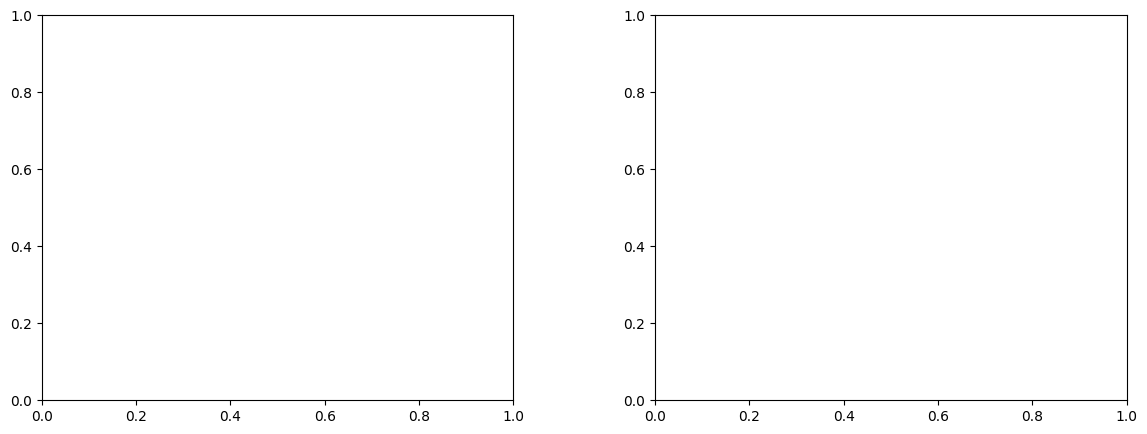

In [ ]:
# xxxxxx
# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.5, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.5, 0.8, n))

## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(14, 5)) 
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2])#**
axes.extend([ax1, ax2])


df_plot=results_ddd_all.copy()
color_change="tab:red"
tactics=tactics_bio+['portrait','photo de vie','sans personne']
print(tactics)

for i, tactics in enumerate(tactics):
    sub=df_plot[df_plot['label'].isin(tactics)].copy()
    display(sub)
    order = tactics[::-1]
    sub = sub.set_index("label").loc[order].reset_index()    
    ax=axes[i]
    
    # #规定顺序：
    # sub['variable']=pd.Categorical(
    #     sub['variable'],
    #     categories=tactics[::-1],
    #     ordered=True
    # )    
    
    display(sub)# 5/3

    ax.errorbar(
        x=sub["coef"],
        y=sub["label"],
        xerr=[sub["coef"] - sub["ci_low"], sub["ci_high"] - sub["coef"]],
        fmt='o', 
        color=color_change
    )
    # ---sig---
    for _, row in sub.iterrows():
        ax.annotate(
            row["sig"],
            xy=(row["coef"], row["label"]),
            xytext=(0, 10), 
            textcoords='offset points',
            ha='center',
            va='center',
            fontsize=12,
            color=color_change
    )    
            
    ax.axvline(0, linestyle='--', color="lightgray", label="Changement de Londres")    
    ax.set_xlabel(f"Différentiel d'évolution {'du niveau' if i==0 else 'de la proportion'}", labelpad=10)
    ax.set_ylabel('Tactique')
    ax.tick_params(axis='y', rotation=20)
    ax.set_title(f"{'Tactiques textuelles' if i==0 else 'Tactiques visuelles'}")

# ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)


# ## ---legend 2facets----
fig.suptitle(
    # "Différence des différences des"
    "Évolution différentielle du niveaux de tactiques entre Paris et Londres (déc.2023 - juin 2024)", 
    fontsize=16,
    y=1.01
)
# (Paris−London)2406​−(Paris−London)2312​!!!!!
# ddd=did2406-did2312,在变化中再减去pre-trend


plt.figtext(
    0.5, 0.01,
    "Significativité de DDD : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=10,
    style="italic",   
)
plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()

# ==paris从2306到2406的变化减去自然变化（london）==jo带来的额外变化
# ?? 考虑不平行趋势了吗？
# 提升所有text，和有人物的头像


In [81]:
## real+cf effet 
def get_cf_data(df, model, var):
    """
    不改变时间，不改变地点，仅减去jo（交互项之差）
    """    
    df["y_hat"] = model.predict(df)
    term = ('''
        in_paris:C(time)[T.2406]
        - in_paris:C(time)[T.2312]
    '''
    )
    #jo shock，没有2406-2312则是paris shock
    #将2312作为了变化的基准，所以不用考虑2306-2312的不平行
    
    test = model.t_test(term)
    adjustment=test.effect[0]
    pval=test.pvalue
    sig=p_to_sig(pval)
               
    print(f'ddd of {var}: {adjustment} {sig}')
    df["y_cf"] = df["y_hat"]

    df.loc[
        (df["in_paris"]==1) & (df["time"]=="2406"),
        "y_cf"
    ] -= adjustment #==去掉2406交互项，再加一次2312交互项
    
    agg=df.groupby(['in_paris','time'])[['y_hat','y_cf']].mean().reset_index()
    agg['variable']=var
    
    var_map={
        'is_portrait':"portrait",
        "is_lifestyle":'photo de vie',
        "no_person":'sans personne'
    }
    agg['label']=agg['variable'].apply(lambda x: var_map.get(x,'') if x in var_map.keys() else x)
    
    # +pval +sig
    agg["pval"] = np.nan 
    agg["sig"] = np.nan 
    agg.loc[
        (agg['in_paris']==1)&(agg['time']=="2406"),
        'var_did'
            ]=adjustment
    agg.loc[
        (agg['in_paris']==1)&(agg['time']=="2406"),
        'pval'
            ]=pval
    agg.loc[
        (agg['in_paris']==1)&(agg['time']=="2406"),
        'sig'
            ]=sig
    
    return agg 

aggs=[]
for var in tactics_bio+tactics_pic_dummies:
    # var='authenticité'
    print(var)
    formula= (f"{var} ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
                    "number_of_reviews_ltm + "
                    "C(host_is_superhost) +"
                    "years_since_host + professional_host + "
                    "host_response_rate +  C(host_response_time)+"
                    "has_text + lang_en + lang_fr + text_length+"
                    "price  + availability_90 + C(room_type) + C(instant_bookable) + "
                    "C(time) + in_paris * C(time)"
            )
    model_tactic=smf.ols(formula, data=df_all).fit(cov_type="HC1")
    agg=get_cf_data(df=df_all, model=model_tactic, var=var)
    aggs.append(agg)
    # break
cf_data=pd.concat(aggs,axis=0)
cf_data

ouverture
ddd of ouverture: -0.003955410205441894 
authenticité


C:\Users\yeliu\AppData\Local\Temp\ipykernel_34192\3241816529.py:49: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  agg.loc[


ddd of authenticité: 0.014043224391017566 *
sociabilité


C:\Users\yeliu\AppData\Local\Temp\ipykernel_34192\3241816529.py:49: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '*' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  agg.loc[


ddd of sociabilité: 0.012459292106811095 *
auto_promotion


...

ddd of is_lifestyle: 0.014838140513398013 ***
no_person


C:\Users\yeliu\AppData\Local\Temp\ipykernel_34192\3241816529.py:49: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '***' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  agg.loc[


ddd of no_person: -0.03199182415614951 ***


C:\Users\yeliu\AppData\Local\Temp\ipykernel_34192\3241816529.py:49: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '***' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  agg.loc[


,in_paris,time,y_hat,y_cf,variable,label,pval,sig,var_did
0,0,2306,-0.111349,-0.111349,ouverture,ouverture,NaN,NaN,NaN
1,0,2312,-0.111726,-0.111726,ouverture,ouverture,NaN,NaN,NaN
2,0,2406,-0.113564,-0.113564,ouverture,ouverture,NaN,NaN,NaN
3,1,2306,-0.093083,-0.093083,ouverture,ouverture,NaN,NaN,NaN
4,1,2312,-0.083193,-0.083193,ouverture,ouverture,NaN,NaN,NaN
5,1,2406,-0.088205,-0.084249,ouverture,ouverture,4.984752e-01,,-0.003955
0,0,2306,-0.181066,-0.181066,authenticité,authenticité,NaN,NaN,NaN
1,0,2312,-0.204839,-0.204839,authenticité,authenticité,NaN,NaN,NaN
2,0,2406,-0.216109,-0.216109,authenticité,authenticité,NaN,NaN,NaN
3,1,2306,-0.158274,-0.158274,authenticité,authenticité,NaN,NaN,NaN


In [ ]:

var='sociabilité'
display(cf_data[cf_data['variable']==var])

,in_paris,time,y_hat,y_cf,variable,label,pval,sig
0,0,2306,-0.056410,-0.056410,sociabilité,sociabilité,NaN,NaN
1,0,2312,-0.082297,-0.082297,sociabilité,sociabilité,NaN,NaN
2,0,2406,-0.088271,-0.088271,sociabilité,sociabilité,NaN,NaN
3,1,2306,-0.044763,-0.044763,sociabilité,sociabilité,NaN,NaN
4,1,2312,-0.053823,-0.053823,sociabilité,sociabilité,NaN,NaN
5,1,2406,-0.060383,-0.072842,sociabilité,sociabilité,0.04833,*


In [ ]:
## check
agg=df_all.groupby(['in_paris','time'])[tactics_bio+tactics_pic_dummies].mean().reset_index()
agg_long=agg.melt(
    id_vars=['in_paris','time'],
    value_vars=tactics_bio+tactics_pic_dummies,
    var_name='variable',
    value_name='mean'
)
agg_long[agg_long['variable']==var]

,in_paris,time,variable,mean
12,0,2306,sociabilité,-0.056410
13,0,2312,sociabilité,-0.082297
14,0,2406,sociabilité,-0.088271
15,1,2306,sociabilité,-0.044763
16,1,2312,sociabilité,-0.053823
17,1,2406,sociabilité,-0.060383


['ouverture' 'authenticité' 'sociabilité' 'auto_promotion' 'exemplarité']


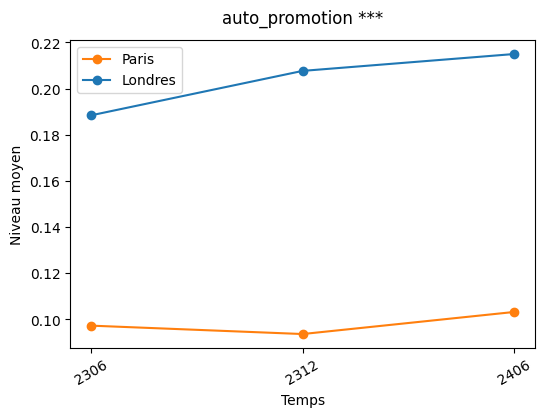

In [102]:
def plot_one_cf(cf_data, axes=None, i=0,  var="authenticité", title=None, ylabel=None, cf=False):
    if not axes:
        fig, ax=plt.subplots(figsize=(6,4))
    else :
        ax=axes[i]

    sub=cf_data[cf_data['label']==var]
    # display(sub)
    
    x=list(range(len(sub['time'].unique())))
    # print("axis x :", x)
    
    ## plt
    paris = sub[sub["in_paris"] == 1]    
    # ---paris obs---
    ax.plot(
        x,
        # paris["time"],#.map(time_map),        
        paris["y_hat"],
        marker="o",
        label="Paris",
        # label="Observé (Paris)",
        color='tab:orange'
    )    
    
    if cf==True:
        # ---paris cf---
        ax.plot(
            x,
            # paris["time"],#.map(time_map),
            paris["y_cf"],
            marker="o",
            linestyle="--",
            label="Contrefactuel(Paris)",
            color='tab:orange'
        )
        # + sig
        ddd_sig=sub[(sub['in_paris']==1)&(sub['time']=="2406")]['sig'].iloc[0]
        xi,yi, sig=2, paris[paris["time"]=="2406"]['y_cf'].iloc[0],ddd_sig
        ax.text(xi, yi + 0.002, sig, ha='center', 
            color='tab:orange', fontsize=12)
    
    
    # ---london obs---
    control = sub[sub["in_paris"] == 0]
    ax.plot(
        control["time"],#.map(time_map),
        control["y_hat"],
        marker="o",
        # alpha=0.4,
        label="Londres",
        # label="Observé (Londres)",
        color='tab:blue'
    )
    
    ax.set_xticks(x)
    ax.set_xticklabels(sub['time'].unique())
    ax.tick_params(axis='x', rotation=30)
    
    ylabel="Niveau moyen" if ylabel is None else ylabel
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Temps")

    title=var if title==None else title
    ddd_sig=sub[(sub['in_paris']==1)&(sub['time']=="2406")]['sig'].iloc[0]

    ax.set_title(f"{title} {ddd_sig}", pad=12)
    if not axes:
        ax.legend(fontsize=10)
        
    return 


df_plot=cf_data[cf_data['variable'].isin(tactics_bio)]
print(df_plot.variable.unique())
var='auto_promotion'

plot_one_cf(cf_data=df_plot, axes=None, i=0,  var=var, title=None, ylabel=None)

# plot_one_cf(agg_data, axes=None, i=0,  var=var, ddd_data=ddd_data, title=None, ylabel=None)


tactics:  ['ouverture' 'authenticité' 'sociabilité' 'auto_promotion' 'exemplarité']


C:\Users\yeliu\AppData\Local\Temp\ipykernel_52328\3131752261.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.88,1])


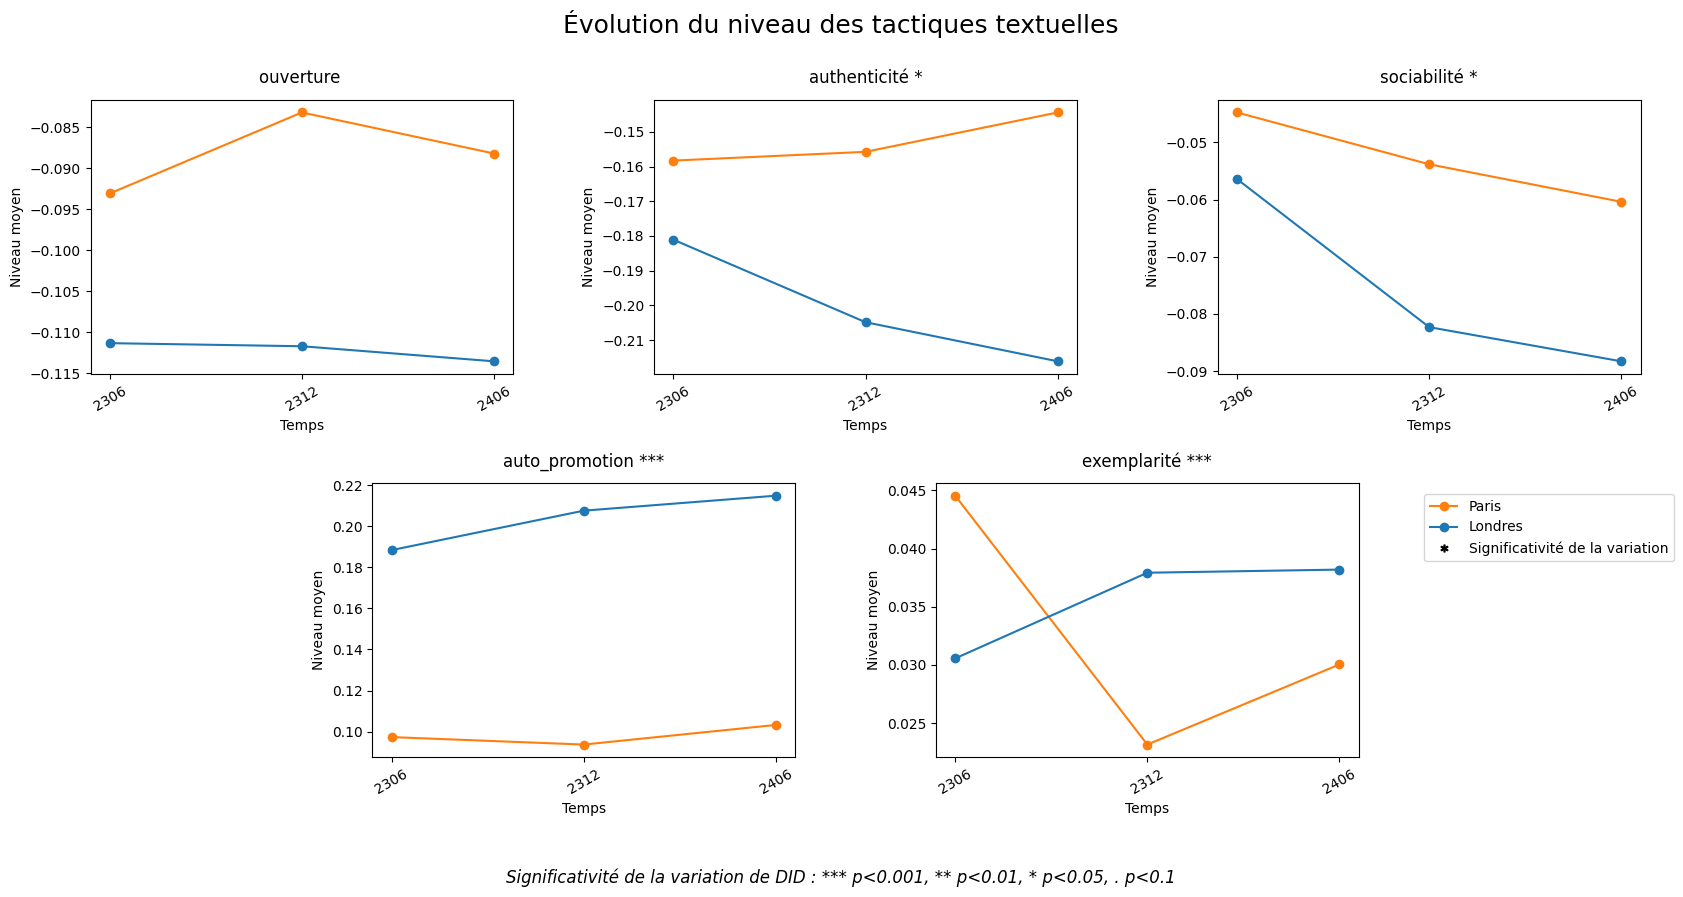

In [27]:

# ---layout---
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))# sharey=True
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
# n_to_plot = min(len(tactics), len(axes))


## plot:
tactics=tactics_bio
df_plot=cf_data[cf_data['label'].isin(tactics)].copy()
print('tactics: ',df_plot.variable.unique())

for i, var in enumerate(tactics):
    plot_one_cf(cf_data=df_plot, axes=axes, i=i,  var=var, title=None, ylabel=None)
    

# layout:
fig.suptitle(
        "Évolution du niveau des tactiques textuelles",
        fontsize=18,
        y=0.98
    )

# --------------------legend------------------------
from matplotlib.lines import Line2D
handles, labels = axes[0].get_legend_handles_labels()
# --- add custom legend :sig note ---
handles.append(
    Line2D([0], [0], marker='$*$', linestyle='None', color='black', markersize=5,
           label='Significativité de la variation')
)
labels = labels + [
    "Significativité de la variation"
]

fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.92,0.45) # legend (x, y)，x>1则在图外, y=0在底线
)

plt.figtext(
    0.5, 0.01,
    "Significativité de la variation de DID : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic"   
)

plt.tight_layout(rect=[0, 0.1, 0.88,1])
plt.subplots_adjust(bottom=0.15)#控制子图到底的距离，给text留出空间
plt.show()

# authen，auto，exem上升，ouv不显著变化，socio下降
# 但是jo都有提升效果！


tactics:  ['portrait' 'photo de vie' 'sans personne']


C:\Users\yeliu\AppData\Local\Temp\ipykernel_52328\890127079.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.8,1])


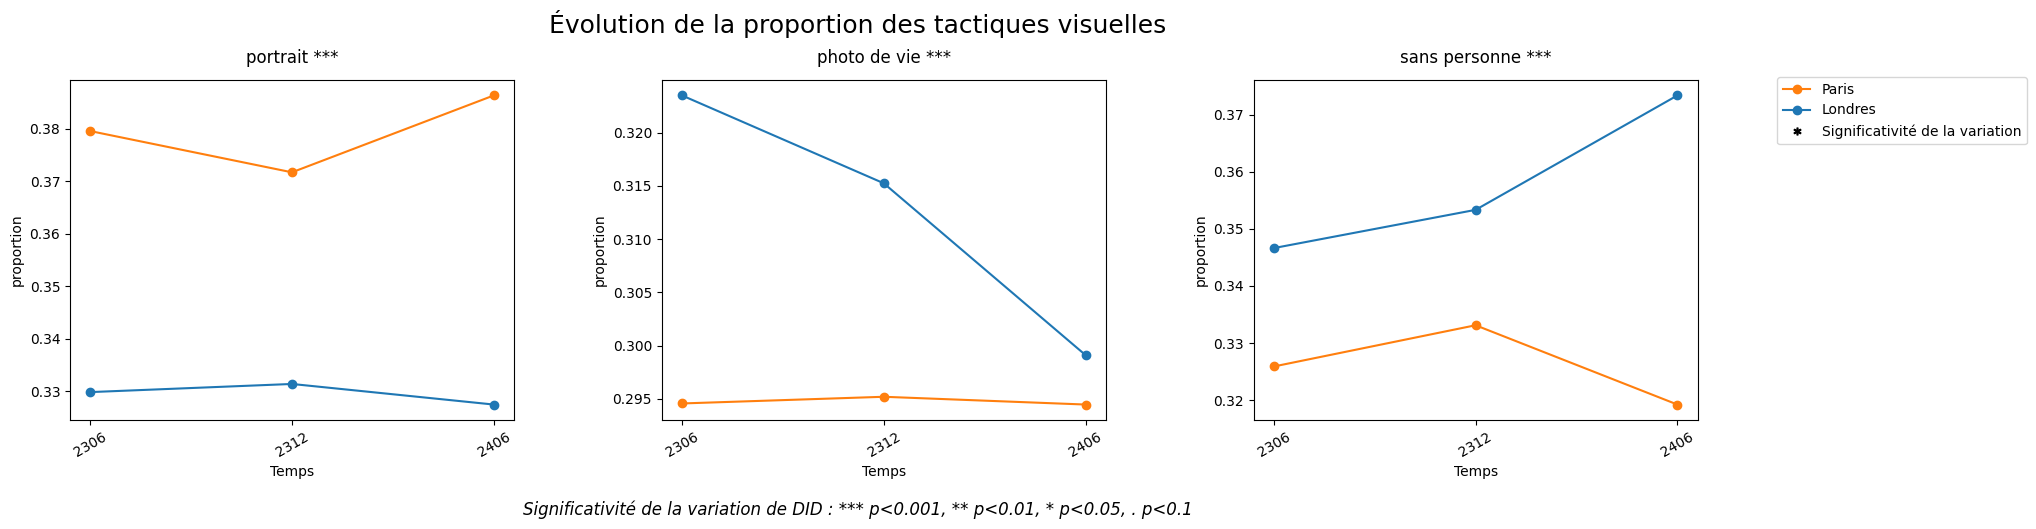

In [28]:

tactics_pic_labels=['portrait','photo de vie','sans personne']
var_map=dict(zip(tactics_pic_dummies,tactics_pic_labels))


# ---layout---
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(21,5))# sharey=True
gs = gridspec.GridSpec(1, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# # 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
# ax4 = fig.add_subplot(gs[1, 1:3])
# ax5 = fig.add_subplot(gs[1, 3:5])
# axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）


## plot:

df_plot=cf_data[cf_data['label'].isin(tactics_pic_labels)].copy() #**
print('tactics: ',df_plot.label.unique())

# title_map={
#     'is_portrait':'Portrait',
#     'is_lifestyle':'Photo de vie',
#     "no_person":"Sans personne"
# }

for i, var in enumerate(tactics_pic_labels):#**
    plot_one_cf(cf_data=df_plot, axes=axes, i=i,  var=var, ylabel='proportion')
      
# layout 3facets:
fig.suptitle(
        "Évolution de la proportion des tactiques visuelles",
        fontsize=18,
        y=1.02
    )

# --------------------legend------------------------
from matplotlib.lines import Line2D
handles, labels = axes[0].get_legend_handles_labels()
# --- add custom legend :sig note ---
handles.append(
    Line2D([0], [0], marker='$*$', linestyle='None', color='black', markersize=5,
           label='Significativité de la variation')
)
labels = labels + [
    "Significativité de la variation"
]

fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(1.06,0.9) # legend (x, y)，x>1则在图外, y=0在底线
)
plt.figtext(
    0.5, 0.01,
    "Significativité de la variation de DID : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic"   
)

plt.tight_layout(rect=[0, 0.1, 0.8,1])
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()
## ddd只能说明paris相对于london的变化，但是不知道是paris提升还是london下降，比如lifestyle中就是paris不变，但是london大幅下降了

# 总体上por上升，vie不变，sans下降！

## bilan de mécanisme?????

In [11]:
cf_data

,in_paris,time,y_hat,y_cf,variable,label,pval,sig,var_did
0,0,2306,-0.111349,-0.111349,ouverture,ouverture,NaN,NaN,NaN
1,0,2312,-0.111726,-0.111726,ouverture,ouverture,NaN,NaN,NaN
2,0,2406,-0.113564,-0.113564,ouverture,ouverture,NaN,NaN,NaN
3,1,2306,-0.093083,-0.093083,ouverture,ouverture,NaN,NaN,NaN
4,1,2312,-0.083193,-0.083193,ouverture,ouverture,NaN,NaN,NaN
5,1,2406,-0.088205,-0.084249,ouverture,ouverture,4.984752e-01,,-0.003955
0,0,2306,-0.181066,-0.181066,authenticité,authenticité,NaN,NaN,NaN
1,0,2312,-0.204839,-0.204839,authenticité,authenticité,NaN,NaN,NaN
2,0,2406,-0.216109,-0.216109,authenticité,authenticité,NaN,NaN,NaN
3,1,2306,-0.158274,-0.158274,authenticité,authenticité,NaN,NaN,NaN


In [26]:
cf_data
var="authenticité"
sub=cf_data[cf_data['variable']==var]
display(sub)

,in_paris,time,y_hat,y_cf,variable,label,pval,sig,var_did
0,0,2306,-0.181066,-0.181066,authenticité,authenticité,NaN,NaN,NaN
1,0,2312,-0.204839,-0.204839,authenticité,authenticité,NaN,NaN,NaN
2,0,2406,-0.216109,-0.216109,authenticité,authenticité,NaN,NaN,NaN
3,1,2306,-0.158274,-0.158274,authenticité,authenticité,NaN,NaN,NaN
4,1,2312,-0.155755,-0.155755,authenticité,authenticité,NaN,NaN,NaN
5,1,2406,-0.144402,-0.158445,authenticité,authenticité,0.020213,*,0.014043


In [58]:
# tactique| host_type | Δ london(2406-2312) | Δ paris(2406-2312)  | variation did | coef+sig | mécanisme



In [139]:
df=cf_data.copy()
df_delta = df[df["time"].isin(["2312", "2406"])].copy()

df_delta = df_delta.pivot_table(
    index=["label", "in_paris"],
    columns="time",
    values="y_hat"
).reset_index()
# display(df_delta)



##--- delta niv---
df_delta["delta"] = df_delta["2406"] - df_delta["2312"]
paris = df_delta[df_delta["in_paris"] == 1].set_index("label")["delta"]
london = df_delta[df_delta["in_paris"] == 0].set_index("label")["delta"]
table = pd.DataFrame({
    "paris_delta": paris,
    "london_delta": london
}).dropna().reset_index()
# display(table)


# ---var did---
df_did = df[(df['in_paris']==1) & (df['time']=="2406")][['label','var_did','sig']]
table=table.merge(df_did[['label','var_did',"sig"]], on="label", how='left')
table['var_did']=table['var_did'].round(4)
# table['coef_sig'] = table['var_did'].astype(str)+ " " + table['sig'].astype(str)
table



# ---mécanisme---

def classify_mechanism(paris_delta, london_delta, var_did, sig):
    if pd.isna(sig) or sig == "":
        return "-"
    if paris_delta * london_delta < 0:    # 反方向
        if var_did > 0: #巴黎上升
            return "divergence positive"
        else :#巴黎下降
            return "divergence négative"  
          
    else:# 同方向
        if var_did > 0 :
            if paris_delta > 0 : # 但巴黎上升更快
                return "accélération relative"# postive
            else :# 但巴黎下降更慢
                return 'atténuation relative'
        else :# var_did < 0
            if paris_delta > 0 :# 但巴黎上升慢 
                return 'atténuation relative'
            else :# 但巴黎下降更快
                return "accélération relative"#négative


#socaiabilité  5	1	2406	-0.060383	-0.072842	sociabilité	sociabilité	4.647603e-02	*	0.012459 #本来会下降更多


table["mecanisme"] = table.apply(
    lambda x: classify_mechanism(x.paris_delta, x.london_delta, x.var_did, x.sig),
    axis=1
)


order = [
    'ouverture',
    'authenticité',
    'sociabilité',
    'auto_promotion',
    'exemplarité',
    'portrait',
    'photo de vie',
    'sans personne'
]

table['label'] = pd.Categorical(table['label'], categories=order, ordered=True)
table = table.sort_values('label')
# display(table)
# clean
# bilan=table.drop(columns=['var_did','sig'])
bilan=table.copy()
bilan.columns=['Tactique','Δ Paris',"Δ Londres", "Variation de DID","Significativité","Mécanisme"]
bilan

,Tactique,Δ Paris,Δ Londres,Variation de DID,Significativité,Mécanisme
3,ouverture,-0.005012,-0.001838,-0.0040,,-
0,authenticité,0.011353,-0.011269,0.0140,*,divergence positive
7,sociabilité,-0.006560,-0.005974,0.0125,*,atténuation relative
1,auto_promotion,0.009555,0.007301,0.0286,***,accélération relative
2,exemplarité,0.006888,0.000270,0.0245,***,accélération relative
5,portrait,0.014623,-0.003915,0.0172,***,divergence positive
4,photo de vie,-0.000729,-0.016129,0.0148,***,atténuation relative
6,sans personne,-0.013894,0.020044,-0.0320,***,divergence négative


In [140]:
path_tex=r"..\latexMM2\memoire-M2_Ye-LIU\tables_2/bilan_mecanisme.tex"

latex_table = bilan.to_latex(
    index=False,
    escape=True,   # 保留latex符号和星号
    float_format="%.3f"
)

with open(
    path_tex, 
    "w",
    encoding="utf-8"
) as f:
    f.write(latex_table)

In [ ]:

bilan_en=bilan.copy()

## new old ols

In [82]:
tactics_pic_labels=['portrait','photo de vie','sans personne']
var_map=dict(zip(tactics_pic_dummies,tactics_pic_labels))
var_map

{'is_portrait': 'portrait',
 'is_lifestyle': 'photo de vie',
 'no_person': 'sans personne'}

In [228]:
from scipy import stats

def ttest_new_old_alltime(df,in_paris=[0, 1], vars=['authenticité']):
    # check time & in_paris
    df_t=df.copy()        
    # df_t = df_t[df_t['time'].isin(times)]
    df_t = df_t[df_t['in_paris'].isin(in_paris)]

    print(df.shape, '=>', df_t.shape)
    
    groups_in_paris=df_t['in_paris'].unique()
    # groups_time=df_t['time'].unique()
    # print(groups_in_paris)
    
    rows=[]
    for p in groups_in_paris:        
        for var in vars:
            sub = df_t[(df_t['in_paris'] == p)]# impo!!
            new = sub[sub['is_new_host'] == 1][var].dropna()
            old = sub[sub['is_new_host'] == 0][var].dropna()

            t_stat, p_value = stats.ttest_ind(new, old, equal_var=False)
            sig=p_to_sig(p_value)
            
            row_new= pd.DataFrame({
                # "time": [time],
                "in_paris":[p],
                "variable":var,
                "t_stat": [t_stat],
                "p_value": [p_value],
                "sig":[sig],
                'is_new_host':1,
                'mean':[new.mean()],
                'label':f"{var_map.get(var,'') if var in var_map.keys() else var}"
            })
            
            row_old= pd.DataFrame({
                # "time": [time],
                "in_paris":[p],
                "variable":var,
                "t_stat": [t_stat],
                "p_value": [p_value],
                "sig":[sig],
                'is_new_host':0,
                'mean':[old.mean()],
                'label':f"{var_map.get(var,'') if var in var_map.keys() else var}"
            })
            
            rows.append(row_new)
            rows.append(row_old)
    return pd.concat(rows, axis=0)


# ---plot data---    
ordered_tactics=tactics_bio + tactics_pic_dummies
# tactics=['authenticité']
df=df_all.copy()
tactcis_new_old_by_city=ttest_new_old_alltime(df,in_paris=[0, 1], vars=ordered_tactics)
tactcis_new_old_by_city

(266852, 131) => (266852, 131)


,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label
0,0,ouverture,18.487993,5.766969e-76,***,1,-0.043344,ouverture
0,0,ouverture,18.487993,5.766969e-76,***,0,-0.126196,ouverture
0,0,authenticité,33.313874,7.245170e-240,***,1,-0.068722,authenticité
0,0,authenticité,33.313874,7.245170e-240,***,0,-0.228354,authenticité
0,0,sociabilité,4.307344,1.656509e-05,***,1,-0.059650,sociabilité
0,0,sociabilité,4.307344,1.656509e-05,***,0,-0.079777,sociabilité
0,0,auto_promotion,-40.023552,0.000000e+00,***,1,0.042923,auto_promotion
0,0,auto_promotion,-40.023552,0.000000e+00,***,0,0.236918,auto_promotion
0,0,exemplarité,-12.152460,6.432120e-34,***,1,-0.008423,exemplarité
0,0,exemplarité,-12.152460,6.432120e-34,***,0,0.044618,exemplarité


in_paris=0, tactics:['ouverture', 'authenticité', 'sociabilité', 'auto_promotion', 'exemplarité']
10
in_paris=1, tactics:['ouverture', 'authenticité', 'sociabilité', 'auto_promotion', 'exemplarité']
10


C:\Users\yeliu\AppData\Local\Temp\ipykernel_34192\1912482165.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]


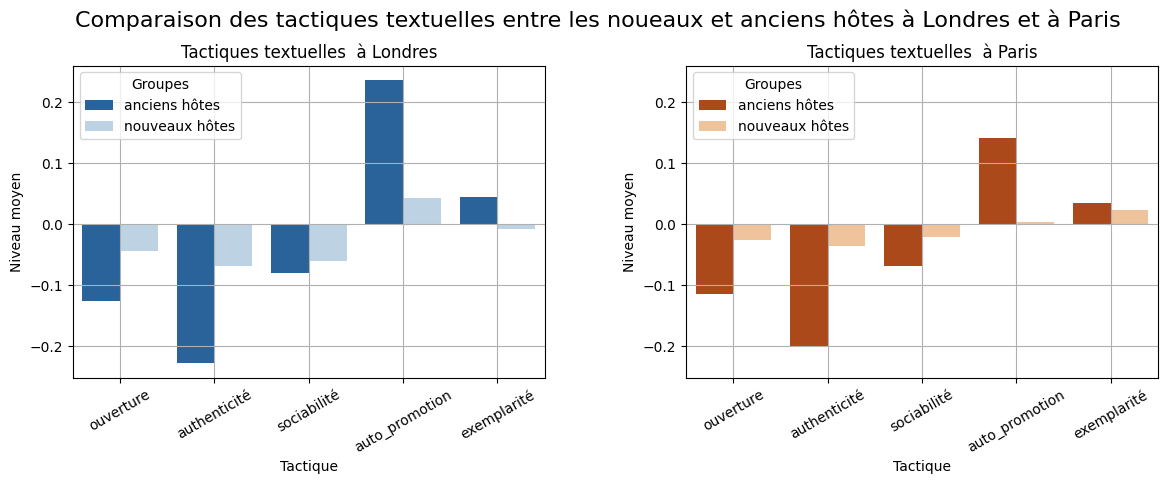

In [229]:

## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(14, 4)) 
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2],sharey=ax1)#**
axes.extend([ax1, ax2])


# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # ==len(hue) 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))


# ---plot---
df_plot=tactcis_new_old_by_city.copy()
tactics=tactics_bio
subplot_col1='in_paris'
list_tactics=[tactics_bio]

# subplot_col2='time'
i=0

for j, tactics in enumerate(list_tactics):
    
    for p in df_plot[subplot_col1].unique():
        print(f"{subplot_col1}={p}, tactics:{tactics}")
        ax=axes[i]
        
        # ---sub data---
        sub=df_plot[(df_plot[subplot_col1]==p)&(df_plot['variable'].isin(tactics))]
        print(len(sub))#==10==5 tactics *2 new/old
        
        if p==1:
            palette=dict(zip(sub['is_new_host'], paris_colors))
        else :
            palette=dict(zip(sub['is_new_host'], london_colors))
    
        sns.barplot(
            data=sub,   
            x='label',
            y="mean",
            hue="is_new_host",
            palette=palette,
            ax=ax,
        )    

        ax.set_xlabel("Tactique")
        ax.set_ylabel("Niveau moyen")
        ax.tick_params(axis="x",rotation=30)
        if j==1:
            ax.set_ylim(0,0.5)
        
        ax.set_title(f"Tactiques {'textuelles' if j==0 else 'visuelles'}  à {'Paris' if p==1 else 'Londres'}")
        
        handles, labels = ax.get_legend_handles_labels()
        new_labels = ["anciens hôtes", "nouveaux hôtes"]
        ax.legend(handles, new_labels, title="Groupes")
        
        ax.grid()
        i+=1
        

## ---legend 2facets----
fig.suptitle(
        # "Effets marginaux des tactiques visuelles entre les groupes",
        "Comparaison des tactiques textuelles entre les noueaux et anciens hôtes à Londres et à Paris",
        fontsize=16,
        y=1.02
    )
plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.1)#控制子图到底的距离，给text留出空间
plt.show()


C:\Users\yeliu\AppData\Local\Temp\ipykernel_34192\708105803.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]


in_paris=0, tactics:['is_portrait', 'is_lifestyle', 'no_person']
6
in_paris=1, tactics:['is_portrait', 'is_lifestyle', 'no_person']
6


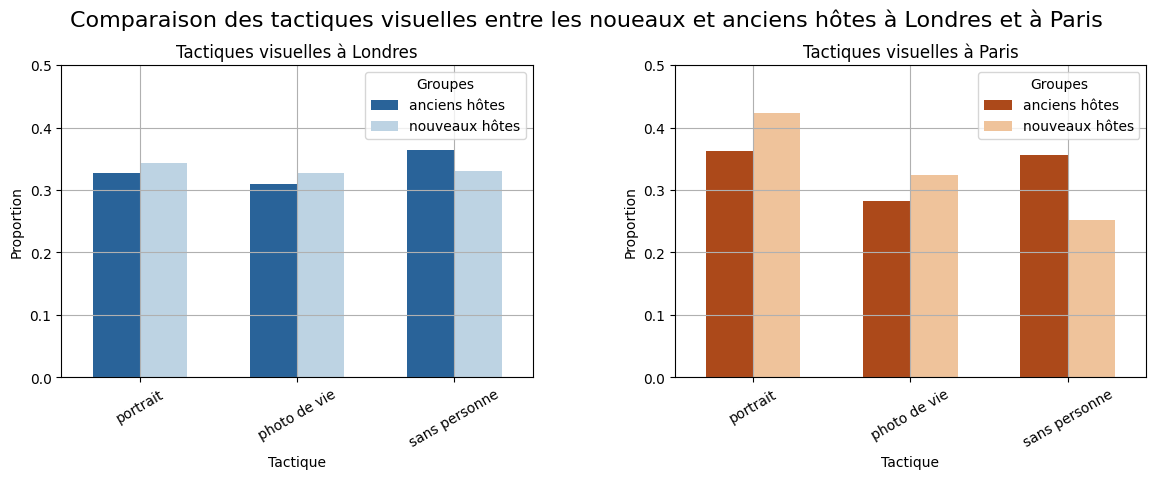

In [230]:

## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(14, 4)) 
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2],sharey=ax1)#**
axes.extend([ax1, ax2])


# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # ==len(hue) 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))


# ---plot---
df_plot=tactcis_new_old_by_city.copy()
tactics=tactics_pic_dummies
subplot_col1='in_paris'
list_tactics=[tactics_pic_dummies]

# subplot_col2='time'
i=0

for j, tactics in enumerate(list_tactics):
    
    for p in df_plot[subplot_col1].unique():
        print(f"{subplot_col1}={p}, tactics:{tactics}")
        ax=axes[i]
        
        # ---sub data---
        sub=df_plot[(df_plot[subplot_col1]==p)&(df_plot['variable'].isin(tactics))]
        print(len(sub))#==10==5 tactics *2 new/old
        
        if p==1:
            palette=dict(zip(sub['is_new_host'], paris_colors))
        else :
            palette=dict(zip(sub['is_new_host'], london_colors))
    
        sns.barplot(
            data=sub,   
            x='label',
            y="mean",
            hue="is_new_host",
            palette=palette,
            ax=ax,
            width=0.6
        )    

        ax.set_xlabel("Tactique")
        ax.set_ylabel("Proportion")
        ax.tick_params(axis="x",rotation=30)
        # if j==1:
        ax.set_ylim(0,0.5)
        
        ax.set_title(f"Tactiques visuelles à {'Paris' if p==1 else 'Londres'}")
        
        handles, labels = ax.get_legend_handles_labels()
        new_labels = ["anciens hôtes", "nouveaux hôtes"]
        ax.legend(handles, new_labels, title="Groupes")
        
        ax.grid()
        i+=1
        

## ---legend 2facets----
fig.suptitle(
        # "Effets marginaux des tactiques visuelles entre les groupes",
        "Comparaison des tactiques visuelles entre les noueaux et anciens hôtes à Londres et à Paris",
        fontsize=16,
        y=1.02
    
    )
plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.1)#控制子图到底的距离，给text留出空间
plt.show()

In [233]:
df=df_all[df_all['time']!="2306"].copy()
agg=df.groupby(['in_paris','is_new_host','time'])[tactics_pic_dummies].mean().reset_index()

agg

,in_paris,is_new_host,time,is_portrait,is_lifestyle,no_person
0,0,0,2312,0.328028,0.307293,0.364679
1,0,0,2406,0.322060,0.294040,0.383900
2,0,1,2312,0.341565,0.339068,0.319367
3,0,1,2406,0.344828,0.315295,0.339878
4,1,0,2312,0.358878,0.279742,0.361380
5,1,0,2406,0.347817,0.271389,0.380794
6,1,1,2312,0.400398,0.329894,0.269708
7,1,1,2406,0.432358,0.322106,0.245536


In [ ]:
sub=agg[agg['in_paris']==1]
for is_new_host in [0,1]:
    

in_paris=0, tactics:['ouverture', 'authenticité', 'sociabilité', 'auto_promotion', 'exemplarité']
10
in_paris=1, tactics:['ouverture', 'authenticité', 'sociabilité', 'auto_promotion', 'exemplarité']
10
in_paris=0, tactics:['is_portrait', 'is_lifestyle', 'no_person']
6
in_paris=1, tactics:['is_portrait', 'is_lifestyle', 'no_person']
6


C:\Users\yeliu\AppData\Local\Temp\ipykernel_1912\2768084668.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]


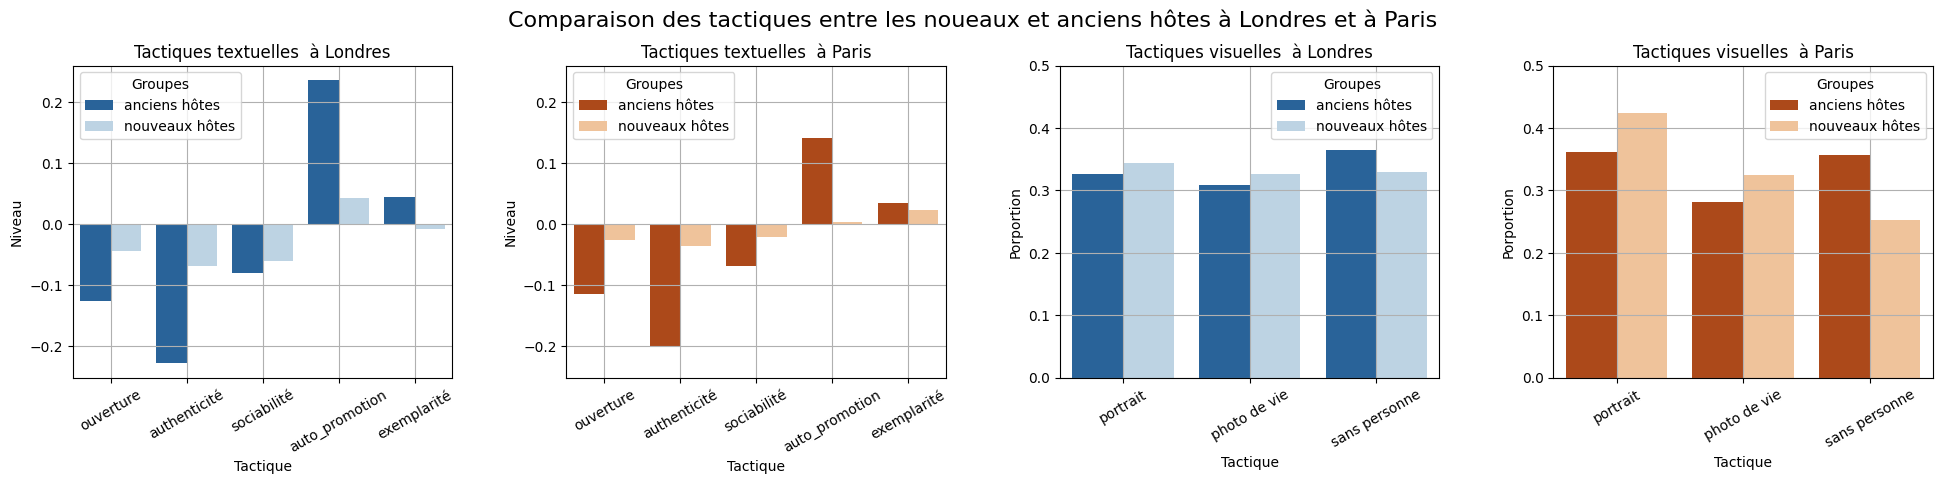

In [ ]:
# XXXXX ALL TIME london + paris NEW vs OLD

import matplotlib.pyplot as plt
importlib.reload(desc_new_old)
from utils.desc_new_old import ttest_new_old

# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # ==len(hue) 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))



## ---layout 4facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(24, 4)) 
gs = gridspec.GridSpec(1, 4, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2], sharey=ax1)#**
# ax3 = fig.add_subplot(gs[0, 2:3], )#**
# ax4 = fig.add_subplot(gs[0, 3:4], sharey=ax3)#**
axes.extend([ax1, ax2, ax3, ax4])

# ---plot---
df_plot=tactcis_new_old_by_city.copy()
tactics=tactics_bio+tactics_pic_dummies
subplot_col1='in_paris'
list_tactics=[tactics_bio, tactics_pic_dummies]

# subplot_col2='time'
i=0

for j, tactics in enumerate(list_tactics):
    for p in df_plot[subplot_col1].unique():
        print(f"{subplot_col1}={p}, tactics:{tactics}")
        ax=axes[i]
        
        # ---sub data---
        sub=df_plot[(df_plot[subplot_col1]==p)&(df_plot['variable'].isin(tactics))]
        print(len(sub))#==10==5 tactics *2 new/old
        
        if p==1:
            palette=dict(zip(sub['is_new_host'], paris_colors))
        else :
            palette=dict(zip(sub['is_new_host'], london_colors))
    
        sns.barplot(
            data=sub,   
            x='label',
            y="mean",
            hue="is_new_host",
            palette=palette,
            ax=ax,
        )    

        ax.set_xlabel("Tactique")
        ax.set_ylabel(f"{'Niveau' if j==0 else 'Porportion'}")
        ax.tick_params(axis="x",rotation=30)
        if j==1:
            ax.set_ylim(0,0.5)
        
        ax.set_title(f"Tactiques {'textuelles' if j==0 else 'visuelles'}  à {'Paris' if p==1 else 'Londres'}")
        
        handles, labels = ax.get_legend_handles_labels()
        new_labels = ["anciens hôtes", "nouveaux hôtes"]
        ax.legend(handles, new_labels, title="Groupes")
        
        ax.grid()
        i+=1
        

## ---legend 2facets----
fig.suptitle(
        # "Effets marginaux des tactiques visuelles entre les groupes",
        "Comparaison des tactiques entre les noueaux et anciens hôtes à Londres et à Paris",
        fontsize=16,
        y=1.02
    )

# plt.figtext(
#     0.5, 0.01,
#     "Significativité de la différence entre des nouveaux et anciens hôtes : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
#     ha="center",
#     fontsize=10,
#     style="italic",   
# )
plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.1)#控制子图到底的距离，给text留出空间
plt.show()


# 横截面差异（cross-sectional difference）
# 在任何一组中，新老房东的表现出不同的策略倾向：新房东ouv, authen, socio水平更高，但在auto, exem水平更低
# ttest属于描述，不解释因果！

# 从2312到2406,这个倾向是否是稳定的？是否发生变化?

### event study of did (new_old)

In [63]:
df=df_all.copy()
var='authenticité'
formula= (f"{var} ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
            "number_of_reviews_ltm + "
            "C(host_is_superhost) +"
            "years_since_host + professional_host + "
            "host_response_rate +  C(host_response_time)+"
            "has_text + lang_en + lang_fr + text_length+"
            "price  + availability_90 + C(room_type) + C(instant_bookable) + "
            "C(time) + in_paris * C(time)*is_new_host"
    )

model_new=smf.ols(formula, data=df).fit(cov_type="HC1")
print(model_new.summary())

                            OLS Regression Results                            
Dep. Variable:           authenticité   R-squared:                       0.171
Model:                            OLS   Adj. R-squared:                  0.170
Method:                 Least Squares   F-statistic:                     1866.
Date:                Tue, 05 May 2026   Prob (F-statistic):               0.00
Time:                        10:09:03   Log-Likelihood:            -2.6370e+05
No. Observations:              266852   AIC:                         5.275e+05
Df Residuals:                  266820   BIC:                         5.278e+05
Df Model:                          31                                         
Covariance Type:                  HC1                                         
                                                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

d:\miniconda3\envs\airbnb_env\lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 33, but rank is 31
  warnings.warn('covariance of constraints does not have full '


In [239]:
def get_event_study_hetero(model, var, times=[2312, 2406], baseline=2306):
    import pandas as pd
    
    results = []

    # --- baseline ---
    for is_new_host in [0,1]:
        results.append({
            "time": baseline,
            "is_new_host": is_new_host,
            "coef": 0,
            "se": 0,
            "ci_low": 0,
            "ci_high": 0,
            "pval": 1,
            "sig": "",
            "variable": var
        })

    # --- loop over time ---
    for t in times:

        # =====================
        # 1. 老房东
        # =====================
        term_old = f"in_paris:C(time)[T.{t}]"
        test_old = model.t_test(term_old)

        coef = float(test_old.effect[0])
        se = float(test_old.sd[0])
        pval = float(test_old.pvalue)

        results.append({
            "time": t,
            "is_new_host":0,
            "coef": coef,
            "se": se,
            "ci_low": coef - 1.96 * se,
            "ci_high": coef + 1.96 * se,
            "pval": pval,
            "sig": p_to_sig(pval),
            "variable": var
        })

        # =====================
        # 2. 新房东（主效应 + 交互）
        # =====================
        term_new = (
            f"in_paris:C(time)[T.{t}] + "
            f"in_paris:C(time)[T.{t}]:is_new_host"
        )

        test_new = model.t_test(term_new)

        coef = float(test_new.effect[0])
        se = float(test_new.sd[0])
        pval = float(test_new.pvalue)

        results.append({
            "time": t,
            "is_new_host":1,
            "coef": coef,
            "se": se,
            "ci_low": coef - 1.96 * se,
            "ci_high": coef + 1.96 * se,
            "pval": pval,
            "sig": p_to_sig(pval),
            "variable": var,
            'label':f"{var_map.get(var,'') if var in var_map.keys() else var}"
        })

    df = pd.DataFrame(results)
    df = df.sort_values(["is_new_host", "time"])

    return df

results=[]
tactics=tactics_bio+tactics_pic_dummies
for var in tactics:
    df=df_all.copy()
    formula= (f"{var} ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
            "number_of_reviews_ltm + "
            "C(host_is_superhost) +"
            "years_since_host + professional_host + "
            "host_response_rate +  C(host_response_time)+"
            "has_text + lang_en + lang_fr + text_length+"
            "price  + availability_90 + C(room_type) + C(instant_bookable) + "
            "C(time) + in_paris * C(time)*is_new_host"
    )

    model_new=smf.ols(formula, data=df).fit(cov_type="HC1")
    # print(model_new.summary())
    
    res=get_event_study_hetero(model_new, var)
    results.append(res)

results_did_evolution_hetero=pd.concat(results, axis=0)
display(results_did_evolution_hetero)


C:\Users\yeliu\AppData\Local\Temp\ipykernel_34192\1321522574.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  se = float(test_old.sd[0])
C:\Users\yeliu\AppData\Local\Temp\ipykernel_34192\1321522574.py:56: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  se = float(test_new.sd[0])
C:\Users\yeliu\AppData\Local\Temp\ipykernel_34192\1321522574.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  se = float(test_old.sd[0])
C:\Users\yeliu\AppData\Local\Temp\ipykernel_34

,time,is_new_host,coef,se,ci_low,ci_high,pval,sig,variable,label
0,2306,0,0.000000,0.000000,0.000000,0.000000,1.000000e+00,,ouverture,NaN
2,2312,0,0.003171,0.007247,-0.011034,0.017375,6.617358e-01,,ouverture,NaN
4,2406,0,0.010097,0.006764,-0.003161,0.023354,1.355193e-01,,ouverture,NaN
1,2306,1,0.000000,0.000000,0.000000,0.000000,1.000000e+00,,ouverture,NaN
3,2312,1,0.021767,0.007520,0.007028,0.036507,3.796100e-03,**,ouverture,ouverture
5,2406,1,-0.026194,0.007186,-0.040278,-0.012109,2.672302e-04,***,ouverture,ouverture
0,2306,0,0.000000,0.000000,0.000000,0.000000,1.000000e+00,,authenticité,NaN
2,2312,0,0.029687,0.007466,0.015054,0.044320,6.994005e-05,***,authenticité,NaN
4,2406,0,0.024809,0.007006,0.011077,0.038542,3.985634e-04,***,authenticité,NaN
1,2306,1,0.000000,0.000000,0.000000,0.000000,1.000000e+00,,authenticité,NaN


In [86]:
# var_map=dict(zip(tactics_pic_dummies,tactics_pic_labels))

# results_did_evolution_hetero['label']=results_did_evolution_hetero['variable'].apply(lambda x : var_map.get(x, "") if x in var_map.keys() else x)
# results_did_evolution_hetero

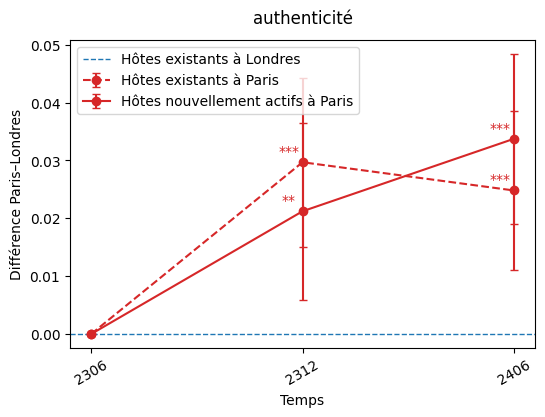

In [240]:
def plot_one_did_hetero(data, axes=None, i=0, var='authenticité', title=None): 
    if axes is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    else:
        ax = axes[i]

    df = data.copy()
    sub = df[df["variable"] == var].copy()
    sub = sub.sort_values(["is_new_host", "time"])
    color = 'tab:red'
    # display(sub)
    
    # x 轴（统一）
    times = sorted(sub["time"].unique())
    x_map = {t:i for i,t in enumerate(times)}

    # --- 两组 ---
    for is_new, linestyle, label in zip(
        [0, 1],
        ['--', '-'],   # 老虚线，新实线
        ['Hôtes existants à Paris', 'Hôtes nouvellement actifs à Paris']
    ):
        d = sub[sub["is_new_host"] == is_new].copy()
        d = d.sort_values("time")

        x = [x_map[t] for t in d["time"]]

        # --- errorbar ---
        ax.errorbar(
            x,
            d["coef"],
            yerr=[
                d["coef"] - d["ci_low"],
                d["ci_high"] - d["coef"]
            ],
            fmt='o',
            linestyle=linestyle,
            capsize=3,
            color=color,
            label=label
        )

        # --- sig ---
        for xi, yi, sig in zip(x, d["coef"], d["sig"]):
            ax.annotate(
                sig,
                xy=(xi, yi),
                xytext=(-10, 5),              # 向上偏移 5 points
                textcoords="offset points",
                ha='center',
                color=color,
                fontsize=10
            )
    
    
    # --- baseline ---
    ax.axhline(0, linestyle="--", color="tab:blue", linewidth=1, label="Hôtes existants à Londres")

    # --- x  ---
    ax.set_xticks(list(x_map.values()))
    ax.set_xticklabels(times)
    ax.tick_params(axis="x", rotation=30)

    # --- labels ---
    ax.set_xlabel("Temps")
    ax.set_ylabel("Différence Paris–Londres")

    # --- title ---
    title = var if title is None else title
    ax.set_title(title, pad=12)

    if axes is None:
        ax.legend()
        
plot_one_did_hetero(results_did_evolution_hetero, var="authenticité")

C:\Users\yeliu\AppData\Local\Temp\ipykernel_34192\2736672287.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.9,1])


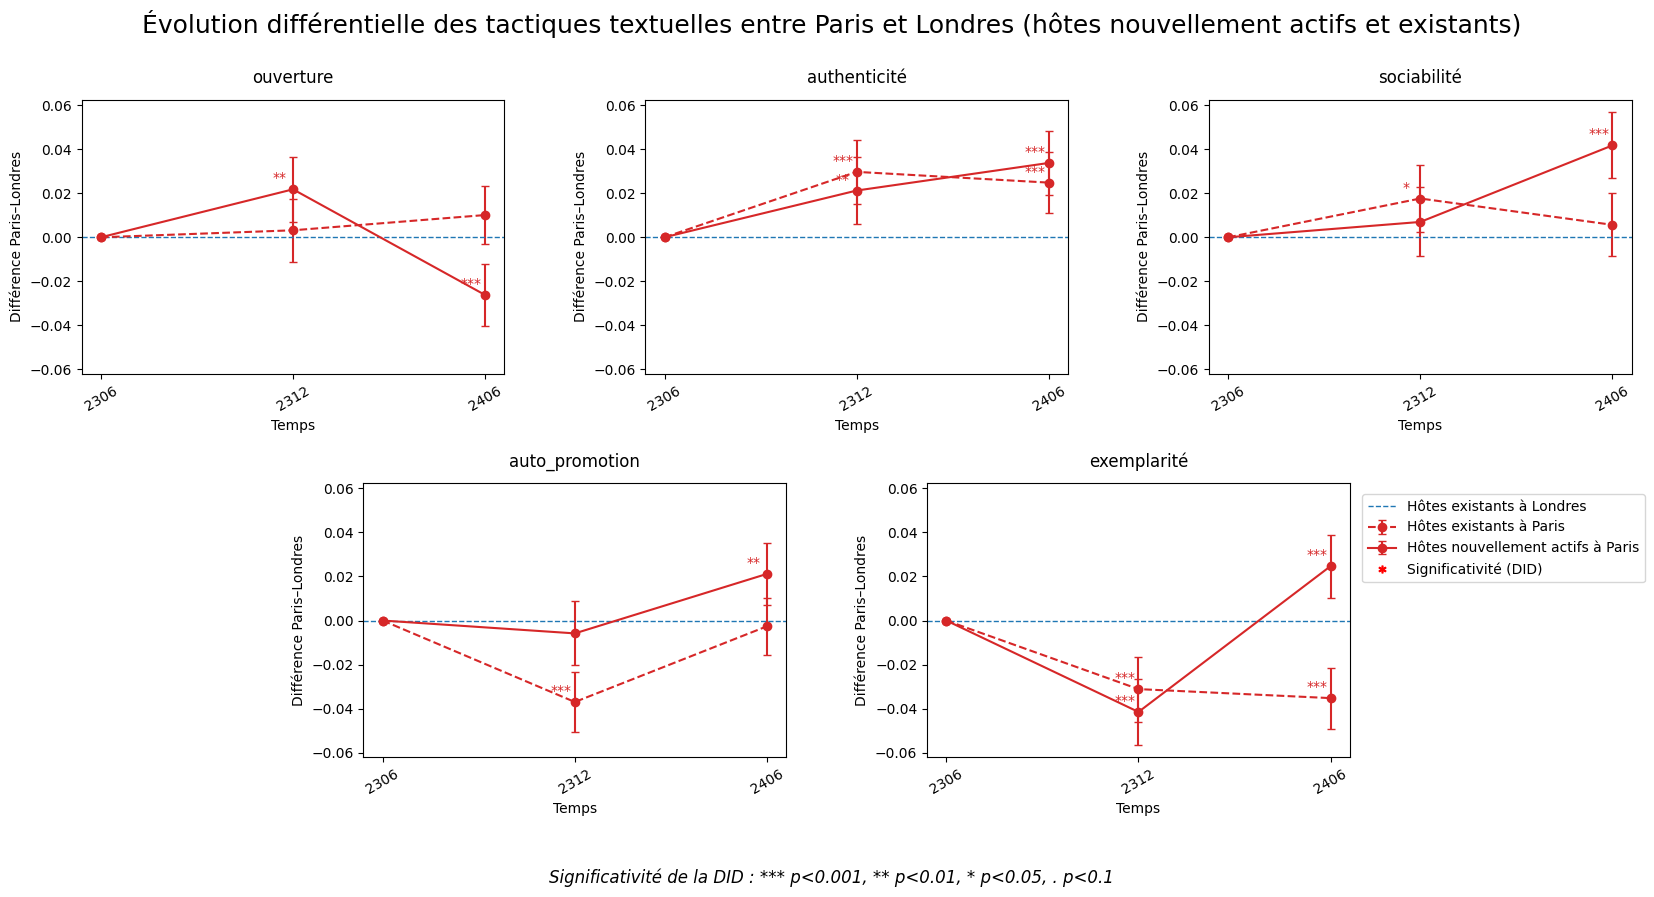

In [245]:
from utils import modeling_did
importlib.reload(modeling_did)
from utils.modeling_did import plot_one_did

# ---layout---
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec

# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))# sharey=True
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4], sharey=ax1)
ax3 = fig.add_subplot(gs[0, 4:6], sharey=ax1)
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3], sharey=ax1)
ax5 = fig.add_subplot(gs[1, 3:5], sharey=ax1)
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
# n_to_plot = min(len(tactics), len(axes))


tactics=tactics_bio
df_plot=results_did_evolution_hetero.copy()#[results_did_evolution['variable'].isin(tactics)].copy()

for i, var in enumerate(tactics):
    plot_one_did_hetero(data=df_plot, axes=axes, i=i, var=var, title=None)
    
# --------------------legend------------------------
fig.suptitle(
        "Évolution différentielle des tactiques textuelles entre Paris et Londres (hôtes nouvellement actifs et existants)",
        fontsize=18,
        y=0.98 #大标题到子图的距离, 越大越远
    )

from matplotlib.lines import Line2D
handles, labels = axes[0].get_legend_handles_labels()
# --- add custom legend :sig note ---
handles.append(
    Line2D([0], [0], marker='$*$', linestyle='None', color='red', markersize=5,
           label='Significativité (DID)')
)
labels = labels + [
    "Significativité (DID)"
]

fig.legend(
    handles,
    labels,
    fontsize=10,
    loc="upper right",
    bbox_to_anchor=(0.91,0.45) # legend (x, y)，x>1则在图外, y=0在底线
)

plt.figtext(
    0.5, 0.01,
    "Significativité de la DID : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic"   
)

plt.tight_layout(rect=[0, 0.1, 0.9,1])
plt.subplots_adjust(bottom=0.15)#控制子图到底的距离，给text留出空间
plt.show()

C:\Users\yeliu\AppData\Local\Temp\ipykernel_34192\2178167932.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.8,1])


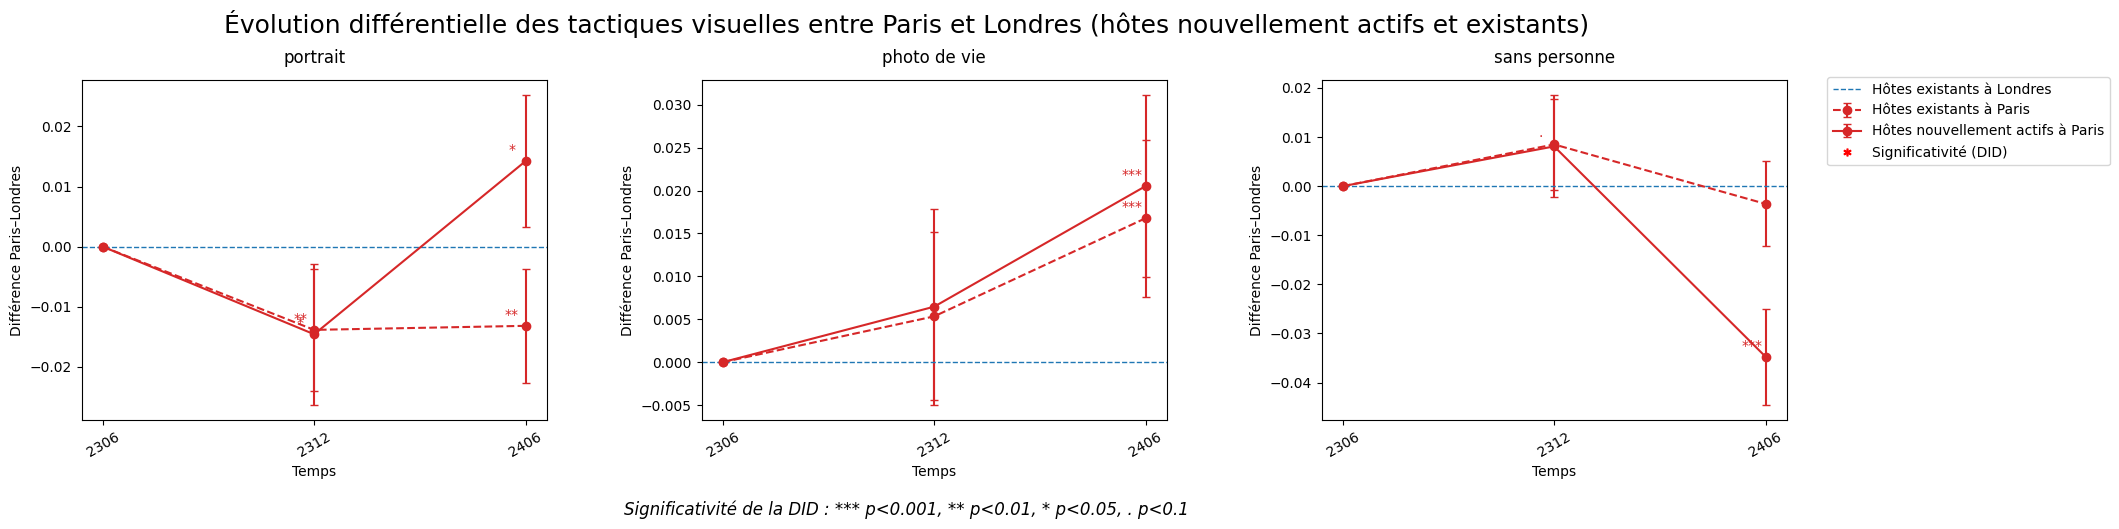

In [249]:
# ---layout---
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(22,5))# sharey=True
gs = gridspec.GridSpec(1, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])


## plot

tactics=tactics_pic_dummies
tactics_pic_labels=['portrait','photo de vie','sans personne']
var_map=dict(zip(tactics_pic_dummies,tactics_pic_labels))

df_plot=results_did_evolution_hetero.copy()

for i, var in enumerate(tactics):
    plot_one_did_hetero(data=df_plot, axes=axes, i=i, var=var, title=var_map.get(var))
    
# layout 3facets:
fig.suptitle(
        "Évolution différentielle des tactiques visuelles entre Paris et Londres (hôtes nouvellement actifs et existants)",
        fontsize=18,
        y=1.02
    )

# --------------------legend------------------------
from matplotlib.lines import Line2D
handles, labels = axes[0].get_legend_handles_labels()
# --- add custom legend :sig note ---
handles.append(
    Line2D([0], [0], marker='$*$', linestyle='None', color='red', markersize=5,
           label='Significativité (DID)')
)
labels = labels + [
    "Significativité (DID)"
]

fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(1.05,0.9) # legend (x, y)，x>1则在图外, y=0在底线
)
plt.figtext(
    0.5, 0.01,
    "Significativité de la DID : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic"   
)

plt.tight_layout(rect=[0, 0.1, 0.8,1])
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()

In [88]:
## variation de DID: V2

def p_to_sig(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    elif p < 0.1: return '.'
    else: return ''


specs=[
    # constants: time=2312-2406, in_paris: paris-london, 
    # is_new_host, terms 
    (1, """
        in_paris:C(time)[T.2406] + in_paris:C(time)[T.2406]:is_new_host 
        - in_paris:C(time)[T.2312] - in_paris:C(time)[T.2312]:is_new_host
        """), 
    # - C(time)[T.2406]:is_new_host
    # + C(time)[T.2312]:is_new_host
        
    (0, """
        in_paris:C(time)[T.2406]
        - in_paris:C(time)[T.2312]
        """) 
#       - C(time)[T.2406]
#         + C(time)[T.2312]
]

df=df_all.copy()
results=[]

for var in tactics_bio+tactics_pic_dummies:
    print(var)
    formula= (f"{var} ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
            "number_of_reviews_ltm + "
            "C(host_is_superhost) +"
            "years_since_host + professional_host + "
            "host_response_rate +  C(host_response_time)+"
            "has_text + lang_en + lang_fr + text_length+"
            "price  + availability_90 + C(room_type) + C(instant_bookable) + "
            "C(time) + in_paris * C(time)*is_new_host"
    )
    model_new=smf.ols(formula, data=df).fit()

    for i, (new, term) in enumerate(specs):
        test = model_new.t_test(term)
        sig=p_to_sig(test.pvalue)
        res= pd.DataFrame({
            'variable':var,
            "is_new_host":new,
            "coef": test.effect[0],
            "se": test.sd[0],
            "pval": test.pvalue,
            "sig":sig,
            "ci_low": test.conf_int()[0][0],
            "ci_high": test.conf_int()[0][1],
            'label':f"{var_map.get(var,'') if var in var_map.keys() else var}"
        })
        results.append(res)
    # break

results_ddd_new=pd.concat(results, axis=0)
display(results_ddd_new)  


ouverture
authenticité
sociabilité
auto_promotion
exemplarité
is_portrait
is_lifestyle
no_person


,variable,is_new_host,coef,se,pval,sig,ci_low,ci_high,label
0,ouverture,1,-0.047961,0.010951,1.188402e-05,***,-0.069424,-0.026498,ouverture
0,ouverture,0,0.006926,0.007089,3.285956e-01,,-0.006969,0.020821,ouverture
0,authenticité,1,0.012520,0.011337,2.694378e-01,,-0.009700,0.034741,authenticité
0,authenticité,0,-0.004878,0.007340,5.063110e-01,,-0.019263,0.009508,authenticité
0,sociabilité,1,0.034737,0.011724,3.048703e-03,**,0.011758,0.057716,sociabilité
0,sociabilité,0,-0.011947,0.007590,1.154902e-01,,-0.026824,0.002930,sociabilité
0,auto_promotion,1,0.026999,0.010687,1.152112e-02,*,0.006054,0.047945,auto_promotion
0,auto_promotion,0,0.034360,0.006918,6.820463e-07,***,0.020800,0.047920,auto_promotion
0,exemplarité,1,0.066196,0.011356,5.579358e-09,***,0.043938,0.088454,exemplarité
0,exemplarité,0,-0.004086,0.007352,5.783685e-01,,-0.018495,0.010324,exemplarité


is_new_host=1
is_new_host=0


C:\Users\yeliu\AppData\Local\Temp\ipykernel_34192\3829420988.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]


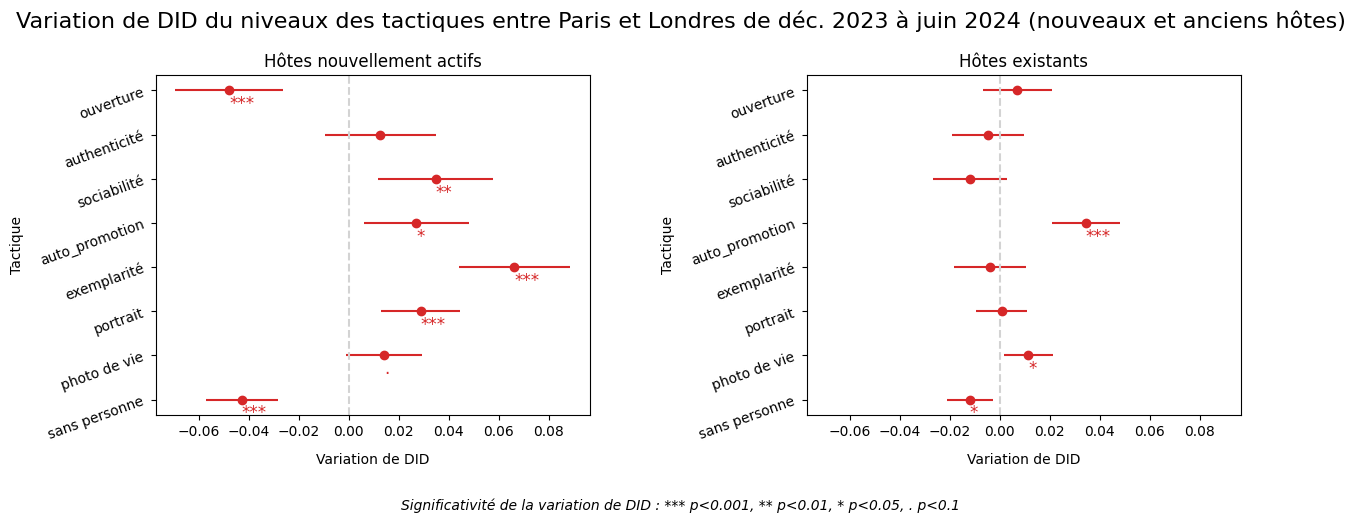

In [236]:
## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(14, 5)) 
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.5)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2], sharex=ax1)#**
axes.extend([ax1, ax2])



change_colors='tab:red'
#
tactics=tactics_bio+tactics_pic_dummies

df_plot=results_ddd_new[results_ddd_new['variable'].isin(tactics)].copy()#***

subplot_col="is_new_host"

for i, new in enumerate(df_plot[subplot_col].unique()):
    print(f"{subplot_col}={new}")
    
    sub=df_plot[df_plot[subplot_col]==new].copy()
    order=tactics[::-1]
    sub = sub.set_index("variable").loc[order].reset_index()
    # display(sub)

    ax=axes[i]
    ax.errorbar(
        x=sub["coef"],
        y=sub["label"],
        # y=y,
        xerr=[sub["coef"] - sub["ci_low"], sub["ci_high"] - sub["coef"]],
        fmt='o', 
        color=change_colors,
        # linestyle='-' if new==1 else '--'
    )
    # ---sig---
    for _, row in sub.iterrows():
        ax.annotate(
            row["sig"],
            xy=(row["coef"], row["label"]),
            xytext=(0, -10),         
            textcoords='offset points',
            ha='left',
            va='center',
            fontsize=12,
            color=change_colors
    )    
            
    ax.axvline(0, linestyle='--', color="lightgray", label="Variation de Londres")    
    ax.set_xlabel(f"Variation de DID", labelpad=10)
    ax.set_ylabel('Tactique', labelpad=10)
    ax.tick_params(axis='y', rotation=20)
    ax.set_title(f"{'Hôtes nouvellement actifs' if new==1 else 'Hôtes existants'}")
    
    

## ---legend 2facets----
fig.suptitle(
    "Variation de DID du niveaux des tactiques entre Paris et Londres de déc. 2023 à juin 2024 (nouveaux et anciens hôtes)", 
    fontsize=16,
    y=1.01
)

plt.figtext(
    0.5, 0.01,
    "Significativité de la variation de DID : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=10,
    style="italic",   
)
plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()

In [83]:
# 每个时期地点类型房东的平均值
importlib.reload(desc_new_old)
from utils.desc_new_old import ttest_by_time

df_plot_time=ttest_by_time(df=df_all, 
                           times=["2312","2406"], in_paris=[0, 1], is_new_host=[0, 1], 
                           vars=tactics_bio+tactics_pic_dummies)
df_plot_time

(266852, 131) => (191595, 131)
is_new_host  time  in_paris
0            2406  0           37937
                   1           34176
             2312  0           32360
1            2406  1           28562
0            2312  1           24780
1            2406  0           11919
             2312  1           11049
                   0           10812
Name: count, dtype: int64


,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label,change
0,2312,0,ouverture,-2.769081,0.005626,**,1,-0.054907,ouverture,+
0,2406,0,ouverture,-2.769081,0.005626,**,1,-0.032854,ouverture,+
0,2312,0,authenticité,0.048290,0.961486,,1,-0.068509,authenticité,-
0,2406,0,authenticité,0.048290,0.961486,,1,-0.068915,authenticité,-
0,2312,0,sociabilité,0.249636,0.802871,,1,-0.058570,sociabilité,-
...,...,...,...,...,...,...,...,...,...,...
0,2406,1,is_portrait,2.771907,0.005575,**,0,0.347817,portrait,-
0,2312,1,is_lifestyle,2.238904,0.025166,*,0,0.279742,photo de vie,-
0,2406,1,is_lifestyle,2.238904,0.025166,*,0,0.271389,photo de vie,-
0,2312,1,no_person,-4.821333,0.000001,***,0,0.361380,sans personne,+


In [84]:
for var in tactics_bio:
    sub=df_plot_time[df_plot_time['variable']==var]
    sub=sub.sort_values(["is_new_host",'in_paris'])
    display(sub)
    

,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label,change
0,2312,0,ouverture,1.546633,1.219565e-01,,0,-0.130710,ouverture,-
0,2406,0,ouverture,1.546633,1.219565e-01,,0,-0.138921,ouverture,-
0,2312,1,ouverture,2.581436,9.841665e-03,**,0,-0.119163,ouverture,-
0,2406,1,ouverture,2.581436,9.841665e-03,**,0,-0.133475,ouverture,-
0,2312,0,ouverture,-2.769081,5.626104e-03,**,1,-0.054907,ouverture,+
0,2406,0,ouverture,-2.769081,5.626104e-03,**,1,-0.032854,ouverture,+
0,2312,1,ouverture,5.533963,3.166305e-08,***,1,-0.002521,ouverture,-
0,2406,1,ouverture,5.533963,3.166305e-08,***,1,-0.034036,ouverture,-


,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label,change
0,2312,0,authenticité,2.014196,4.399288e-02,*,0,-0.250389,authenticité,-
0,2406,0,authenticité,2.014196,4.399288e-02,*,0,-0.262354,authenticité,-
0,2312,1,authenticité,6.567619,5.158853e-11,***,0,-0.201088,authenticité,-
0,2406,1,authenticité,6.567619,5.158853e-11,***,0,-0.240384,authenticité,-
0,2312,0,authenticité,0.048290,9.614855e-01,,1,-0.068509,authenticité,-
0,2406,0,authenticité,0.048290,9.614855e-01,,1,-0.068915,authenticité,-
0,2312,1,authenticité,-4.029937,5.599858e-05,***,1,-0.054085,authenticité,+
0,2406,1,authenticité,-4.029937,5.599858e-05,***,1,-0.029554,authenticité,+


,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label,change
0,2312,0,sociabilité,1.190574,2.338250e-01,,0,-0.090225,sociabilité,-
0,2406,0,sociabilité,1.190574,2.338250e-01,,0,-0.096956,sociabilité,-
0,2312,1,sociabilité,5.547168,2.917046e-08,***,0,-0.064347,sociabilité,-
0,2406,1,sociabilité,5.547168,2.917046e-08,***,0,-0.096182,sociabilité,-
0,2312,0,sociabilité,0.249636,8.028712e-01,,1,-0.058570,sociabilité,-
0,2406,0,sociabilité,0.249636,8.028712e-01,,1,-0.060629,sociabilité,-
0,2312,1,sociabilité,-2.129152,3.325350e-02,*,1,-0.030222,sociabilité,+
0,2406,1,sociabilité,-2.129152,3.325350e-02,*,1,-0.017548,sociabilité,+


,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label,change
0,2312,0,auto_promotion,-0.551195,5.815017e-01,,0,0.264328,auto_promotion,+
0,2406,0,auto_promotion,-0.551195,5.815017e-01,,0,0.267661,auto_promotion,+
0,2312,1,auto_promotion,-9.075568,1.168055e-19,***,0,0.134466,auto_promotion,+
0,2406,1,auto_promotion,-9.075568,1.168055e-19,***,0,0.186465,auto_promotion,+
0,2312,0,auto_promotion,-1.081306,2.795725e-01,,1,0.038115,auto_promotion,+
0,2406,0,auto_promotion,-1.081306,2.795725e-01,,1,0.047285,auto_promotion,+
0,2312,1,auto_promotion,-0.241920,8.088449e-01,,1,0.002145,auto_promotion,+
0,2406,1,auto_promotion,-0.241920,8.088449e-01,,1,0.003604,auto_promotion,+


,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label,change
0,2312,0,exemplarité,-0.728644,4.662220e-01,,0,0.050942,exemplarité,+
0,2406,0,exemplarité,-0.728644,4.662220e-01,,0,0.054928,exemplarité,+
0,2312,1,exemplarité,0.804076,4.213569e-01,,0,0.032999,exemplarité,-
0,2406,1,exemplarité,0.804076,4.213569e-01,,0,0.028441,exemplarité,-
0,2312,0,exemplarité,1.834206,6.663659e-02,.,1,-0.001066,exemplarité,-
0,2406,0,exemplarité,1.834206,6.663659e-02,.,1,-0.015097,exemplarité,-
0,2312,1,exemplarité,-4.898418,9.723848e-07,***,1,0.001056,exemplarité,+
0,2406,1,exemplarité,-4.898418,9.723848e-07,***,1,0.031944,exemplarité,+


In [85]:
for var in tactics_pic_dummies:
    sub=df_plot_time[df_plot_time['variable']==var]
    sub=sub.sort_values(["is_new_host",'in_paris'])
    display(sub)
    

,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label,change
0,2312,0,is_portrait,1.683528,9.227747e-02,.,0,0.328028,portrait,-
0,2406,0,is_portrait,1.683528,9.227747e-02,.,0,0.322060,portrait,-
0,2312,1,is_portrait,2.771907,5.574826e-03,**,0,0.358878,portrait,-
0,2406,1,is_portrait,2.771907,5.574826e-03,**,0,0.347817,portrait,-
0,2312,0,is_portrait,-0.517432,6.048595e-01,,1,0.341565,portrait,+
0,2406,0,is_portrait,-0.517432,6.048595e-01,,1,0.344828,portrait,+
0,2312,1,is_portrait,-5.803755,6.581182e-09,***,1,0.400398,portrait,+
0,2406,1,is_portrait,-5.803755,6.581182e-09,***,1,0.432358,portrait,+


,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label,change
0,2312,0,is_lifestyle,3.817809,0.000135,***,0,0.307293,photo de vie,-
0,2406,0,is_lifestyle,3.817809,0.000135,***,0,0.294040,photo de vie,-
0,2312,1,is_lifestyle,2.238904,0.025166,*,0,0.279742,photo de vie,-
0,2406,1,is_lifestyle,2.238904,0.025166,*,0,0.271389,photo de vie,-
0,2312,0,is_lifestyle,3.814375,0.000137,***,1,0.339068,photo de vie,-
0,2406,0,is_lifestyle,3.814375,0.000137,***,1,0.315295,photo de vie,-
0,2312,1,is_lifestyle,1.480921,0.138643,,1,0.329894,photo de vie,-
0,2406,1,is_lifestyle,1.480921,0.138643,,1,0.322106,photo de vie,-


,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label,change
0,2312,0,no_person,-5.251826,1.510455e-07,***,0,0.364679,sans personne,+
0,2406,0,no_person,-5.251826,1.510455e-07,***,0,0.383900,sans personne,+
0,2312,1,no_person,-4.821333,1.429914e-06,***,0,0.361380,sans personne,+
0,2406,1,no_person,-4.821333,1.429914e-06,***,0,0.380794,sans personne,+
0,2312,0,no_person,-3.287121,1.013719e-03,**,1,0.319367,sans personne,+
0,2406,0,no_person,-3.287121,1.013719e-03,**,1,0.339878,sans personne,+
0,2312,1,no_person,4.902031,9.561104e-07,***,1,0.269708,sans personne,-
0,2406,1,no_person,4.902031,9.561104e-07,***,1,0.245536,sans personne,-


In [109]:
results_ddd_new

,variable,is_new_host,coef,se,pval,sig,ci_low,ci_high,label
0,ouverture,1,-0.047961,0.010951,1.188402e-05,***,-0.069424,-0.026498,ouverture
0,ouverture,0,0.006926,0.007089,3.285956e-01,,-0.006969,0.020821,ouverture
0,authenticité,1,0.012520,0.011337,2.694378e-01,,-0.009700,0.034741,authenticité
0,authenticité,0,-0.004878,0.007340,5.063110e-01,,-0.019263,0.009508,authenticité
0,sociabilité,1,0.034737,0.011724,3.048703e-03,**,0.011758,0.057716,sociabilité
0,sociabilité,0,-0.011947,0.007590,1.154902e-01,,-0.026824,0.002930,sociabilité
0,auto_promotion,1,0.026999,0.010687,1.152112e-02,*,0.006054,0.047945,auto_promotion
0,auto_promotion,0,0.034360,0.006918,6.820463e-07,***,0.020800,0.047920,auto_promotion
0,exemplarité,1,0.066196,0.011356,5.579358e-09,***,0.043938,0.088454,exemplarité
0,exemplarité,0,-0.004086,0.007352,5.783685e-01,,-0.018495,0.010324,exemplarité


0 ouverture
label=ouverture, is_new_host=1
label=ouverture, is_new_host=0
1 authenticité
label=authenticité, is_new_host=1
label=authenticité, is_new_host=0
2 sociabilité
label=sociabilité, is_new_host=1
label=sociabilité, is_new_host=0
3 auto_promotion
label=auto_promotion, is_new_host=1
label=auto_promotion, is_new_host=0
4 exemplarité
label=exemplarité, is_new_host=1
label=exemplarité, is_new_host=0


C:\Users\yeliu\AppData\Local\Temp\ipykernel_34192\220391074.py:157: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.9, 1])# [left, bottom, right, top]


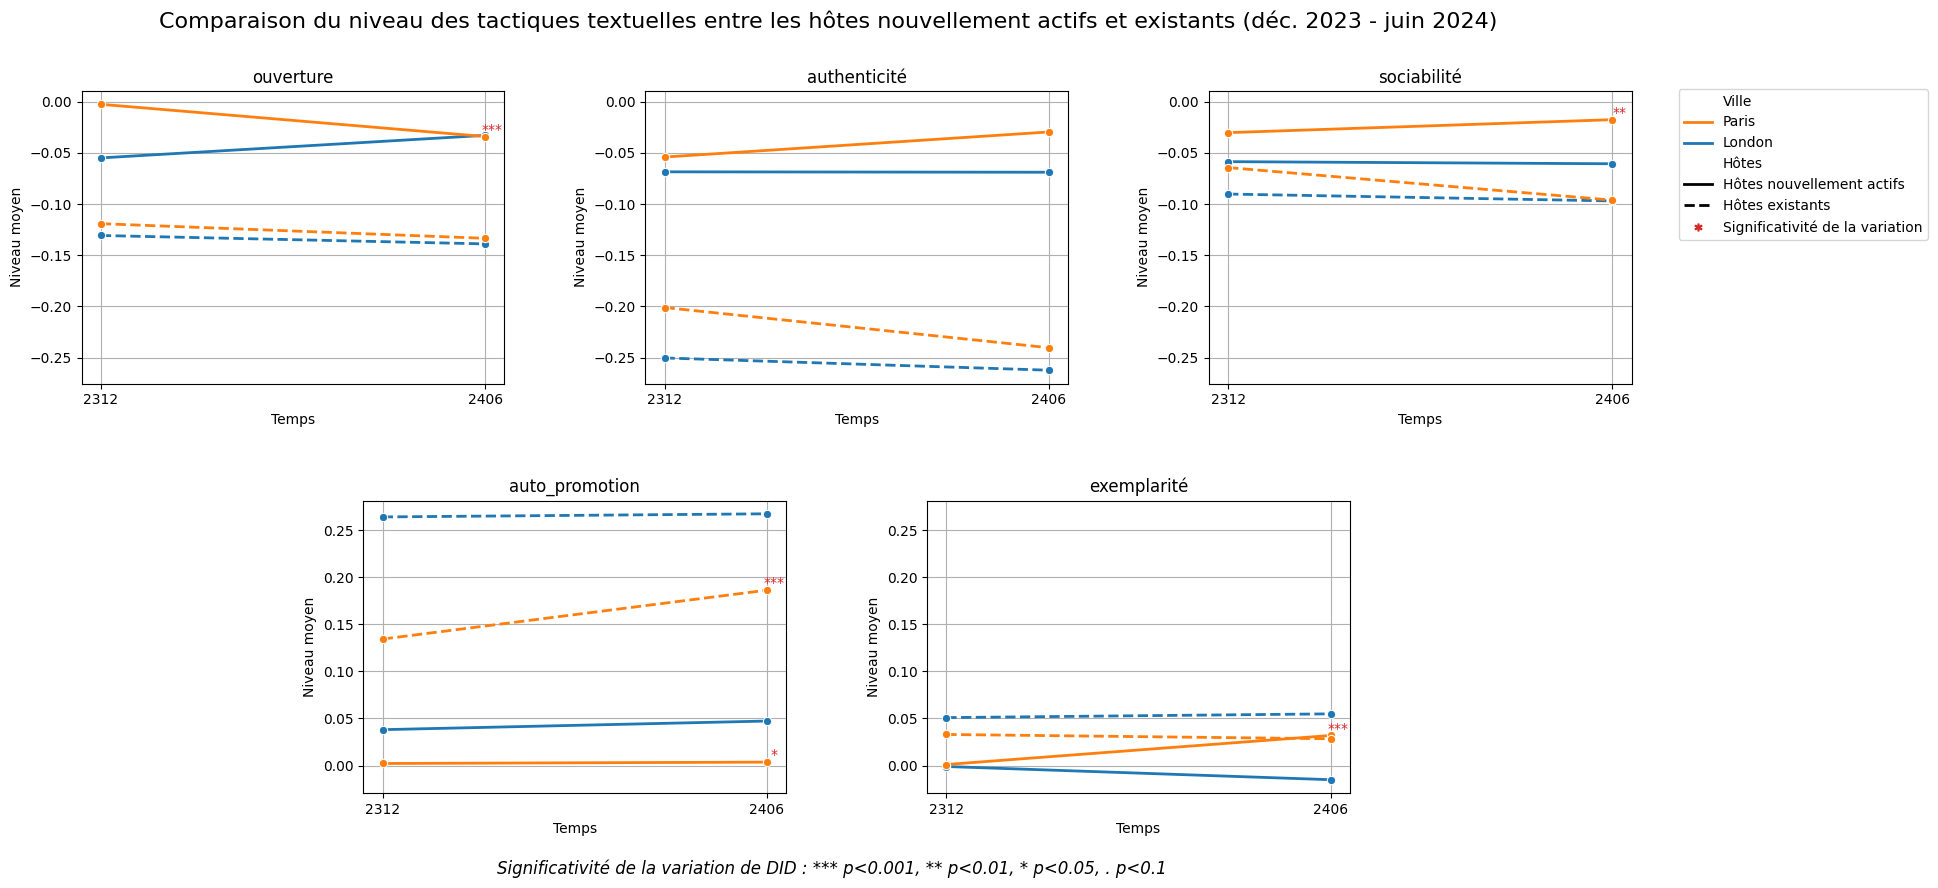

In [251]:
## new old hue:london/paris y=tactics_sig
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 1 # ==len(hue) 每组柱子的数量
# london_colors = blue_cmap(np.linspace(0.7, 0.8, n))
# paris_colors  = orange_cmap(np.linspace(0.7, 0.8, n))

london_colors="tab:blue"
paris_colors='tab:orange'
# paris:paris color
palette={
    0:london_colors,
    1:paris_colors
}

# -------------------layout 5 facets-------------------
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# # 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4], sharey=ax1)
ax3 = fig.add_subplot(gs[0, 4:6], sharey=ax1)
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5], sharey=ax4)
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics_bio), len(axes))


# 每一个tac一个图，一个图中新老pl四条线, 新房东浅色，london蓝色，
# 每个 var 一张图
# x = time
# 线 = Paris vs London
# hue = new/old


subplot_col1='label'
subplot_col2='is_new_host'
# subplot_col3='is_new_host'
tactics=tactics_bio
df_plot=df_plot_time.copy()

# ---plt---
i=0
for var in tactics:
    ax=axes[i]
    print(i, var)    
    for new in df_plot[subplot_col2].unique():#*** 
       
        # ---sub data---
        print(f"{subplot_col1}={var}, {subplot_col2}={new}")#***        
        sub = df_plot[
            (df_plot[subplot_col1] == var) &
            (df_plot[subplot_col2] == new) 
        ].copy()
        # display(sub)
        # new/old
    
        sns.lineplot(
            data=sub,
            x="time",
            y="mean",
            hue="in_paris",
            palette=palette,
            marker="o",
            linestyle='-' if new==1 else '--',
            linewidth= 2,# if new==1 else 1.5,
            ax=ax,
            legend=False
        )
        
        # ---sig--- 
        sub_ddd=results_ddd_new[(results_ddd_new['label']==var)&(results_ddd_new['is_new_host']==new)]['sig'].iloc[0]
        for _, row in sub[(sub['in_paris']==1)&(sub['time']=="2406")].iterrows():
            # print(row)
            ax.annotate(sub_ddd,
                        xy=(row['time'], row['mean']),
                        xytext=(5,5),
                        textcoords='offset points',
                        ha='center',
                        va='center',
                        fontsize=10,
                        color='tab:red'
                        )
        
        
    #     break
    # break      
    ax.grid()
    ax.set_xlabel("Temps")
    ax.set_ylabel("Niveau moyen")
    ax.set_title(f"{var}")
    i+=1
    # break        
            
    
## ---legend 2facets----
fig.suptitle(
        f"Comparaison du niveau des tactiques textuelles entre les hôtes nouvellement actifs et existants (déc. 2023 - juin 2024) ",
        fontsize=16,
        y=0.97
    )
# ---custom legen---
legend_elements = []
    # ---标题：城市---
legend_elements.append(Line2D([], [], linestyle="none", label="Ville"))

legend_elements.append(
    Line2D([0], [0], color=paris_colors, lw=2, linestyle="-", label="Paris")
)
legend_elements.append(
    Line2D([0], [0], color=london_colors, lw=2, linestyle="-", label="London")
)

# ---标题：新老房东---
legend_elements.append(Line2D([], [], linestyle="none", label="Hôtes"))

legend_elements.append(
    Line2D([0], [0], color="black", lw=2, linestyle="-", label="Hôtes nouvellement actifs")
)
legend_elements.append(
    Line2D([0], [0], color="black", lw=2, linestyle="--", label="Hôtes existants")
)

# --- sig note ---
legend_elements.append(
    Line2D([0], [0], marker='$*$', linestyle='None', color='tab:red',markersize=5,
           label='Significativité de la variation')
)

fig.legend(
        handles=legend_elements,
        loc="upper left",
        bbox_to_anchor=(0.92, 0.89),
        frameon=True
    )

plt.figtext(
    0.5, 0.01,
    "Significativité de la variation de DID : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic",   
)

plt.tight_layout(rect=[0, 0.1, 0.9, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.1)#控制子图到底的距离，给text留出空间

plt.show()

0
label=portrait, is_new_host=1
label=portrait, is_new_host=0
1
label=photo de vie, is_new_host=1
label=photo de vie, is_new_host=0
2
label=sans personne, is_new_host=1
label=sans personne, is_new_host=0


C:\Users\yeliu\AppData\Local\Temp\ipykernel_34192\1628828845.py:140: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.9, 1])# [left, bottom, right, top]


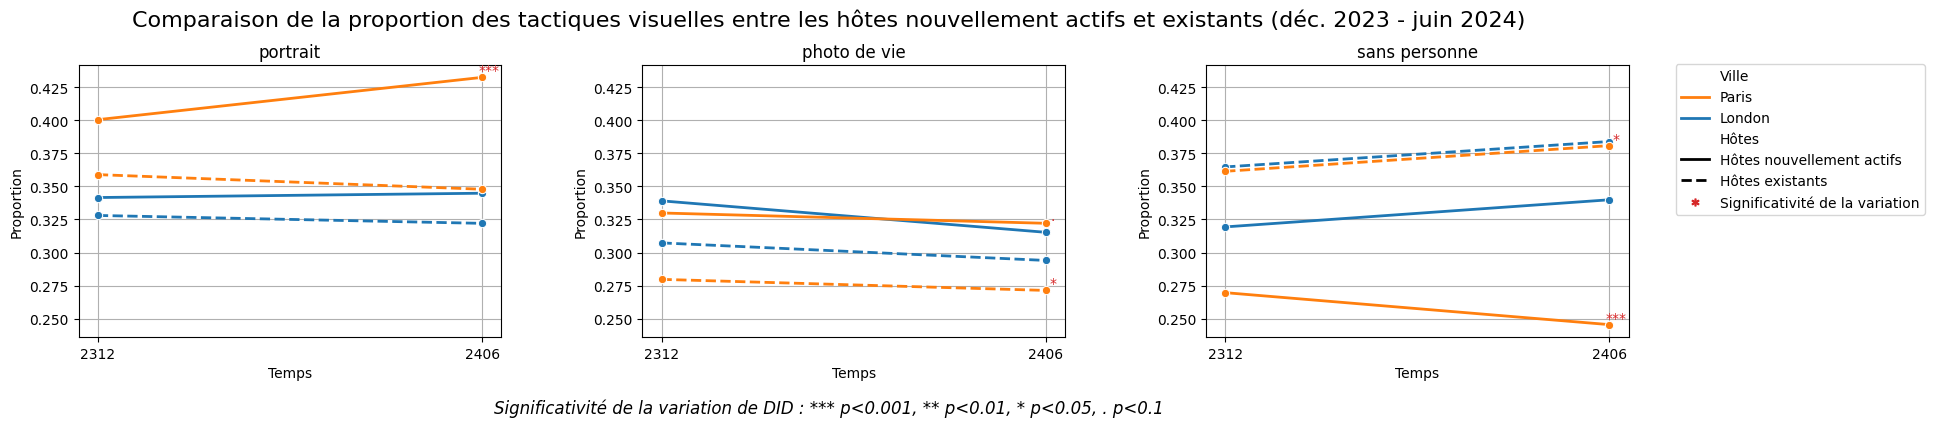

In [252]:

## new old hue:london/paris y=tactics_sig
import matplotlib.gridspec as gridspec

df_plot=df_plot_time.copy()

# paris:paris color
palette={
    0:'tab:blue',
    1:'tab:orange'
}

# -------------------layout 5 facets-------------------
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,4))
gs = gridspec.GridSpec(1, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# # 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4], sharey=ax1)
ax3 = fig.add_subplot(gs[0, 4:6], sharey=ax1)
axes.extend([ax1, ax2, ax3])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics), len(axes))




subplot_col1='label'
subplot_col2='is_new_host'
tactics=tactics_pic_labels
i=0
for var in tactics:
    ax=axes[i]
    print(i)    
    for new in df_plot[subplot_col2].unique():#*** 
       
                    
        # ---sub data---
        print(f"{subplot_col1}={var}, {subplot_col2}={new}")#***        
        sub = df_plot[
            (df_plot[subplot_col1] == var) &
            (df_plot[subplot_col2] == new) 
        ].copy()
        # display(sub)
        # new/old
    
        sns.lineplot(
            data=sub,
            x="time",
            y="mean",
            hue="in_paris",
            palette=palette,
            marker="o",
            linestyle='-' if new==1 else '--',
            linewidth= 2, # if new==1 else 1.5,
            ax=ax,
            legend=False
        )
        # ---sig--- 
        sub_ddd=results_ddd_new[(results_ddd_new['label']==var)&(results_ddd_new['is_new_host']==new)]['sig'].iloc[0]
        for _, row in sub[(sub['in_paris']==1)&(sub['time']=="2406")].iterrows():
            # print(row)
            ax.annotate(sub_ddd,
                        xy=(row['time'], row['mean']),
                        xytext=(5,5),
                        textcoords='offset points',
                        ha='center',
                        va='center',
                        fontsize=10,
                        color='tab:red'
                        )
        
        # break
        
    ax.grid()
    ax.set_xlabel("Temps")
    ax.set_ylabel("Proportion")
    # var_map={
    #     'is_portrait':"portrait",
    #     "is_lifestyle":'photo de vie',
    #     "no_person":'sans personne'
    # }
    ax.set_title(f"{var}")
    i+=1
    # break        
            
    
## ---legend 2facets----
fig.suptitle(
        f"Comparaison de la proportion des tactiques visuelles entre les hôtes nouvellement actifs et existants (déc. 2023 - juin 2024)",
        fontsize=16,
        y=1.02
    )

# ---custom legend---
legend_elements = []
    # ---标题：城市---
legend_elements.append(Line2D([], [], linestyle="none", label="Ville"))

legend_elements.append(
    Line2D([0], [0], color=paris_colors, lw=2, linestyle="-", label="Paris")
)
legend_elements.append(
    Line2D([0], [0], color=london_colors, lw=2, linestyle="-", label="London")
)

# ---标题：新老房东---
legend_elements.append(Line2D([], [], linestyle="none", label="Hôtes"))

legend_elements.append(
    Line2D([0], [0], color="black", lw=2, linestyle="-", label="Hôtes nouvellement actifs")
)
legend_elements.append(
    Line2D([0], [0], color="black", lw=2, linestyle="--", label="Hôtes existants")
)
# --- sig note ---
legend_elements.append(
    Line2D([0], [0], marker='$*$',markersize=5,   

           linestyle='None', color='tab:red',
           label='Significativité de la variation')
)

fig.legend(
        handles=legend_elements,
        loc="upper left",
        bbox_to_anchor=(0.92, 0.9),
        frameon=True
    )
plt.figtext(
    0.5, 0.01,
    "Significativité de la variation de DID : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic",   
)

plt.tight_layout(rect=[0, 0.1, 0.9, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间

plt.show()

In [103]:
##bilan
df_plot_time


,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label,change
0,2312,0,ouverture,-2.769081,0.005626,**,1,-0.054907,ouverture,+
0,2406,0,ouverture,-2.769081,0.005626,**,1,-0.032854,ouverture,+
0,2312,0,authenticité,0.048290,0.961486,,1,-0.068509,authenticité,-
0,2406,0,authenticité,0.048290,0.961486,,1,-0.068915,authenticité,-
0,2312,0,sociabilité,0.249636,0.802871,,1,-0.058570,sociabilité,-
...,...,...,...,...,...,...,...,...,...,...
0,2406,1,is_portrait,2.771907,0.005575,**,0,0.347817,portrait,-
0,2312,1,is_lifestyle,2.238904,0.025166,*,0,0.279742,photo de vie,-
0,2406,1,is_lifestyle,2.238904,0.025166,*,0,0.271389,photo de vie,-
0,2312,1,no_person,-4.821333,0.000001,***,0,0.361380,sans personne,+


In [105]:
df[(df['in_paris']==0)&(df['is_new_host']==0)&(df['label']=="authenticité")]

,time,in_paris,variable,t_stat,p_value,sig,is_new_host,mean,label,change
0,2312,0,authenticité,2.014196,0.043993,*,0,-0.250389,authenticité,-
0,2406,0,authenticité,2.014196,0.043993,*,0,-0.262354,authenticité,-


In [107]:
df=df_plot_time.copy()

df_wide = df.pivot_table(
    index=["label","is_new_host","in_paris"],
    columns="time",
    values="mean",
    aggfunc="mean"
).reset_index()

df_wide["delta"] = df_wide["2406"] - df_wide["2312"]
display(df_wide)


did = df_wide.pivot(
    index=["label","is_new_host"],
    columns="in_paris",
    values="delta"
).reset_index()
# display(did)

time,label,is_new_host,in_paris,2312,2406,delta
0,authenticité,0,0,-0.250389,-0.262354,-0.011964
1,authenticité,0,1,-0.201088,-0.240384,-0.039296
2,authenticité,1,0,-0.068509,-0.068915,-0.000406
3,authenticité,1,1,-0.054085,-0.029554,0.024531
4,auto_promotion,0,0,0.264328,0.267661,0.003333
5,auto_promotion,0,1,0.134466,0.186465,0.051999
6,auto_promotion,1,0,0.038115,0.047285,0.009170
7,auto_promotion,1,1,0.002145,0.003604,0.001459
8,exemplarité,0,0,0.050942,0.054928,0.003986
9,exemplarité,0,1,0.032999,0.028441,-0.004558


In [ ]:
did.rename(columns={
    0:"london_delta",
    1:"paris_delta",
}, inplace=True)
did

in_paris,label,is_new_host,london_delta,paris_delta
0,authenticité,0,-0.011964,-0.039296
1,authenticité,1,-0.000406,0.024531
2,auto_promotion,0,0.003333,0.051999
3,auto_promotion,1,0.009170,0.001459
4,exemplarité,0,0.003986,-0.004558
5,exemplarité,1,-0.014031,0.030888
6,ouverture,0,-0.008211,-0.014312
7,ouverture,1,0.022052,-0.031515
8,photo de vie,0,-0.013253,-0.008352
9,photo de vie,1,-0.023773,-0.007788


In [142]:
table=did.merge(results_ddd_new[['label','is_new_host',"coef",'sig']], on=['label',"is_new_host"], how="left")

def classify_mechanism(paris_delta, london_delta, var_did, sig):
    if pd.isna(sig) or sig == "":
        return "-"
    if paris_delta * london_delta < 0:    # 反方向
        if var_did > 0: #巴黎上升
            return "divergence positive"
        else :#巴黎下降
            return "divergence négative"  
          
    else:# 同方向
        if var_did > 0 :
            if paris_delta > 0 : # 但巴黎上升更快
                return "accélération relative"# postive
            else :# 但巴黎下降更慢
                return 'atténuation relative'
        else :# var_did < 0
            if paris_delta > 0 :# 但巴黎上升慢 
                return 'atténuation relative'
            else :# 但巴黎下降更快
                return "accélération relative"#négative

table["mecanisme"] = table.apply(
    lambda x: classify_mechanism(x.paris_delta, x.london_delta, x.coef, x.sig),
    axis=1
)


# table['is_new_host']=table['is_new_host'].map({1:"nouvellement actif",0:"existant"})

# ---clean---
order = [
    'ouverture',
    'authenticité',
    'sociabilité',
    'auto_promotion',
    'exemplarité',
    'portrait',
    'photo de vie',
    'sans personne'
]

table['label'] = pd.Categorical(table['label'], categories=order, ordered=True)
table = table.sort_values(['is_new_host','label'])
table


bilan_hetero=table.copy()
# bilan_new.drop(columns=['is_new_host'],inplace=True)
# bilan_hetero['is_new_host']=bilan_hetero['is_new_host'].map({0:""})

bilan_hetero.columns=['Tactique',"Nouvellement actif",'Δ Paris',"Δ Londres", "Variation de DID","Significativité","Mécanisme"]
display(bilan_hetero)



bilan_new=table[table['is_new_host']==1]
bilan_new.drop(columns=['is_new_host'],inplace=True)
bilan_new.columns=['Tactique','Δ Paris',"Δ Londres", "Variation de DID","Significativité","Mécanisme"]
display(bilan_new)

bilan_old=table[table['is_new_host']==0]
bilan_old.drop(columns=['is_new_host'],inplace=True)
bilan_old.columns=['Tactique','Δ Paris',"Δ Londres", "Variation de DID","Significativité","Mécanisme"]
bilan_old

# table = table.sort_values('label')
# table=table.sort_values(['is_new_host'])


,Tactique,Nouvellement actif,Δ Paris,Δ Londres,Variation de DID,Significativité,Mécanisme
6,ouverture,0,-0.008211,-0.014312,0.006926,,-
0,authenticité,0,-0.011964,-0.039296,-0.004878,,-
14,sociabilité,0,-0.006731,-0.031835,-0.011947,,-
2,auto_promotion,0,0.003333,0.051999,0.034360,***,accélération relative
4,exemplarité,0,0.003986,-0.004558,-0.004086,,-
10,portrait,0,-0.005968,-0.011061,0.000671,,-
8,photo de vie,0,-0.013253,-0.008352,0.011437,*,atténuation relative
12,sans personne,0,0.019221,0.019413,-0.012108,*,atténuation relative
7,ouverture,1,0.022052,-0.031515,-0.047961,***,divergence négative
1,authenticité,1,-0.000406,0.024531,0.012520,,-


C:\Users\yeliu\AppData\Local\Temp\ipykernel_34192\1015427587.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bilan_new.drop(columns=['is_new_host'],inplace=True)


,Tactique,Δ Paris,Δ Londres,Variation de DID,Significativité,Mécanisme
7,ouverture,0.022052,-0.031515,-0.047961,***,divergence négative
1,authenticité,-0.000406,0.024531,0.012520,,-
15,sociabilité,-0.002059,0.012673,0.034737,**,divergence positive
3,auto_promotion,0.009170,0.001459,0.026999,*,accélération relative
5,exemplarité,-0.014031,0.030888,0.066196,***,divergence positive
11,portrait,0.003263,0.031959,0.028785,***,accélération relative
9,photo de vie,-0.023773,-0.007788,0.014043,.,atténuation relative
13,sans personne,0.020510,-0.024172,-0.042828,***,divergence négative


C:\Users\yeliu\AppData\Local\Temp\ipykernel_34192\1015427587.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bilan_old.drop(columns=['is_new_host'],inplace=True)


,Tactique,Δ Paris,Δ Londres,Variation de DID,Significativité,Mécanisme
6,ouverture,-0.008211,-0.014312,0.006926,,-
0,authenticité,-0.011964,-0.039296,-0.004878,,-
14,sociabilité,-0.006731,-0.031835,-0.011947,,-
2,auto_promotion,0.003333,0.051999,0.034360,***,accélération relative
4,exemplarité,0.003986,-0.004558,-0.004086,,-
10,portrait,-0.005968,-0.011061,0.000671,,-
8,photo de vie,-0.013253,-0.008352,0.011437,*,atténuation relative
12,sans personne,0.019221,0.019413,-0.012108,*,atténuation relative


In [143]:
path_tex=r"..\latexMM2\memoire-M2_Ye-LIU\tables_2/bilan_mecanisme_hetero.tex"

latex_table = bilan_hetero.to_latex(
    index=False,
    escape=True,   # 保留latex符号和星号
    float_format="%.3f"
)

with open(
    path_tex, 
    "w",
    encoding="utf-8"
) as f:
    f.write(latex_table)

In [144]:
path_tex=r"..\latexMM2\memoire-M2_Ye-LIU\tables_2/bilan_mecanisme_new.tex"

latex_table = bilan_new.to_latex(
    index=False,
    escape=True,   # 保留latex符号和星号
    float_format="%.3f"
)

with open(
    path_tex, 
    "w",
    encoding="utf-8"
) as f:
    f.write(latex_table)

    

In [145]:
path_tex=r"..\latexMM2\memoire-M2_Ye-LIU\tables_2/bilan_mecanisme_old.tex"

latex_table = bilan_old.to_latex(
    index=False,
    escape=True,   # 保留latex符号和星号
    float_format="%.3f"
)

with open(
    path_tex, 
    "w",
    encoding="utf-8"
) as f:
    f.write(latex_table)

is_new_host=1, in_paris=0
is_new_host=1, in_paris=1
is_new_host=0, in_paris=0
is_new_host=0, in_paris=1


C:\Users\yeliu\AppData\Local\Temp\ipykernel_18128\3835108691.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]


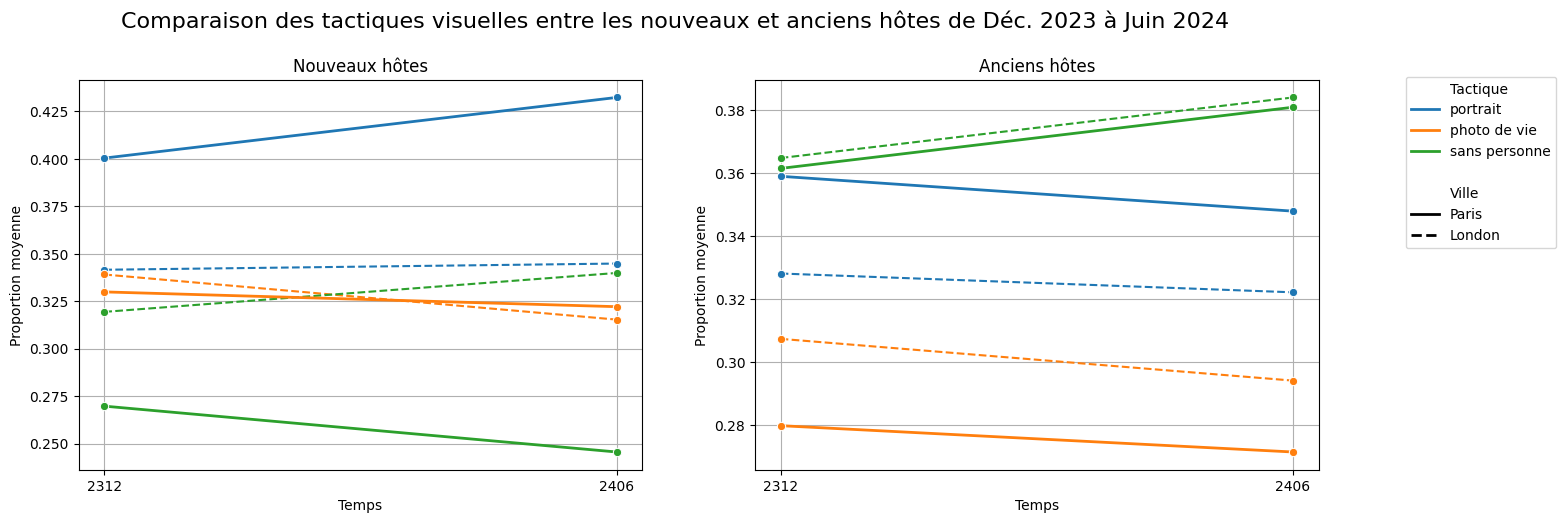

In [136]:
## new old hue:london/paris y=tactics_sig
## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(16, 5)) # sharey=True
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.2)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2])
axes.extend([ax1, ax2])


df_plot=df_plot_time.copy()
subplot_col1='is_new_host'
subplot_col2='in_paris'
tactics=tactics_pic_dummies#**


palette = {
    "ouverture": "#1f77b4",
    "authenticité": "#ff7f0e",
    "sociabilité": "#2ca02c",
    "auto_promotion": "#d62728",
    "exemplarité": "#9467bd",
    
    "is_portrait": "#1f77b4",
    "is_lifestyle": "#ff7f0e",
    "no_person": "#2ca02c",
}


for i, new in enumerate(df_plot[subplot_col1].unique()):
    ax=axes[i]
    
    # tactics_sig=['ouverture',"sociabilité","exemplarité"] if new==1 else ['auto_promotion'] 
    tactics_sig=tactics_pic_dummies#***
    for p in df_plot[subplot_col2].unique():#***
        print(f"{subplot_col1}={new}, {subplot_col2}={p}")#***        
        # ---sub data---
        sub=df_plot[(df_plot[subplot_col1]==new)&(df_plot[subplot_col2]==p)&(df_plot['variable'].isin(tactics_sig))]#***
        # display(sub)
        # print(len(sub))#=5 tactics*2 times=10
        
        sns.lineplot(
            data=sub,
            x='time',#***hue
            y="mean",
            hue="variable",
            marker="o",
            linestyle='-' if p==1 else '--',
            linewidth= 2 if p==1 else 1.5,
            palette=palette,
            legend=False,
            ax=ax,
        )

    ax.grid()
    ax.set_xlabel("Temps")
    ax.set_ylabel("Proportion moyenne")
    # ax.tick_params(axis="x",rotation=30)
    ax.set_title(f"{'Nouveaux hôtes' if new==1 else 'Anciens hôtes'}")

    # ax.add_artist(leg1)  # ❗保留第一个 legend
    from matplotlib.lines import Line2D

    legend_elements = []
    # ---标题：策略---
    legend_elements.append(Line2D([], [], linestyle="none", label="Tactique"))
    var_map={
        'is_portrait':"portrait",
        "is_lifestyle":'photo de vie',
        "no_person":'sans personne'
    }
    for var in tactics_sig:
        legend_elements.append(
        Line2D([0], [0], color=palette[var], lw=2, label=var_map.get(var, "") if var in var_map.keys() else var)
        )

    # ---空行---
    legend_elements.append(Line2D([], [], linestyle="none", label=""))

    # ---标题：城市---
    legend_elements.append(Line2D([], [], linestyle="none", label="Ville"))

    legend_elements.append(
        Line2D([0], [0], color="black", lw=2, linestyle="-", label="Paris")
    )
    legend_elements.append(
        Line2D([0], [0], color="black", lw=2, linestyle="--", label="London")
    )
    i+=1        
        
    # break

## ---legend 2facets----
fig.suptitle(
        f"Comparaison des tactiques visuelles entre les nouveaux et anciens hôtes de Déc. 2023 à Juin 2024 ",
        fontsize=16,
        y=1.02
    )

fig.legend(
        handles=legend_elements,
        loc="upper left",
        bbox_to_anchor=(0.95, 0.9),
        frameon=True
    )

plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.1)#控制子图到底的距离，给text留出空间

plt.show()

in_paris=0, is_new_host=1
10
in_paris=0, is_new_host=0
10
in_paris=1, is_new_host=1
10
in_paris=1, is_new_host=0
10


C:\Users\yeliu\AppData\Local\Temp\ipykernel_18128\113358066.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.9, 1])# [left, bottom, right, top]


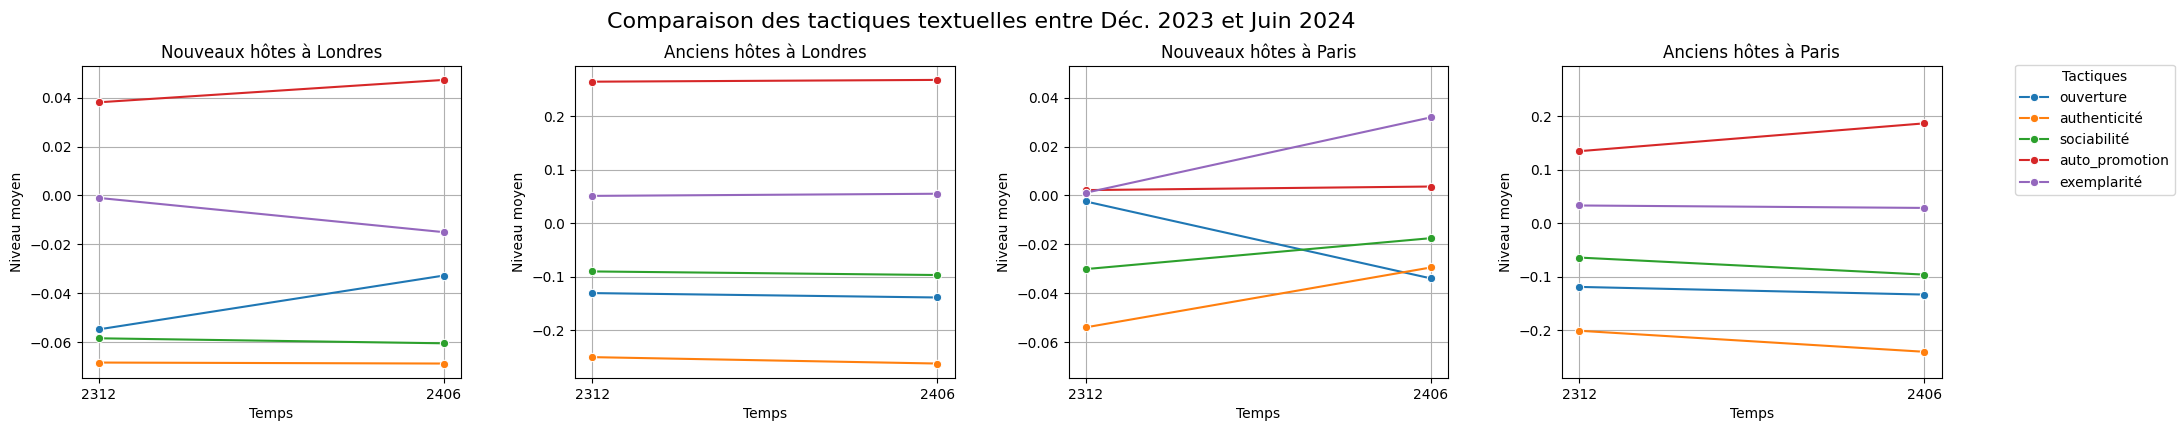

In [50]:
## london + paris new + old 2312 vs 2406
import matplotlib.pyplot as plt
importlib.reload(desc_new_old)
from utils.desc_new_old import ttest_new_old

# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # ==len(hue) 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))
colors = (
    list(london_colors) +
    list(paris_colors)
)

## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(24, 4)) 
gs = gridspec.GridSpec(1, 4, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2])#**
ax3 = fig.add_subplot(gs[0, 2:3], sharey=ax1)#**
ax4 = fig.add_subplot(gs[0, 3:4], sharey=ax2)#**
axes.extend([ax1, ax2, ax3, ax4])

# ---plot---
subplot_col1='in_paris'
subplot_col2='is_new_host'
tactics=tactics_bio
i=0
df_plot=df_plot_time.copy()
for p in df_plot[subplot_col1].unique():#***
    for new in df_plot[subplot_col2].unique():#***
        print(f"{subplot_col1}={p}, {subplot_col2}={new}")#***
        ax=axes[i]
        
        # ---sub data---
        sub=df_plot[(df_plot[subplot_col1]==p)&(df_plot[subplot_col2]==new)&(df_plot['variable'].isin(tactics))]#***
        # display(sub)
        print(len(sub))#=5 tactics*2 times=10
        
        sns.lineplot(
            data=sub,
            x='time',#***hue
            y="mean",
            hue="variable",
            marker="o",
            ax=ax
        )

        ax.set_xlabel("Temps")
        ax.set_ylabel("Niveau moyen")
        # ax.tick_params(axis="x",rotation=30)
        ax.set_title(f"{'Nouveaux hôtes' if new==1 else 'Anciens hôtes'} à {'Paris' if p==1 else 'Londres'}")
        if ax.legend():
            ax.get_legend().remove()
            
        # ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
        ax.grid()
        i+=1
        

## ---legend 2facets----
fig.suptitle(
        # "Effets marginaux des tactiques visuelles entre les groupes",
        "Comparaison des tactiques textuelles entre Déc. 2023 et Juin 2024",
        fontsize=16,
        y=1.02
    )


# plt.figtext(
#     0.5, 0.01,
#     "Significativité de la différence entre des nouveaux et anciens hôtes : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
#     ha="center",
#     fontsize=10,
#     style="italic",   
# )

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title="Tactiques", loc="upper right", bbox_to_anchor=(1, 0.9))
plt.tight_layout(rect=[0, 0.1, 0.9, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.1)#控制子图到底的距离，给text留出空间

plt.show()


#新老房东使用策略是否发生随时间发生显著变化？
# 先看平均水平：几乎都是是平行的

## ttest显著但是还需要检查效应量！极小的差异也可能显著cohensd

## 如果有jo冲击，paris新房东变化-london新房东变化显著， paris老房东变化-london老房东变化显著，
# 但新老房东显著的策略不同？

in_paris=0, is_new_host=1
6
in_paris=0, is_new_host=0
6
in_paris=1, is_new_host=1
6
in_paris=1, is_new_host=0
6


C:\Users\yeliu\AppData\Local\Temp\ipykernel_18128\1969020968.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.9, 1])# [left, bottom, right, top]


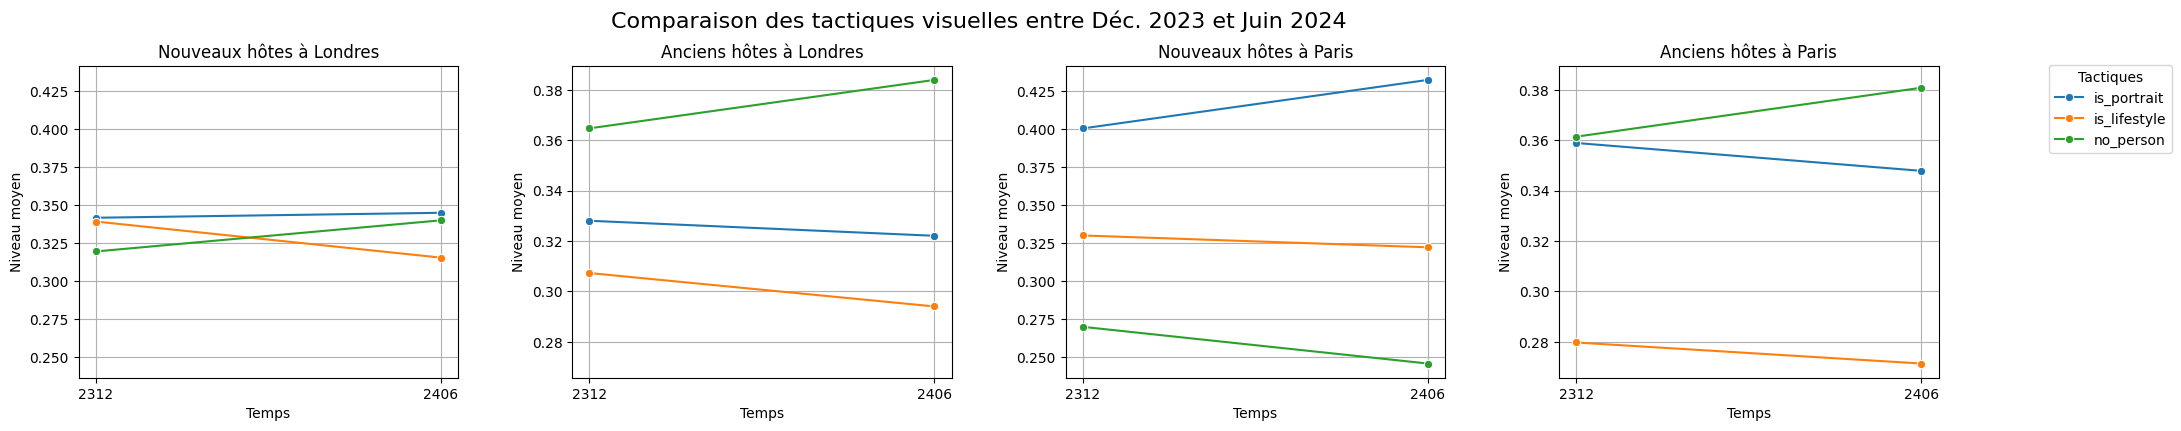

In [51]:
## london + paris new + old 2312 vs 2406
import matplotlib.pyplot as plt
importlib.reload(desc_new_old)
from utils.desc_new_old import ttest_new_old

# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # ==len(hue) 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))
colors = (
    list(london_colors) +
    list(paris_colors)
)

## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(24, 4)) 
gs = gridspec.GridSpec(1, 4, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2])#**
ax3 = fig.add_subplot(gs[0, 2:3], sharey=ax1)#**
ax4 = fig.add_subplot(gs[0, 3:4], sharey=ax2)#**
axes.extend([ax1, ax2, ax3, ax4])

# ---plot---
subplot_col1='in_paris'
subplot_col2='is_new_host'
tactics=tactics_pic_dummies
i=0
for p in df_plot[subplot_col1].unique():#***
    for new in df_plot[subplot_col2].unique():#***
        print(f"{subplot_col1}={p}, {subplot_col2}={new}")#***
        ax=axes[i]
        
        # ---sub data---
        sub=df_plot[(df_plot[subplot_col1]==p)&(df_plot[subplot_col2]==new)&(df_plot['variable'].isin(tactics))]#***
        # display(sub)
        print(len(sub))#=5 tactics*2 times=10
        
        sns.lineplot(
            data=sub,
            x='time',#***hue
            y="mean",
            hue="variable",
            marker="o",
            ax=ax
        )

        ax.set_xlabel("Temps")
        ax.set_ylabel("Niveau moyen")
        # ax.tick_params(axis="x",rotation=30)
        ax.set_title(f"{'Nouveaux hôtes' if new==1 else 'Anciens hôtes'} à {'Paris' if p==1 else 'Londres'}")
        if ax.legend():
            ax.get_legend().remove()
            
        # ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
        ax.grid()
        i+=1

## ---legend 2facets----
fig.suptitle(
        # "Effets marginaux des tactiques visuelles entre les groupes",
        "Comparaison des tactiques visuelles entre Déc. 2023 et Juin 2024",
        fontsize=16,
        y=1.02
    )


# plt.figtext(
#     0.5, 0.01,
#     "Significativité de la différence entre des nouveaux et anciens hôtes : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
#     ha="center",
#     fontsize=10,
#     style="italic",   
# )

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title="Tactiques", loc="upper right", bbox_to_anchor=(1, 0.9))
plt.tight_layout(rect=[0, 0.1, 0.9, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.1)#控制子图到底的距离，给text留出空间

plt.show()


# bilan ddd

In [74]:
results_ddd_all['is_new_host']=2
results_ddd_all


,variable,coef,se,pval,sig,ci_low,ci_high,label,is_new_host
0,ouverture,-0.003955,0.005895,5.022069e-01,,-0.015509,0.007598,ouverture,2
0,authenticité,0.014043,0.006106,2.145399e-02,*,0.002076,0.026011,authenticité,2
0,sociabilité,0.012459,0.006310,4.832976e-02,*,0.000091,0.024827,sociabilité,2
0,auto_promotion,0.028564,0.005753,6.870991e-07,***,0.017288,0.039839,auto_promotion,2
0,exemplarité,0.024492,0.006112,6.149051e-05,***,0.012512,0.036471,exemplarité,2
0,is_portrait,0.017154,0.004337,7.652006e-05,***,0.008653,0.025654,portrait,2
0,is_lifestyle,0.014838,0.004201,4.121373e-04,***,0.006605,0.023072,photo de vie,2
0,no_person,-0.031992,0.003934,4.268024e-16,***,-0.039703,-0.024280,sans personne,2


In [75]:
results_ddd_new

,variable,is_new_host,coef,se,pval,sig,ci_low,ci_high,label
0,ouverture,1,-0.054887,0.013030,2.526307e-05,***,-0.080425,-0.029350,ouverture
0,ouverture,0,0.006926,0.007089,3.285956e-01,,-0.006969,0.020821,ouverture
0,authenticité,1,0.017398,0.013490,1.971377e-01,,-0.009041,0.043838,authenticité
0,authenticité,0,-0.004878,0.007340,5.063110e-01,,-0.019263,0.009508,authenticité
0,sociabilité,1,0.046684,0.013950,8.185835e-04,***,0.019342,0.074026,sociabilité
0,sociabilité,0,-0.011947,0.007590,1.154902e-01,,-0.026824,0.002930,sociabilité
0,auto_promotion,1,-0.007361,0.012715,5.626725e-01,,-0.032282,0.017561,auto_promotion
0,auto_promotion,0,0.034360,0.006918,6.820463e-07,***,0.020800,0.047920,auto_promotion
0,exemplarité,1,0.070282,0.013512,1.979308e-07,***,0.043799,0.096765,exemplarité
0,exemplarité,0,-0.004086,0.007352,5.783685e-01,,-0.018495,0.010324,exemplarité


In [77]:
order=tactics_bio+tactics_pic_labels
bilan=pd.concat([results_ddd_all, results_ddd_new], axis=0)
bilan=bilan.set_index('label').loc[order].reset_index()
bilan

,label,variable,coef,se,pval,sig,ci_low,ci_high,is_new_host
0,ouverture,ouverture,-0.003955,0.005895,5.022069e-01,,-0.015509,0.007598,2
1,ouverture,ouverture,-0.054887,0.013030,2.526307e-05,***,-0.080425,-0.029350,1
2,ouverture,ouverture,0.006926,0.007089,3.285956e-01,,-0.006969,0.020821,0
3,authenticité,authenticité,0.014043,0.006106,2.145399e-02,*,0.002076,0.026011,2
4,authenticité,authenticité,0.017398,0.013490,1.971377e-01,,-0.009041,0.043838,1
5,authenticité,authenticité,-0.004878,0.007340,5.063110e-01,,-0.019263,0.009508,0
6,sociabilité,sociabilité,0.012459,0.006310,4.832976e-02,*,0.000091,0.024827,2
7,sociabilité,sociabilité,0.046684,0.013950,8.185835e-04,***,0.019342,0.074026,1
8,sociabilité,sociabilité,-0.011947,0.007590,1.154902e-01,,-0.026824,0.002930,0
9,auto_promotion,auto_promotion,0.028564,0.005753,6.870991e-07,***,0.017288,0.039839,2


In [ ]:
ouverture|all_host|new_host|host




# changment des effects des tactiques

In [112]:
# all_data
df=df_all.copy()
formula= ("booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
        "number_of_reviews_ltm + "
        "C(host_is_superhost) +"
        "years_since_host + professional_host + "
        "host_response_rate +  C(host_response_time)+"
        "has_text + lang_en + lang_fr + text_length+"
        "price  + availability_90 + C(room_type) + C(instant_bookable) + "
        "in_paris * C(time) *(ouverture + authenticité + sociabilité + auto_promotion + exemplarité + C(host_picture_type))"
)
df=df_all.copy()
model_interaction=smf.ols(formula, data=df).fit()
summary=model_interaction.summary()
print(summary)

                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.402
Model:                            OLS   Adj. R-squared:                  0.402
Method:                 Least Squares   F-statistic:                     2601.
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:24:24   Log-Likelihood:                 89010.
No. Observations:              266852   AIC:                        -1.779e+05
Df Residuals:                  266782   BIC:                        -1.771e+05
Df Model:                          69                                         
Covariance Type:            nonrobust                                         
                                                                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

In [147]:
tactics_pic_cat=["C(host_picture_type)[T.no_person]","C(host_picture_type)[T.pro_style]"]
var_map={
        "C(host_picture_type)[T.no_person]":"sans personne",
        "C(host_picture_type)[T.pro_style]":"portrait"
    }
def get_ddd_effect_interaction(model, var):
    """
    in_paris:C(time)[T.2406] - in_paris:C(time)[T.2312]    
    """
    if var :
        term=f"in_paris:C(time)[T.2406]:{var} - in_paris:C(time)[T.2312]:{var} = 0"
    # print(term)
    
    test=model.t_test(term)
    
    return pd.DataFrame({
            'variable':var,
            "coef": test.effect[0],
            "se": test.sd[0],
            "pval": test.pvalue,
            "sig":p_to_sig(test.pvalue),
            "ci_low": test.conf_int()[0][0],
            "ci_high": test.conf_int()[0][1],
            'label':f"{var_map.get(var,'') if var in var_map.keys() else var}"
        })
    
    
# ddd_int=get_ddd_effect_interaction(model=model_interaction, var="authenticité")
# ddd_int

results_ddd_tactic = pd.concat([
    get_ddd_effect_interaction(model=model_interaction, var=var)
    for var in tactics_bio+tactics_pic_cat
])
results_ddd_tactic


,variable,coef,se,pval,sig,ci_low,ci_high,label
0,ouverture,-0.003793,0.002994,0.205081,,-0.009661,0.002074,ouverture
0,authenticité,-0.010129,0.003037,0.000854,***,-0.016082,-0.004175,authenticité
0,sociabilité,-0.003074,0.002907,0.290375,,-0.008772,0.002624,sociabilité
0,auto_promotion,0.002930,0.003018,0.331754,,-0.002986,0.008846,auto_promotion
0,exemplarité,0.001896,0.002783,0.495737,,-0.003559,0.007350,exemplarité
0,C(host_picture_type)[T.no_person],0.016284,0.004194,0.000103,***,0.008064,0.024503,sans personne
0,C(host_picture_type)[T.pro_style],-0.004110,0.004022,0.306761,,-0.011993,0.003772,portrait


C:\Users\yeliu\AppData\Local\Temp\ipykernel_1912\1412678739.py:39: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax.errorbar(


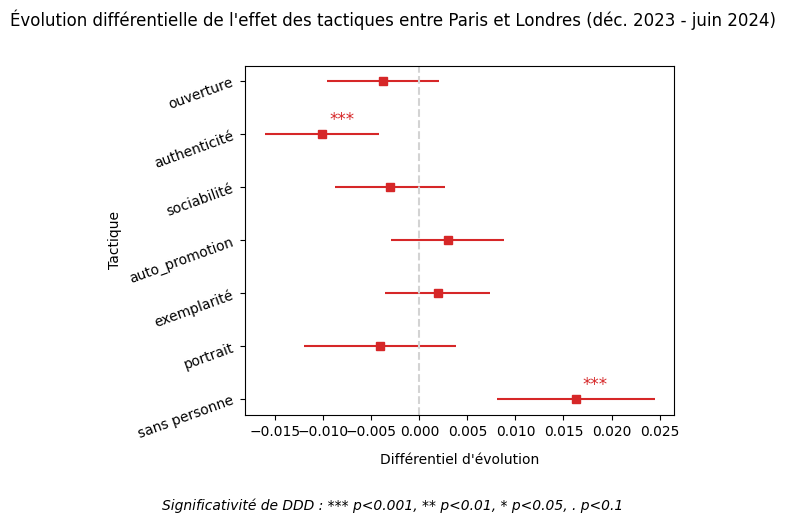

In [223]:

# # ---colors----
# blue_cmap = plt.cm.Blues
# orange_cmap = plt.cm.Oranges
# n = 2 # 每组柱子的数量
# london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
# paris_colors  = orange_cmap(np.linspace(0.5, 0.8, n))

# ## ---layout 2facets----
# import matplotlib.gridspec as gridspec
# fig = plt.figure(figsize=(14, 5)) 
# gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

# axes = []
# # 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
# ax1 = fig.add_subplot(gs[0, 0:1])
# ax2 = fig.add_subplot(gs[0, 1:2])#**
# axes.extend([ax1, ax2])


fig,ax=plt.subplots(figsize=(6,5))

df_plot=results_ddd_tactic.copy()
color_change="tab:red"


tactics=tactics_bio +['portrait', 'sans personne']

sub=df_plot[df_plot['label'].isin(tactics)].copy()

order = tactics[::-1]
sub["label"] = pd.Categorical(
    sub["label"],
    categories=order,
    ordered=True
)
sub = sub.sort_values("label")


ax.errorbar(
    x=sub["coef"],
    y=sub["label"],
    xerr=[sub["coef"] - sub["ci_low"], sub["ci_high"] - sub["coef"]],
    fmt='o', 
    marker="s",
    color=color_change
)
# ---sig---
for _, row in sub.iterrows():
    ax.annotate(
        row["sig"],
        xy=(row["coef"], row["label"]),
        xytext=(5, 10), 
        textcoords='offset points',
        
        ha='left',
        va='center',
        fontsize=12,
        color=color_change
)    
        
ax.axvline(0, linestyle='--', color="lightgray", label="Changement de Londres")    
ax.set_xlabel("Différentiel d'évolution", labelpad=10)
ax.set_ylabel('Tactique')
ax.tick_params(axis='y', rotation=20)
# ax.set_title()



# # ## ---legend 2facets----
fig.suptitle(
    "Évolution différentielle de l'effet des tactiques entre Paris et Londres (déc. 2023 - juin 2024)",
    fontsize=12,
    y=1.01
)
plt.figtext(
    0.5, 0.01,
    "Significativité de DDD : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=10,
    style="italic",   
)
plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()

## 文本策略大多不敏感？图片策略敏感
## authen效果下降更多

In [158]:
def get_real_cf_effect_data(model, tactics):
    results = []
    for var in tactics:
        print(var)        
        specs = [
            # london:
            ("2306", 0, var),
            ("2312", 0, f"{var} + C(time)[T.2312]:{var}"),
            ("2406", 0, f"{var} + C(time)[T.2406]:{var}"),
            
            # paris:
            ("2306", 1, f"{var} + in_paris:{var}"),
            
            ("2312", 1, f"""
                {var}
                + C(time)[T.2312]:{var}
                + in_paris:{var}
                + in_paris:C(time)[T.2312]:{var}
            """),
            
            ("2406", 1, f"""
                {var}
                + C(time)[T.2406]:{var}
                + in_paris:{var}
                + in_paris:C(time)[T.2406]:{var}
            """)        
        ]
    
        for time, paris, term in specs:
            test = model.t_test(term)
            # print(test)
            if time=="2406" and paris==1:
                ddd_term= f"""    
                in_paris:C(time)[T.2406]:{var}
                -in_paris:C(time)[T.2312]:{var}
                """
                ddd_test = model.t_test(ddd_term)
                print(f"ddd of var {var}:{ddd_test.effect[0]}\n")              
                effect_cf=test.effect[0]-ddd_test.effect[0]
            else :
                effect_cf=test.effect[0]
                    
            res={
            "time": time,
            "in_paris": paris,
            "variable":var,
            "effect_hat": test.effect[0],
            "effect_cf": effect_cf,
            "se": test.sd[0],
            "pval": test.pvalue,
            "sig":p_to_sig(test.pvalue),
            "ci_low": test.conf_int()[0][0],
            "ci_high": test.conf_int()[0][1],
            'label':f"{var_map.get(var,'') if var in var_map.keys() else var}"
            }
            results.append(res)
            
    df_results=pd.DataFrame(results)
    order = ["2306", "2312", "2406"]
    df_results["time"] = pd.Categorical(df_results["time"], categories=order, ordered=True)

    return df_results

tactics_effects=get_real_cf_effect_data(model=model_interaction, tactics=tactics_bio+tactics_pic_cat)

ouverture
ddd of var ouverture:-0.0037933983851114045

authenticité
ddd of var authenticité:-0.010128592202000433

sociabilité
ddd of var sociabilité:-0.003073705648097845

auto_promotion
ddd of var auto_promotion:0.0029296324016956157

exemplarité
ddd of var exemplarité:0.0018956947076475901

C(host_picture_type)[T.no_person]
ddd of var C(host_picture_type)[T.no_person]:0.01628397331248187

C(host_picture_type)[T.pro_style]
ddd of var C(host_picture_type)[T.pro_style]:-0.004110311131018052



In [385]:
tactics_effects[(tactics_effects['time']=='2406')&(tactics_effects['in_paris']==1)]

,time,in_paris,variable,effect_hat,effect_cf,se,pval,sig,ci_low,ci_high,label
5,2406,1,ouverture,-0.001756,0.002037,[0.0013665998638107627],0.198718851061418,,-0.004435,0.000922,ouverture
11,2406,1,authenticité,-0.000873,0.009256,[0.001410673074096899],0.5361320885646135,,-0.003638,0.001892,authenticité
17,2406,1,sociabilité,0.001823,0.004896,[0.001344942946684494],0.17536620839617312,,-0.000813,0.004459,sociabilité
23,2406,1,auto_promotion,-0.000408,-0.003338,[0.0014393320941209111],0.7766586331480403,,-0.003229,0.002413,auto_promotion
29,2406,1,exemplarité,-0.001056,-0.002952,[0.0012182240833406013],0.38601810228644184,,-0.003444,0.001332,exemplarité
35,2406,1,C(host_picture_type)[T.no_person],0.006079,-0.010205,[0.0018944567193281121],0.0013318725226930867,**,0.002366,0.009793,sans personne
41,2406,1,C(host_picture_type)[T.pro_style],0.003061,0.007171,[0.0016951895370272215],0.07099569394096006,.,-0.000262,0.006383,portrait


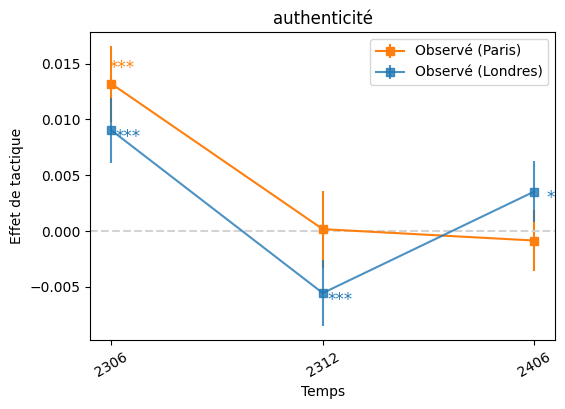

In [123]:
from utils import modeling_did
importlib.reload(modeling_did)
from utils.modeling_did import plot_one_real_cf_effect
plot_one_real_cf_effect(df_plot=tactics_effects, var="authenticité", cf=False)


In [152]:

results_ddd_tactic[results_ddd_tactic['label']==var]['sig'].iloc[0]



'***'

0 ouverture 
1 authenticité ***
2 sociabilité 
3 auto_promotion 
4 exemplarité 


C:\Users\yeliu\AppData\Local\Temp\ipykernel_1912\2154158649.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1,1])


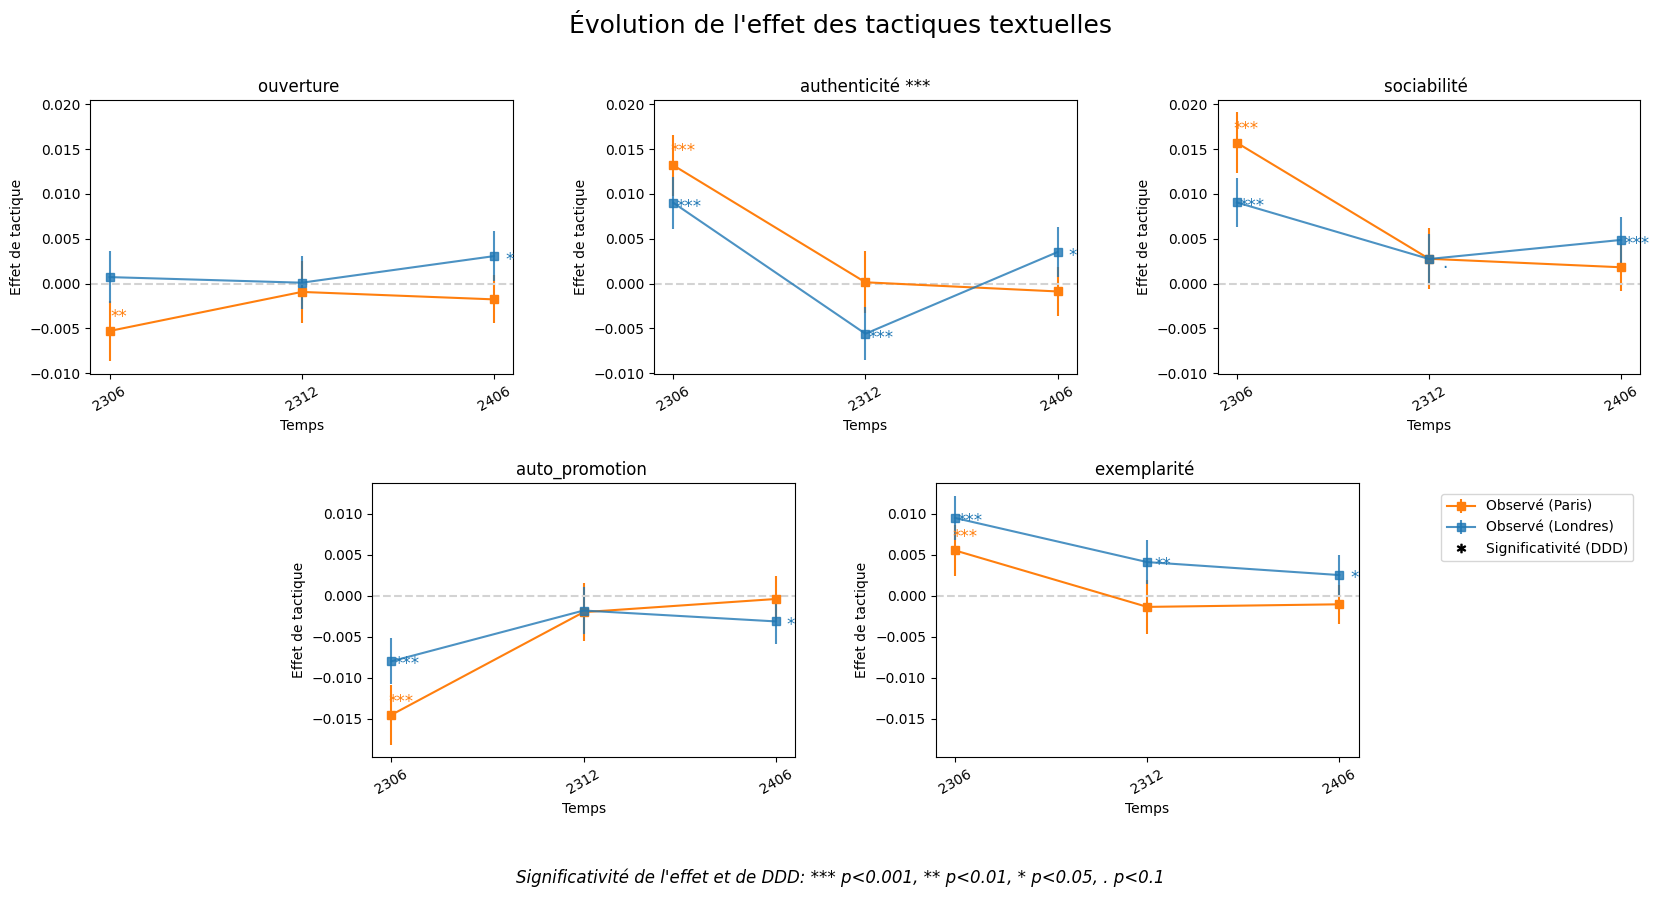

In [214]:
importlib.reload(modeling_did)
from utils.modeling_did import plot_one_real_cf_effect
import matplotlib.gridspec as gridspec

# -------------------layout-------------------
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# # 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4], sharey=ax1)
ax3 = fig.add_subplot(gs[0, 4:6], sharey=ax1)
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5], sharey=ax4)
axes.extend([ax4, ax5])


# --------------------------------------------

df_plot=tactics_effects.copy()
tactics=tactics_bio

## plot
for i, var in enumerate(tactics):
    sig=results_ddd_tactic[results_ddd_tactic['label']==var]['sig'].iloc[0]
    print(i, var, sig)
    plot_one_real_cf_effect(df_plot=df_plot, var=var, axes=axes, i=i, cf=False, title=f"{var} {sig}")

# --------------------legend------------------------
fig.suptitle(
        "Évolution de l'effet des tactiques textuelles",
        fontsize=18,
        y=0.98 #大标题到子图的距离, 越大越远
    )

from matplotlib.lines import Line2D
handles, labels = axes[0].get_legend_handles_labels()

# --- add custom legend :sig note ---
handles.append(
    Line2D([0], [0], marker='$*$', linestyle='None', color='black',markersize=6,
           label='Significativité (DDD)')
)
labels = labels + [
    "Significativité (DDD)"
]


fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.9,0.45) # legend (x, y)，x>1则在图外, y=0在底线
)

plt.figtext(
    0.5, 0.01,
    "Significativité de l'effet et de DDD: *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic"   
)

plt.tight_layout(rect=[0, 0.1, 1,1])
plt.subplots_adjust(bottom=0.15)#控制子图到底的距离，给text留出空间
plt.show()

# paris 2312-2406包括了时间变化+jo的ddd变化
##ouv，authen,soc下降，authen, exem提升，但是相对于london 2306都不显著？？



0 portrait 
1 sans personne ***


C:\Users\yeliu\AppData\Local\Temp\ipykernel_1912\3665602145.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.9,1])


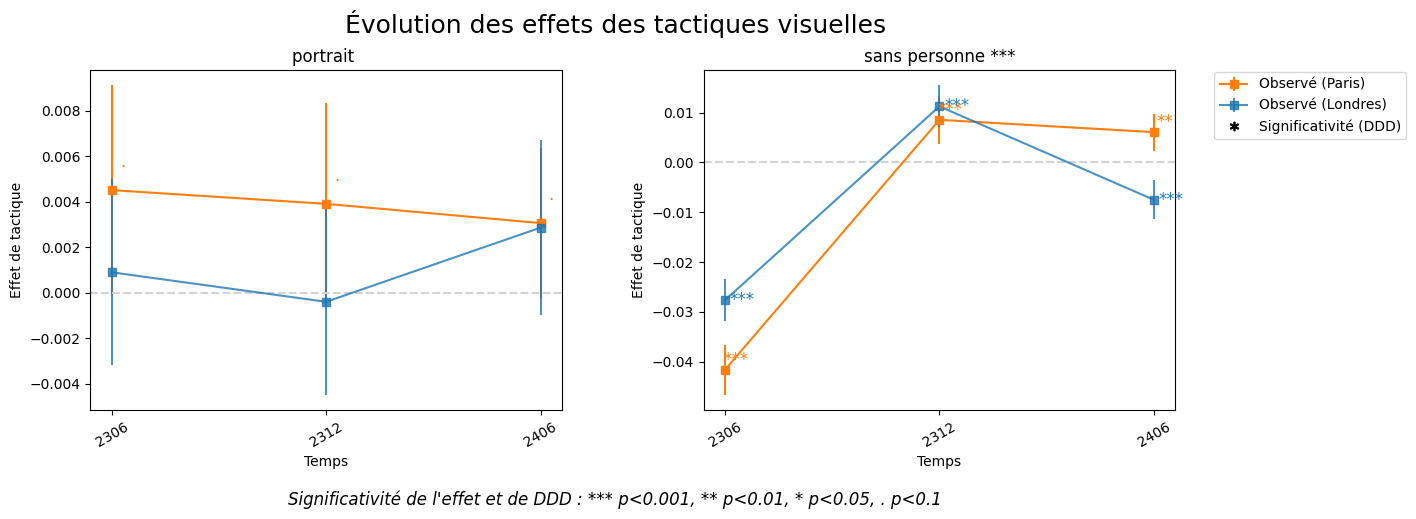

In [213]:
importlib.reload(modeling_did)
from utils.modeling_did import plot_one_real_cf_effect
import matplotlib.gridspec as gridspec


# tactics=tactics_pic_labels
## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(14, 5)) 
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2], sharex=ax1)#**
axes.extend([ax1, ax2])


# ---data---
df_plot=tactics_effects.copy()
tactics=['portrait','sans personne']

## plot
for i, var in enumerate(tactics):
    # print(i, var)
    # # lifestyle_2406p=df_plot[(df_plot['in_paris']==1)&(subdf['time']=="2406")&(df_plot['variable']=="is_lifestyle")]['effect_hat'].iloc[0]
    # # print(var, lifestyle_2024p)
    # plot_one_real_cf_effect(df_plot=df_plot, var=var, axes=axes, i=i, cf=False)
    sig=results_ddd_tactic[results_ddd_tactic['label']==var]['sig'].iloc[0]
    print(i, var, sig)
    plot_one_real_cf_effect(df_plot=df_plot, var=var, axes=axes, i=i, cf=False, title=f"{var} {sig}")



# --------------------legend------------------------
fig.suptitle(
        "Évolution des effets des tactiques visuelles",
        fontsize=18,
        y=1 #大标题到子图的距离, 越大越远
    )

from matplotlib.lines import Line2D
handles, labels = axes[0].get_legend_handles_labels()

# --- add custom legend :sig note ---
handles.append(
    Line2D([0], [0], marker='$*$', linestyle='None', color='black',markersize=6,
           label='Significativité (DDD)')
)
labels = labels + [
    "Significativité (DDD)"
]

fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(1.07,0.89) # legend (x, y)，x>1则在图外, y=0在底线
)

plt.figtext(
    0.5, 0.01,
    "Significativité de l'effet et de DDD : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic"   
)

plt.tight_layout(rect=[0, 0.1, 0.9,1])
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()



## photo的效果全部下降！
### jo是对sp的效果的打击？


## subdf

In [159]:
df=df_all[(df_all['time']=="2406")&(df_all['in_paris']==1)].copy()

formula= ("booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
        "number_of_reviews_ltm + "
        "C(host_is_superhost) +"
        "years_since_host + professional_host + "
        "host_response_rate +  C(host_response_time)+"
        "has_text + lang_en + lang_fr + text_length+"
        "price  + availability_90 + C(room_type) + C(instant_bookable) + "
        "ouverture + authenticité + sociabilité + auto_promotion + exemplarité+"
        "C(host_picture_type)"
)

model_sub=smf.ols(formula, data=df).fit()
summary=model_sub.summary()
print(summary)

                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.350
Model:                            OLS   Adj. R-squared:                  0.349
Method:                 Least Squares   F-statistic:                     1162.
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:59:11   Log-Likelihood:                 39092.
No. Observations:               62738   AIC:                        -7.812e+04
Df Residuals:                   62708   BIC:                        -7.785e+04
Df Model:                          29                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

In [11]:
tactics_pic_cat=["C(host_picture_type)[T.pro_style]","C(host_picture_type)[T.no_person]"]

model=model_sub

tactics=tactics_bio+tactics_pic_cat
coef=model.params[tactics]
se=model.bse[tactics]
pval=model.pvalues[tactics]
results=[]
time="2406"
in_paris=1
res=pd.DataFrame({
    'time':time,
    "in_paris":in_paris,
    'variable':tactics,
    'coef':coef,
    'se':se,
    'pval':pval
})
results.append(res)
results_df=pd.concat(results, axis=0)

results_df=results_df.reset_index(drop=True)
results_df['sig']=results_df['pval'].apply(p_to_sig)
display(results_df)

,time,in_paris,variable,coef,se,pval,sig
0,2406,1,ouverture,-0.003366,0.001076,1.766269e-03,**
1,2406,1,authenticité,0.002602,0.001112,1.935930e-02,*
2,2406,1,sociabilité,0.004565,0.001026,8.562325e-06,***
3,2406,1,auto_promotion,-0.006597,0.001188,2.835222e-08,***
4,2406,1,exemplarité,0.001418,0.000922,1.240435e-01,
5,2406,1,C(host_picture_type)[T.pro_style],0.003923,0.001271,2.028729e-03,**
6,2406,1,C(host_picture_type)[T.no_person],-0.003843,0.001522,1.157879e-02,*


In [160]:

tactics=tactics_bio+tactics_pic_cat
var_map={
    'C(host_picture_type)[T.no_person]':"sans personne",
    'C(host_picture_type)[T.pro_style]':'portrait'
}

results=[]

i=0
for p in df_all['in_paris'].unique():
    for t in df_all['time'].unique():
        print(f"in_paris={p}, time={t}")
        df=df_all[(df_all['in_paris']==p)&(df_all['time']==t)].copy()
        print(df[['in_paris','time']].value_counts(dropna=False))
        formula= ("booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
                "number_of_reviews_ltm + "
                "C(host_is_superhost) +"
                "years_since_host + professional_host + "
                "host_response_rate +  C(host_response_time)+"
                "has_text + lang_en + lang_fr + text_length+"
                "price  + availability_90 + C(room_type) + C(instant_bookable) + "
                # "in_paris+C(time)+"
                "ouverture + authenticité + sociabilité + auto_promotion + exemplarité+"
                "C(host_picture_type)"
        )
        model_sub=smf.ols(formula, data=df).fit()
        if i ==0:
            print(model_sub.summary())
        # ---data---
        coef=model_sub.params[tactics]
        se=model_sub.bse[tactics]
        pval=model_sub.pvalues[tactics]
        labels=[var_map.get(var,'') if var in var_map.keys() else var for var in tactics]
        res=pd.DataFrame({
            'time':t,
            "in_paris":p,
            'variable':tactics,
            'coef':coef.values,
            'se':se.values,
            'pval':pval.values,
            "ci_low": (coef - 1.96 * se).values,
            "ci_high": (coef + 1.96 * se).values,
            'label':labels
        })
        
        results.append(res)
        i+=0
        # break
results_df=pd.concat(results, axis=0)
results_df=results_df.reset_index(drop=True)
results_df['sig']=results_df['pval'].apply(p_to_sig)
tactics_effects_sepa=results_df.copy()
display(tactics_effects_sepa)

in_paris=0, time=2306
in_paris  time
0         2306    42356
Name: count, dtype: int64
                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.441
Model:                            OLS   Adj. R-squared:                  0.441
Method:                 Least Squares   F-statistic:                     1151.
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:59:22   Log-Likelihood:                 8002.4
No. Observations:               42356   AIC:                        -1.594e+04
Df Residuals:                   42326   BIC:                        -1.569e+04
Df Model:                          29                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------

,time,in_paris,variable,coef,se,pval,ci_low,ci_high,label,sig
0,2306,0,ouverture,-0.000827,0.001711,6.287276e-01,-0.004180,0.002526,ouverture,
1,2306,0,authenticité,0.005319,0.001753,2.409652e-03,0.001883,0.008754,authenticité,**
2,2306,0,sociabilité,0.009638,0.001629,3.349743e-09,0.006444,0.012832,sociabilité,***
3,2306,0,auto_promotion,-0.007121,0.001796,7.350288e-05,-0.010641,-0.003601,auto_promotion,***
4,2306,0,exemplarité,0.008508,0.001615,1.390057e-07,0.005342,0.011674,exemplarité,***
5,2306,0,C(host_picture_type)[T.no_person],-0.013235,0.002609,3.935652e-07,-0.018348,-0.008121,sans personne,***
6,2306,0,C(host_picture_type)[T.pro_style],0.000408,0.002420,8.659524e-01,-0.004334,0.005151,portrait,
7,2312,0,ouverture,0.001577,0.001186,1.835962e-01,-0.000747,0.003901,ouverture,
8,2312,0,authenticité,-0.001839,0.001218,1.310909e-01,-0.004226,0.000548,authenticité,
9,2312,0,sociabilité,0.003440,0.001136,2.460069e-03,0.001214,0.005667,sociabilité,**


In [161]:
tactics_effects_sepa[(tactics_effects_sepa['time']=='2406')&(tactics_effects['in_paris']==1)]

,time,in_paris,variable,coef,se,pval,ci_low,ci_high,label,sig
15,2406,0,authenticité,0.001989,0.001343,0.138492,-0.000643,0.004621,authenticité,
16,2406,0,sociabilité,0.003311,0.001255,0.008355,0.000851,0.005772,sociabilité,**
17,2406,0,auto_promotion,-0.001295,0.001402,0.355391,-0.004043,0.001452,auto_promotion,
35,2406,1,ouverture,-0.003366,0.001076,0.001766,-0.005476,-0.001256,ouverture,**
39,2406,1,exemplarité,0.001418,0.000922,0.124044,-0.000389,0.003226,exemplarité,
40,2406,1,C(host_picture_type)[T.no_person],-0.003843,0.001522,0.011579,-0.006825,-0.000860,sans personne,*
41,2406,1,C(host_picture_type)[T.pro_style],0.003923,0.001271,0.002029,0.001432,0.006415,portrait,**


In [164]:
results_ddd_tactic

,variable,coef,se,pval,sig,ci_low,ci_high,label
0,ouverture,-0.003793,0.002994,0.205081,,-0.009661,0.002074,ouverture
0,authenticité,-0.010129,0.003037,0.000854,***,-0.016082,-0.004175,authenticité
0,sociabilité,-0.003074,0.002907,0.290375,,-0.008772,0.002624,sociabilité
0,auto_promotion,0.002930,0.003018,0.331754,,-0.002986,0.008846,auto_promotion
0,exemplarité,0.001896,0.002783,0.495737,,-0.003559,0.007350,exemplarité
0,C(host_picture_type)[T.no_person],0.016284,0.004194,0.000103,***,0.008064,0.024503,sans personne
0,C(host_picture_type)[T.pro_style],-0.004110,0.004022,0.306761,,-0.011993,0.003772,portrait


,time,in_paris,variable,coef,se,pval,ci_low,ci_high,label,sig
1,2306,0,authenticité,0.005319,0.001753,0.002410,0.001883,0.008754,authenticité,**
8,2312,0,authenticité,-0.001839,0.001218,0.131091,-0.004226,0.000548,authenticité,
15,2406,0,authenticité,0.001989,0.001343,0.138492,-0.000643,0.004621,authenticité,
22,2306,1,authenticité,0.004792,0.002396,0.045548,0.000095,0.009489,authenticité,*
29,2312,1,authenticité,0.002922,0.001924,0.128835,-0.000849,0.006693,authenticité,
36,2406,1,authenticité,0.002602,0.001112,0.019359,0.000421,0.004782,authenticité,*


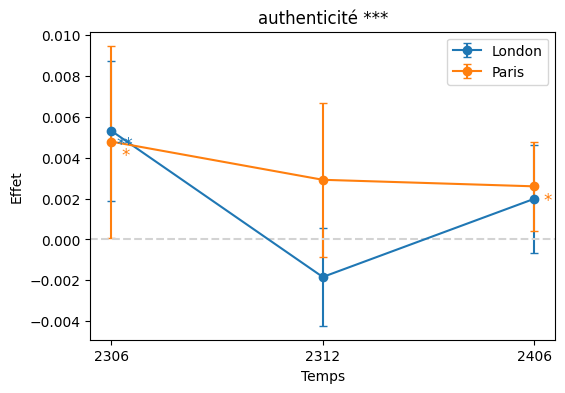

In [165]:
df_plot=tactics_effects_sepa.copy()

var='authenticité'
sub=df_plot[df_plot['variable']==var]
display(sub)

fig, ax = plt.subplots(figsize=(6,4))

for p in sub["in_paris"].unique():
    g = sub[sub["in_paris"] == p]
    ax.errorbar(
        x=g["time"],
        y=g["coef"],
        yerr=1.96 * g["se"],   # 或直接 ci_low/high
        marker="o",
        linestyle="-",
        capsize=3,
        label=f"{'Paris' if p==1 else 'London'}"
    )
    for _, row in g.iterrows():
        if row['sig'] != "":
            ax.annotate(
                row['sig'],
                xy=(row['time'], row['coef']),
                xytext=(10, -10),
                textcoords='offset points',
                ha='center',
                va='center',
                fontsize=12,
                color='tab:blue' if row['in_paris']==0 else 'tab:orange'
            )
               
# ---layout---
sig_ddd=results_ddd_tactic[results_ddd_tactic['label']==var]['sig'].iloc[0]

ax.set_xlabel("Temps")
ax.set_ylabel("Effet")
ax.set_title(f"{var} {sig_ddd}")
ax.axhline(0, color="lightgray", linestyle='--')
ax.legend()

0 ouverture
1 authenticité
2 sociabilité
3 auto_promotion
4 exemplarité


C:\Users\yeliu\AppData\Local\Temp\ipykernel_1912\4069082119.py:101: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1,1])


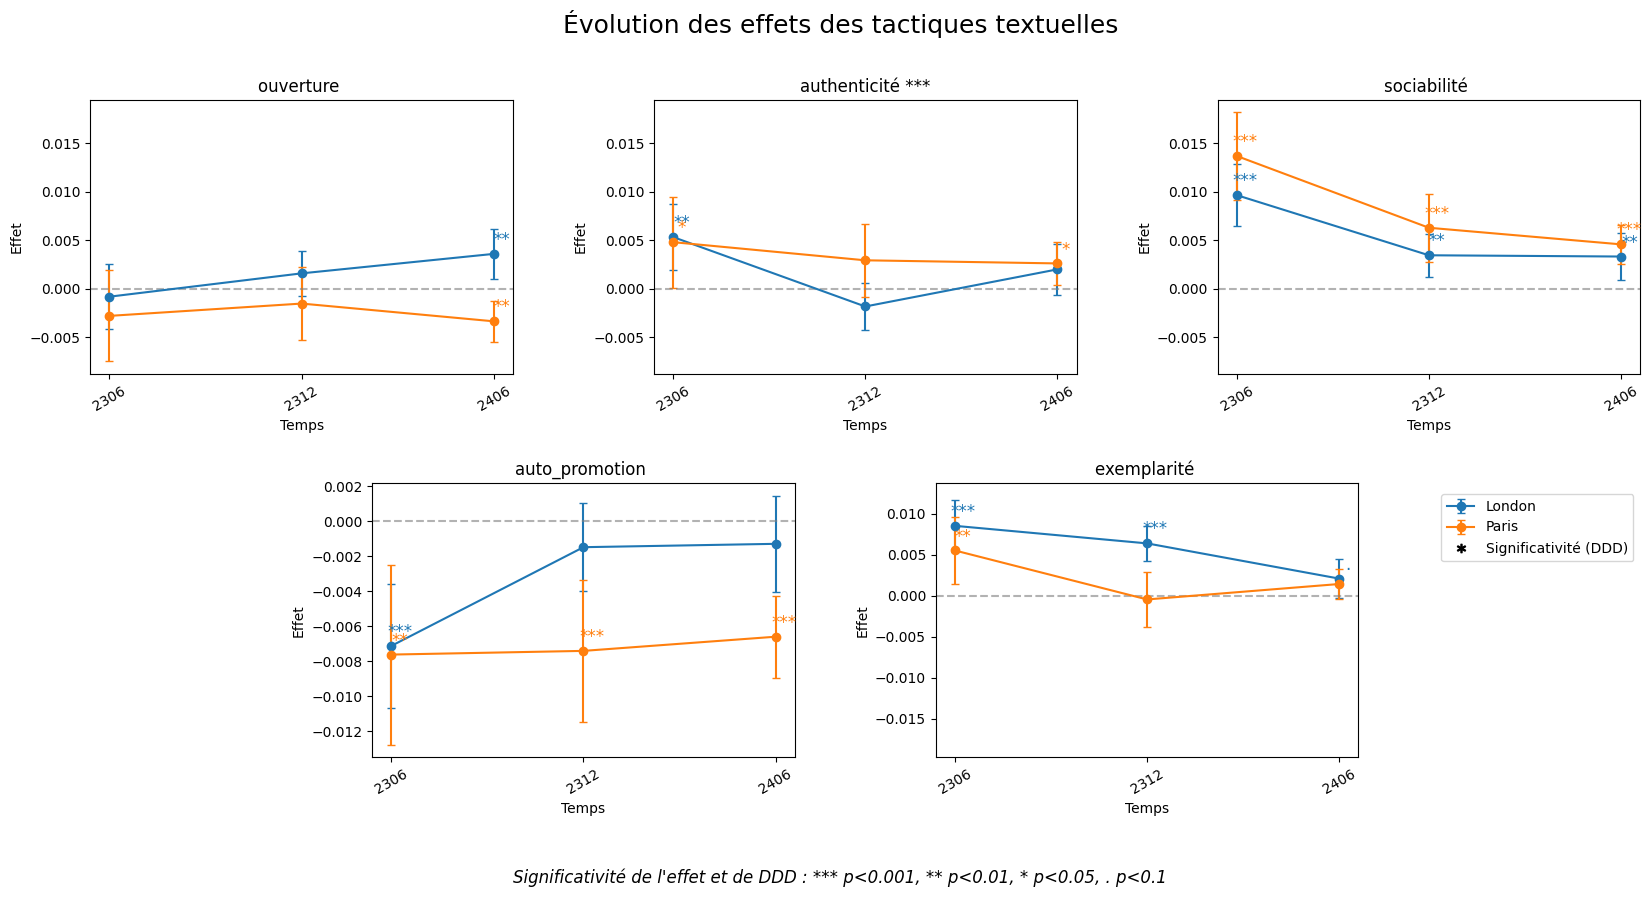

In [217]:

df_plot=tactics_effects_sepa.copy()
tactics=tactics_bio

# ---layout 5facets---
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# # 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4], sharey=ax1)
ax3 = fig.add_subplot(gs[0, 4:6], sharey=ax1)
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5], sharey=ax5)
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics), len(axes))

# ---plot---
for i, var in enumerate(tactics):
    ax=axes[i]
    
    print(i,var)
    sub=df_plot[df_plot['label']==var]
    # display(sub)
    
    for p in sub["in_paris"].unique():
        g = sub[sub["in_paris"] == p]
        ax.errorbar(
            x=g["time"],
            y=g["coef"],
            yerr=1.96 * g["se"],   # 或直接 ci_low/high
            marker="o",
            linestyle="-",
            capsize=3,
            label=f"{'Paris' if p==1 else 'London'}",
        )
        for _, row in g.iterrows():
            if row['sig'] != "":
                ax.annotate(
                    row['sig'],
                    xy=(row['time'], row['coef']),
                    xytext=(6, 10),
                    textcoords='offset points',
                    ha='center',
                    va='center',
                    fontsize=12,
                    color='tab:blue' if row['in_paris']==0 else 'tab:orange'
                )
            
    # ---layout---
    sig_ddd=results_ddd_tactic[results_ddd_tactic['label']==var]['sig'].iloc[0]

    ax.set_xlabel("Temps")
    ax.tick_params(axis="x", rotation=30)
    ax.set_ylabel("Effet")
    ax.set_title(f"{var} {sig_ddd}")
    ax.axhline(0, color="gray", alpha=0.6, linestyle='--')
    
    # break

# --------------------legend------------------------
fig.suptitle(
        "Évolution des effets des tactiques textuelles",
        fontsize=18,
        y=0.98 #大标题到子图的距离, 越大越远
    )

from matplotlib.lines import Line2D
handles, labels = axes[0].get_legend_handles_labels()

# --- add custom legend :sig note ---
handles.append(
    Line2D([0], [0], marker='$*$', linestyle='None', color='black',markersize=6,
           label='Significativité (DDD)')
)
labels = labels + [
    "Significativité (DDD)"
]

fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.9,0.45) # legend (x, y)，x>1则在图外, y=0在底线
)

plt.figtext(
    0.5, 0.01,
    "Significativité de l'effet et de DDD : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic"   
)

plt.tight_layout(rect=[0, 0.1, 1,1])
plt.subplots_adjust(bottom=0.15)#控制子图到底的距离，给text留出空间
plt.show()

# paris 2312-2406包括了时间变化+jo的ddd变化
##ouv，authen,soc下降，authen, exem提升，但是相对于london 2306都不显著？？



0 portrait


,time,in_paris,variable,coef,se,pval,ci_low,ci_high,label,sig
6,2306,0,C(host_picture_type)[T.pro_style],0.000408,0.002420,0.865952,-0.004334,0.005151,portrait,
13,2312,0,C(host_picture_type)[T.pro_style],-0.000815,0.001645,0.620247,-0.004039,0.002409,portrait,
20,2406,0,C(host_picture_type)[T.pro_style],0.003173,0.001841,0.084713,-0.000434,0.006781,portrait,.
27,2306,1,C(host_picture_type)[T.pro_style],0.002756,0.003048,0.365909,-0.003218,0.008730,portrait,
34,2312,1,C(host_picture_type)[T.pro_style],0.005158,0.002305,0.025262,0.000640,0.009676,portrait,*
41,2406,1,C(host_picture_type)[T.pro_style],0.003923,0.001271,0.002029,0.001432,0.006415,portrait,**


1 sans personne


,time,in_paris,variable,coef,se,pval,ci_low,ci_high,label,sig
5,2306,0,C(host_picture_type)[T.no_person],-0.013235,0.002609,3.935652e-07,-0.018348,-0.008121,sans personne,***
12,2312,0,C(host_picture_type)[T.no_person],-0.003278,0.001779,6.534963e-02,-0.006765,0.000208,sans personne,.
19,2406,0,C(host_picture_type)[T.no_person],-0.003793,0.001968,5.391905e-02,-0.007649,0.000064,sans personne,.
26,2306,1,C(host_picture_type)[T.no_person],-0.021212,0.003592,3.567639e-09,-0.028253,-0.014171,sans personne,***
33,2312,1,C(host_picture_type)[T.no_person],-0.003811,0.002681,1.551974e-01,-0.009067,0.001444,sans personne,
40,2406,1,C(host_picture_type)[T.no_person],-0.003843,0.001522,1.157879e-02,-0.006825,-0.000860,sans personne,*


C:\Users\yeliu\AppData\Local\Temp\ipykernel_1912\2032038387.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.2, 0.9,1])


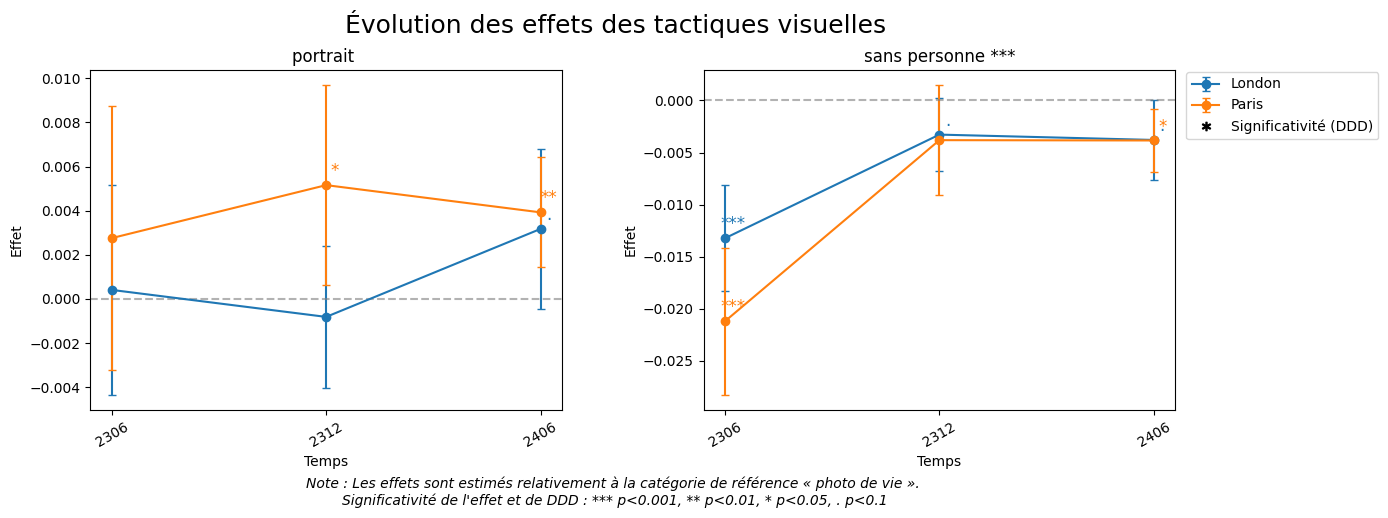

In [222]:
## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(14, 5)) 
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2])#**NO SHAREY
axes.extend([ax1, ax2])


# ---plot---
df_plot=tactics_effects_sepa.copy()
tactics=['portrait','sans personne']

for i, var in enumerate(tactics):
    ax=axes[i]
    
    print(i,var)
    sub=df_plot[df_plot['label']==var]
    display(sub)
    
    for p in sub["in_paris"].unique():
        g = sub[sub["in_paris"] == p]
        ax.errorbar(
            x=g["time"],
            y=g["coef"],
            yerr=1.96 * g["se"],   # 或直接 ci_low/high
            marker="o",
            linestyle="-",
            capsize=3,
            label=f"{'Paris' if p==1 else 'London'}",
        )
        for _, row in g.iterrows():
            if row['sig'] != "":
                ax.annotate(
                    row['sig'],
                    xy=(row['time'], row['coef']),
                    xytext=(6, 10),
                    textcoords='offset points',
                    ha='center',
                    va='center',
                    fontsize=12,
                    color='tab:blue' if row['in_paris']==0 else 'tab:orange'
                )
            
    # ---layout---
    ax.set_xlabel("Temps")
    ax.tick_params(axis="x", rotation=30)
    ax.set_ylabel("Effet")
    sig_ddd=results_ddd_tactic[results_ddd_tactic['label']==var]['sig'].iloc[0]

    ax.set_title(f"{var} {sig_ddd}")
    ax.axhline(0, color="gray", alpha=0.6, linestyle='--')
    
    # break

# --------------------legend------------------------
fig.suptitle(
        "Évolution des effets des tactiques visuelles",
        fontsize=18,
        y=1 #大标题到子图的距离, 越大越远
    )

from matplotlib.lines import Line2D
handles, labels = axes[0].get_legend_handles_labels()

# --- add custom legend :sig note ---
handles.append(
    Line2D([0], [0], marker='$*$', linestyle='None', color='black',markersize=6,
           label='Significativité (DDD)')
)
labels = labels + [
    "Significativité (DDD)"
]

fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(1.05,0.89) # legend (x, y)，x>1则在图外, y=0在底线
)

plt.figtext(
    0.5, 0.01,
    f"Note : Les effets sont estimés relativement à la catégorie de référence « photo de vie ». \n"
    f"Significativité de l'effet et de DDD : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=10,
    style="italic"   
)

plt.tight_layout(rect=[0, 0.2, 0.9,1])
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()
## 均下降，但是portrait下降最多，sans personne下降最少

## new old bookingrate

In [434]:
df=df_all.copy()
agg=df.groupby(['time','in_paris','is_new_host'])['booking_rate_l90d'].mean().reset_index(name="mean")
agg

,time,in_paris,is_new_host,mean
0,2306,0,0,0.162585
1,2306,1,0,0.213811
2,2312,0,0,0.069228
3,2312,0,1,0.080679
4,2312,1,0,0.093164
5,2312,1,1,0.123016
6,2406,0,0,0.113584
7,2406,0,1,0.138104
8,2406,1,0,0.085889
9,2406,1,1,0.064405


C:\Users\yeliu\AppData\Local\Temp\ipykernel_18128\3361451394.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]


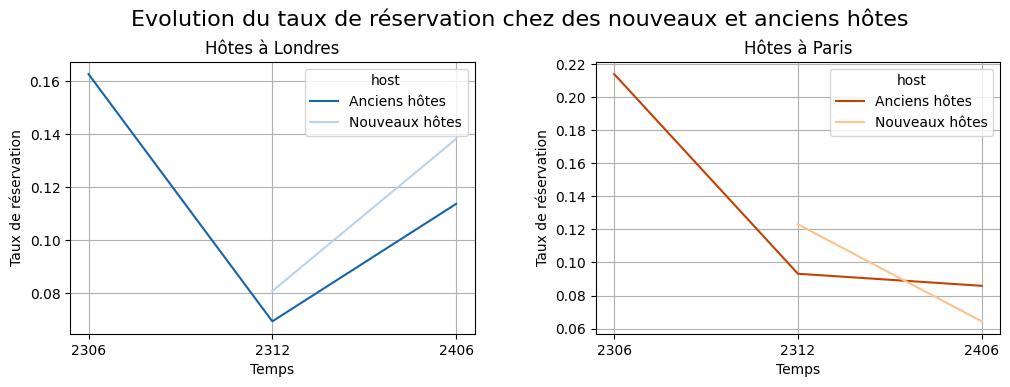

In [436]:

## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(12, 4)) 
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2], sharex=ax1)#**
axes.extend([ax1, ax2])


# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 2 # ==len(hue) 每组柱子的数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))


for i, p in enumerate(agg['in_paris'].unique()):
    ax=axes[i]
    sub=agg[agg['in_paris']==p].copy()
    sub["host"] = sub["is_new_host"].map({
        0: "Anciens hôtes",
        1: "Nouveaux hôtes"
    })
    colors=paris_colors if p==1 else london_colors

    sns.lineplot(
        data=sub,
        x="time",
        y="mean",
        hue="host",
        palette={
            "Anciens hôtes": colors[1],
            "Nouveaux hôtes": colors[0]
        },
        ax=ax
    )
    ax.grid()
    ax.set_title(f"Hôtes à {'Paris' if p==1 else 'Londres'}")
    ax.set_ylabel("Taux de réservation")
    ax.set_xlabel('Temps')
    
    
## ---legend 2facets----
fig.suptitle(
   'Evolution du taux de réservation chez des nouveaux et anciens hôtes',
    fontsize=16,
    y=1.01
)

plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()




## tactics_effect_new

In [456]:
df_all['is_new_host'].value_counts()

is_new_host
0    204510
1     62342
Name: count, dtype: int64

In [457]:
tactics=tactics_bio+tactics_pic_cat
results=[]

for p in df_all['in_paris'].unique():
    for t in df_all['time'].unique():
        print(f"in_paris={p}, time={t}")
        df=df_all[(df_all['in_paris']==p)&(df_all['time']==t)].copy()
        if t=="2306":
            formula= ("booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
                    "number_of_reviews_ltm + "
                    "C(host_is_superhost) +"
                    "years_since_host + professional_host + "
                    "host_response_rate +  C(host_response_time)+"
                    "has_text + lang_en + lang_fr + text_length+"
                    "price  + availability_90 + C(room_type) + C(instant_bookable) + "
                    "ouverture + authenticité + sociabilité + auto_promotion + exemplarité+C(host_picture_type)"
            )
        else :
            formula= ("booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
                    "number_of_reviews_ltm + "
                    "C(host_is_superhost) +"
                    "years_since_host + professional_host + "
                    "host_response_rate +  C(host_response_time)+"
                    "has_text + lang_en + lang_fr + text_length+"
                    "price  + availability_90 + C(room_type) + C(instant_bookable) + "
                    "is_new_host*(ouverture + authenticité + sociabilité + auto_promotion + exemplarité+C(host_picture_type))"
            )            
        model_sub=smf.ols(formula, data=df).fit()
        print(model_sub.summary())
        
        # ---data---
        coef=model_sub.params[tactics]
        se=model_sub.bse[tactics]
        pval=model_sub.pvalues[tactics]
        var_map={
            "C(host_picture_type)[T.no_person]":"sans personne",
            "C(host_picture_type)[T.pro_style]":"portrait"
        }
        labels=[var_map.get(var,'') if var in var_map.keys() else var for var in tactics]
        res=pd.DataFrame({
            'time':t,
            "in_paris":p,
            'variable':tactics,
            'coef':coef.values,
            'se':se.values,
            'pval':pval.values,
            "ci_low": (coef - 1.96 * se).values,
            "ci_high": (coef + 1.96 * se).values,
            'label':labels
        })
        results.append(res)
        break
results_df=pd.concat(results, axis=0)
results_df=results_df.reset_index(drop=True)
results_df['sig']=results_df['pval'].apply(p_to_sig)
tactics_effects_new=results_df.copy()
display(tactics_effects_new)

in_paris=0, time=2306
                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.441
Model:                            OLS   Adj. R-squared:                  0.441
Method:                 Least Squares   F-statistic:                     1151.
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:21:59   Log-Likelihood:                 8002.4
No. Observations:               42356   AIC:                        -1.594e+04
Df Residuals:                   42326   BIC:                        -1.569e+04
Df Model:                          29                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

,time,in_paris,variable,coef,se,pval,ci_low,ci_high,label,sig
0,2306,0,ouverture,-0.000827,0.001711,6.287276e-01,-0.004180,0.002526,ouverture,
1,2306,0,authenticité,0.005319,0.001753,2.409652e-03,0.001883,0.008754,authenticité,**
2,2306,0,sociabilité,0.009638,0.001629,3.349743e-09,0.006444,0.012832,sociabilité,***
3,2306,0,auto_promotion,-0.007121,0.001796,7.350288e-05,-0.010641,-0.003601,auto_promotion,***
4,2306,0,exemplarité,0.008508,0.001615,1.390057e-07,0.005342,0.011674,exemplarité,***
5,2306,0,C(host_picture_type)[T.no_person],-0.013235,0.002609,3.935652e-07,-0.018348,-0.008121,sans personne,***
6,2306,0,C(host_picture_type)[T.pro_style],0.000408,0.002420,8.659524e-01,-0.004334,0.005151,portrait,
7,2306,1,ouverture,-0.002806,0.002389,2.401568e-01,-0.007488,0.001876,ouverture,
8,2306,1,authenticité,0.004792,0.002396,4.554798e-02,0.000095,0.009489,authenticité,*
9,2306,1,sociabilité,0.013674,0.002290,2.377683e-09,0.009186,0.018162,sociabilité,***


In [451]:
tactics_effects_new[(tactics_effects_new['time']=="2406")&(tactics_effects_new["in_paris"]==1)]

,time,in_paris,variable,coef,se,pval,ci_low,ci_high,label,sig
35,2406,1,ouverture,-0.003651,0.001323,0.005776,-0.006244,-0.001059,ouverture,**
36,2406,1,authenticité,0.001864,0.001399,0.182719,-0.000878,0.004606,authenticité,
37,2406,1,sociabilité,0.003860,0.001283,0.002625,0.001345,0.006374,sociabilité,**
38,2406,1,auto_promotion,-0.006717,0.001459,0.000004,-0.009576,-0.003858,auto_promotion,***
39,2406,1,exemplarité,0.001304,0.001178,0.268190,-0.001004,0.003613,exemplarité,
40,2406,1,C(host_picture_type)[T.no_person],-0.009702,0.001996,0.000001,-0.013614,-0.005789,sans personne,***
41,2406,1,C(host_picture_type)[T.pro_style],0.004742,0.001803,0.008550,0.001207,0.008276,portrait,**
